# ALMA Data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [ ]:
import os
os.environ["RSS_NORMAL_CORPUS"] = "data/normal_corpus.npy"

In [17]:
from score_experiment import run_score_experiment

run_score_experiment(
    parquet_path = "dataset/sampled_labelled_dataset.parquet",
    method_names = [
                    # "mean",
                    # "poly_deg1",
                    # "poly_deg2",
                    # "nwkr_gaussian",
                    # "nwkr_laplace",
                    # "lrt",
                    # "capa",
                    # "bocpd",
                    "ruptures_kernelcpd",
                    # "stumpy",
                    # "cpdf_nwkr_gaussian",
                    # "cpdf_nwkr_laplace",
                    # "tsbad_usad",
                    # "tsbad_tranad",
                    # "tsbad_m2n2",
                    # "nwkr_gaussian_first_start",
                    # "nwkr_laplace_first_start",
                      ],
    out_dir      = "data/score_experiment_cpd",
    max_rows     = None,
    max_workers  = 16,
    balance      = False,
    seed         = 42,
)

Loaded 500 rows  (label=True: 231, label=False: 269)
Scoring 500 rows × 1 methods with 16 workers...
  100/500 rows done  (0.5s elapsed)
  200/500 rows done  (0.6s elapsed)
  300/500 rows done  (0.8s elapsed)
  400/500 rows done  (0.9s elapsed)
  500/500 rows done  (1.2s elapsed)
Total time: 1.26s
Saved: data/score_experiment_cpd/score_experiment_results.csv  (500 rows)

=== Summary ===
                    mean_score  mean_iou_pos  mean_time_ms  median_time_ms
method                                                                    
ruptures_kernelcpd      0.1982        0.4575       24.9334          7.6703
Saved: data/score_experiment_cpd/score_experiment_summary.csv


,row_idx,method,label,gt_start,gt_end,pred_a,pred_b,score,iou_val,time_ms,n,W,R,sr_factor
0,0,ruptures_kernelcpd,False,-1,-1,25,88,0.164216,0.000000,32.6070,1920,64,192,8
1,1,ruptures_kernelcpd,True,128,198,40,103,0.064605,0.000000,28.3751,1920,64,192,8
2,2,ruptures_kernelcpd,False,-1,-1,107,166,0.033171,0.000000,8.7694,960,60,180,4
3,3,ruptures_kernelcpd,True,346,359,345,359,0.486584,0.933333,3.8518,480,16,48,2
4,4,ruptures_kernelcpd,True,2768,2879,2760,2879,0.823053,0.933333,118.1007,3840,128,384,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,495,ruptures_kernelcpd,True,1387,1439,1388,1439,0.715969,0.981132,23.1867,1920,64,192,8
496,496,ruptures_kernelcpd,False,-1,-1,458,473,0.038192,0.000000,1.9815,480,16,48,2
497,497,ruptures_kernelcpd,False,-1,-1,204,211,0.050290,0.000000,0.6438,240,8,24,1
498,498,ruptures_kernelcpd,False,-1,-1,455,486,0.060589,0.000000,2.7712,512,32,96,2


In [10]:
def run_score_threshold_gridsearch(
    results_path: str,
    score_values: list = None,
    iou_thresh: float = 0.75,
    out_dir: str = "data/score_experiment_500",
) -> pd.DataFrame:
    os.makedirs(out_dir, exist_ok=True)

    if score_values is None:
        score_values = [round(v, 2) for v in np.arange(0.3, 1.01, 0.05)]

    df = pd.read_csv(results_path)
    print(f"Loaded {len(df)} rows, {df['method'].nunique()} methods, "
          f"{df['label'].sum()} positive, {(~df['label']).sum()} negative")

    pos_df = df[df["label"] == True]
    neg_df = df[df["label"] == False]

    summary_rows = []
    for thresh in score_values:
        for method, pos_sub in pos_df.groupby("method"):
            neg_sub = neg_df[neg_df["method"] == method]

            tp = int(((pos_sub["score"] >= thresh) &
                       (pos_sub["iou_val"] >= iou_thresh)).sum())
            fn = int(len(pos_sub) - tp)
            fp = int((neg_sub["score"] >= thresh).sum())
            tn = int(len(neg_sub) - fp)

            total     = tp + fp + tn + fn
            accuracy  = (tp + tn) / total        if total > 0   else 0.0
            precision = tp / (tp + fp)           if tp + fp > 0 else 0.0
            recall    = tp / (tp + fn)           if tp + fn > 0 else 0.0
            f1        = (2 * precision * recall / (precision + recall)
                         if precision + recall > 0 else 0.0)

            summary_rows.append({
                "score_thresh":   thresh,
                "iou_thresh":     iou_thresh,
                "method":         method,
                "tp": tp, "fp": fp, "tn": tn, "fn": fn,
                "accuracy":       round(accuracy,  4),
                "precision":      round(precision, 4),
                "recall":         round(recall,    4),
                "f1":             round(f1,        4),
                "mean_score_pos": round(float(pos_sub["score"].mean()), 4),
                "mean_score_neg": round(float(neg_sub["score"].mean()), 4),
            })

    results = pd.DataFrame(summary_rows)

    for metric in ["f1", "precision", "recall", "accuracy"]:
        pivot = results.pivot(index="score_thresh", columns="method", values=metric)
        print(f"\n=== {metric.upper()} ===")
        print(pivot.round(3).to_string())

    out_path = os.path.join(out_dir, f"score_threshold_gridsearch_iou{iou_thresh:.2f}.csv")
    results.to_csv(out_path, index=False)
    print(f"\nSaved: {out_path}")
    return results


# # --- Run on your pre-computed results ---
# results = run_score_threshold_gridsearch(
#     results_path = "data/score_experiment/score_experiment_results.csv",
#     score_values = [round(v, 2) for v in np.arange(0.30, 1.01, 0.05)],
#     iou_thresh   = 0.75,
#     out_dir      = "data/score_experiment",
# )

# Run for multiple IoU thresholds at once
for iou_t in [0.50, 0.75, 0.90]:
    run_score_threshold_gridsearch(
        results_path = "data/score_experiment_full/score_experiment_results.csv",
        score_values = [round(v, 2) for v in np.arange(0, 1.01, 0.05)],
        iou_thresh   = iou_t,
        out_dir      = "data/score_experiment_full",
    )



Loaded 544334 rows, 14 methods, 3234 positive, 541100 negative

=== F1 ===
method         capa  cpdf_nwkr_gaussian  cpdf_nwkr_laplace    lrt   mean  nwkr_gaussian  nwkr_gaussian_first_start  nwkr_laplace  nwkr_laplace_first_start  poly_deg1  poly_deg2  tsbad_m2n2  tsbad_tranad  tsbad_usad
score_thresh                                                                                                                                                                                                          
0.00          0.003               0.009              0.009  0.008  0.007          0.012                      0.000         0.012                     0.000      0.008      0.008       0.007         0.008       0.008
0.05          0.016               0.014              0.013  0.016  0.009          0.014                      0.001         0.013                     0.000      0.009      0.010       0.009         0.010       0.010
0.10          0.025               0.022              0.020  0.033

In [11]:
def run_iou_gridsearch_from_csv(
    results_path: str,
    iou_values: list = None,
    score_thresh: float = 0.5,
    out_dir: str = "data/score_experiment_500",
) -> pd.DataFrame:
    os.makedirs(out_dir, exist_ok=True)

    if iou_values is None:
        iou_values = [round(v, 2) for v in np.arange(0.50, 1.01, 0.05)]

    df = pd.read_csv(results_path)
    print(f"Loaded {len(df)} rows, {df['method'].nunique()} methods, "
          f"{df['label'].sum()} positive, {(~df['label']).sum()} negative")

    summary_rows = []
    for thresh in iou_values:
        for method, sub in df.groupby("method"):
            pos_rows = sub[sub["label"] == True]
            neg_rows = sub[sub["label"] == False]

            tp = int(((pos_rows["score"] >= score_thresh) &
                       (pos_rows["iou_val"] >= thresh)).sum())
            fn = int(len(pos_rows) - tp)
            fp = int((neg_rows["score"] >= score_thresh).sum())
            tn = int(len(neg_rows) - fp)


            total     = tp + fp + tn + fn
            accuracy  = (tp + tn) / total        if total > 0   else 0.0
            precision = tp / (tp + fp)           if tp + fp > 0 else 0.0
            recall    = tp / (tp + fn)           if tp + fn > 0 else 0.0
            f1        = (2 * precision * recall / (precision + recall)
                         if precision + recall > 0 else 0.0)

            summary_rows.append({
                "iou_thresh":     thresh,
                "score_thresh":   score_thresh,
                "method":         method,
                "tp": tp, "fp": fp, "tn": tn, "fn": fn,
                "accuracy":       round(accuracy,  4),
                "precision":      round(precision, 4),
                "recall":         round(recall,    4),
                "f1":             round(f1,        4),
                "mean_score_pos": round(float(pos_rows["score"].mean()), 4),
                "mean_score_neg": round(float(neg_rows["score"].mean()), 4),
                "median_iou_pos": round(float(pos_rows["iou_val"].median()), 4),
                "mean_time_ms":     round(float(sub["time_ms"].mean()),       3),
                "median_time_ms":   round(float(sub["time_ms"].median()),     3),
            })

    results = pd.DataFrame(summary_rows)

    for metric in ["f1", "precision", "recall", "accuracy"]:
        pivot = results.pivot(index="iou_thresh", columns="method", values=metric)
        print(f"\n=== {metric.upper()} ===")
        print(pivot.round(3).to_string())

    out_path = os.path.join(out_dir, f"iou_gridsearch_score{score_thresh:.2f}.csv")
    results.to_csv(out_path, index=False)
    print(f"\nSaved: {out_path}")
    return results


# --- Run ---
run_iou_gridsearch_from_csv(
    results_path = "data/score_experiment_full/score_experiment_results.csv",
    iou_values   = [round(v, 2) for v in np.arange(0.50, 1.01, 0.05)],
    score_thresh = 0.3,
    out_dir      = "data/score_experiment_full",
)

Loaded 544334 rows, 14 methods, 3234 positive, 541100 negative

=== F1 ===
method       capa  cpdf_nwkr_gaussian  cpdf_nwkr_laplace    lrt   mean  nwkr_gaussian  nwkr_gaussian_first_start  nwkr_laplace  nwkr_laplace_first_start  poly_deg1  poly_deg2  tsbad_m2n2  tsbad_tranad  tsbad_usad
iou_thresh                                                                                                                                                                                                          
0.50        0.071               0.182              0.134  0.201  0.072          0.704                      0.026         0.618                     0.023      0.059      0.086       0.075         0.082       0.076
0.55        0.066               0.179              0.132  0.198  0.071          0.704                      0.013         0.618                     0.012      0.058      0.084       0.073         0.077       0.075
0.60        0.066               0.179              0.132  0.198  0.071   

,iou_thresh,score_thresh,method,tp,fp,tn,fn,accuracy,precision,recall,f1,mean_score_pos,mean_score_neg,median_iou_pos,mean_time_ms,median_time_ms
0,0.5,0.3,capa,29,554,38096,202,0.9806,0.0497,0.1255,0.0713,0.1506,0.0260,0.1667,8.637,5.419
1,0.5,0.3,cpdf_nwkr_gaussian,107,838,37812,124,0.9753,0.1132,0.4632,0.1820,0.3457,0.0889,0.8644,26.623,7.365
2,0.5,0.3,cpdf_nwkr_laplace,107,1264,37386,124,0.9643,0.0780,0.4632,0.1336,0.3536,0.0989,0.9298,26.734,7.370
3,0.5,0.3,lrt,106,718,37932,125,0.9783,0.1286,0.4589,0.2009,0.3452,0.0651,0.7708,756.310,182.626
4,0.5,0.3,mean,105,2561,36089,126,0.9309,0.0394,0.4545,0.0725,0.4036,0.1502,0.8333,394.341,94.944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,1.0,0.3,poly_deg1,27,3980,34670,204,0.8924,0.0067,0.1169,0.0127,0.4802,0.1547,0.7500,9200.581,2213.645
150,1.0,0.3,poly_deg2,24,2932,35718,207,0.9193,0.0081,0.1039,0.0151,0.5256,0.1343,0.7500,11181.243,2697.281
151,1.0,0.3,tsbad_m2n2,12,2401,36249,219,0.9326,0.0050,0.0519,0.0091,0.3761,0.1418,0.7500,279.793,309.750
152,1.0,0.3,tsbad_tranad,9,2293,36357,222,0.9353,0.0039,0.0390,0.0071,0.3616,0.1386,0.7500,281.458,210.786


In [19]:
def performance_analysis(
    results_path: str,
    iou_thresh: float = 0.75,
    score_thresh: float = 0.3,
    out_dir: str = "data/score_experiment_full",
) -> pd.DataFrame:
    os.makedirs(out_dir, exist_ok=True)

    df = pd.read_csv(results_path)
    print(f"Loaded {len(df)} rows, {df['method'].nunique()} methods, "
          f"{df['label'].sum()} positive, {(~df['label']).sum()} negative")

    summary_rows = []
    for method, sub in df.groupby("method"):
        pos_rows = sub[sub["label"] == True]
        neg_rows = sub[sub["label"] == False]

        tp = int(((pos_rows["score"] >= score_thresh) 
                  & (pos_rows["iou_val"] >= iou_thresh)
                    ).sum())
        fn = int(len(pos_rows) - tp)
        fp = int((neg_rows["score"] >= score_thresh).sum())
        tn = int(len(neg_rows) - fp)


        total     = tp + fp + tn + fn
        accuracy  = (tp + tn) / total        if total > 0   else 0.0
        precision = tp / (tp + fp)           if tp + fp > 0 else 0.0
        recall    = tp / (tp + fn)           if tp + fn > 0 else 0.0
        f1        = (2 * precision * recall / (precision + recall)
                        if precision + recall > 0 else 0.0)

        summary_rows.append({
            "iou_thresh":     iou_thresh,
            "score_thresh":   score_thresh,
            "method":         method,
            "tp": tp, "fp": fp, "tn": tn, "fn": fn,
            "accuracy":       round(accuracy,  4),
            "precision":      round(precision, 4),
            "recall":         round(recall,    4),
            "f1":             round(f1,        4),
            "mean_score_pos": round(float(pos_rows["score"].mean()), 4),
            "mean_score_neg": round(float(neg_rows["score"].mean()), 4),
            "median_iou_pos": round(float(pos_rows["iou_val"].median()), 4),
            "mean_time_ms":     round(float(sub["time_ms"].mean()),       3),
            "median_time_ms":   round(float(sub["time_ms"].median()),     3),
        })

    results = pd.DataFrame(summary_rows)

    for metric in ["f1", "precision", "recall", "accuracy"]:
        pivot = results.pivot(index="iou_thresh", columns="method", values=metric)
        print(f"\n=== {metric.upper()} ===")
        print(pivot.round(3).to_string())

    out_path = os.path.join(out_dir, f"performace_summary_{score_thresh:.2f}_{iou_thresh:.2f}.csv")
    results.to_csv(out_path, index=False)
    print(f"\nSaved: {out_path}")
    return results


# --- Run ---
performance_analysis(
    results_path = "data/score_experiment_cpd/score_experiment_results.csv",
    iou_thresh   = 0.75,
    score_thresh = 0.3,
    out_dir      = "data/score_experiment_cpd",
)

Loaded 500 rows, 1 methods, 231 positive, 269 negative

=== F1 ===
method      ruptures_kernelcpd
iou_thresh                    
0.75                     0.563

=== PRECISION ===
method      ruptures_kernelcpd
iou_thresh                    
0.75                     0.913

=== RECALL ===
method      ruptures_kernelcpd
iou_thresh                    
0.75                     0.407

=== ACCURACY ===
method      ruptures_kernelcpd
iou_thresh                    
0.75                     0.708

Saved: data/score_experiment_cpd/performace_summary_0.30_0.75.csv


,iou_thresh,score_thresh,method,tp,fp,tn,fn,accuracy,precision,recall,f1,mean_score_pos,mean_score_neg,median_iou_pos,mean_time_ms,median_time_ms
0,0.75,0.3,ruptures_kernelcpd,94,9,260,137,0.708,0.9126,0.4069,0.5629,0.3252,0.0891,0.2963,24.933,7.67


In [44]:
import numpy as np
import pandas as pd
import os

def run_fine_score_gridsearch(
    results_path: str,
    out_dir: str = "data/score_experiment",
) -> pd.DataFrame:
    """
    Fine-grained score threshold gridsearch from 0.10 to 0.40 in steps of 0.01.
    Fixed IoU threshold = 0.75.
    Only runs on nwkr_gaussian and nwkr_laplace.
    Records tp, fp, fn, tn, fpr, fnr, precision, recall, f1.
    """
    os.makedirs(out_dir, exist_ok=True)

    score_values = [round(v, 2) for v in np.arange(0.10, 0.40, 0.01)]
    iou_thresh   = 0.75
    methods      = ["nwkr_gaussian"]

    df = pd.read_csv(results_path)
    df = df[df["method"].isin(methods)]
    print(f"Loaded {len(df)} rows  "
          f"({df['label'].sum()} positive, {(~df['label']).sum()} negative)")

    summary_rows = []

    for thresh in score_values:
        for method, sub in df.groupby("method"):
            pos_rows = sub[sub["label"] == True]
            neg_rows = sub[sub["label"] == False]

            tp = int(((pos_rows["score"] >= thresh) &
                       (pos_rows["iou_val"] >= iou_thresh)).sum())
            fn = int(len(pos_rows) - tp)
            fp = int((neg_rows["score"] >= thresh).sum())
            tn = int(len(neg_rows) - fp)

            total     = tp + fp + tn + fn
            precision = tp / (tp + fp)   if tp + fp > 0 else 0.0
            recall    = tp / (tp + fn)   if tp + fn > 0 else 0.0
            f1        = (2 * precision * recall / (precision + recall)
                         if precision + recall > 0 else 0.0)
            fpr       = fp / (fp + tn)   if fp + tn > 0 else 0.0
            fnr       = fn / (fn + tp)   if fn + tp > 0 else 0.0
            accuracy  = (tp + tn) / total if total > 0 else 0.0

            summary_rows.append({
                "score_thresh": thresh,
                "iou_thresh":   iou_thresh,
                "method":       method,
                "tp":           tp,
                "fp":           fp,
                "tn":           tn,
                "fn":           fn,
                "accuracy":     round(accuracy,  6),
                "precision":    round(precision, 6),
                "recall":       round(recall,    6),
                "f1":           round(f1,        6),
                "fpr":          round(fpr,       6),
                "fnr":          round(fnr,       6),
            })

    results = pd.DataFrame(summary_rows)

    for metric in ["f1", "precision", "recall", "fpr", "fnr"]:
        pivot = results.pivot(index="score_thresh", columns="method", values=metric)
        print(f"\n=== {metric.upper()} ===")
        print(pivot.round(3).to_string())

    out_path = os.path.join(out_dir, "fine_score_gridsearch_iou0.75.csv")
    results.to_csv(out_path, index=False)
    print(f"\nSaved: {out_path}")
    return results


# --- Run ---
results = run_fine_score_gridsearch(
    results_path = "data/score_experiment_deep/score_experiment_results.csv",
    out_dir      = "data/score_experiment_deep",
)

Loaded 500 rows  (231 positive, 269 negative)

=== F1 ===
method        nwkr_gaussian
score_thresh               
0.10                  0.921
0.11                  0.938
0.12                  0.954
0.13                  0.958
0.14                  0.964
0.15                  0.970
0.16                  0.979
0.17                  0.983
0.18                  0.987
0.19                  0.989
0.20                  0.989
0.21                  0.989
0.22                  0.989
0.23                  0.989
0.24                  0.989
0.25                  0.989
0.26                  0.989
0.27                  0.989
0.28                  0.989
0.29                  0.989
0.30                  0.989
0.31                  0.989
0.32                  0.989
0.33                  0.991
0.34                  0.991
0.35                  0.991
0.36                  0.991
0.37                  0.991
0.38                  0.991
0.39                  0.991
0.40                  0.991

=== PRECISION ===

# Calculating ALMA Heuristics

In [25]:
df1 = pd.read_parquet("data/qa2_labelled_dataset.parquet")
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38881 entries, 0 to 38880
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   eb_uid            38881 non-null  object 
 1   time              38881 non-null  float64
 2   receiver_band     38881 non-null  object 
 3   ref_antenna_name  38881 non-null  object 
 4   antenna_name      38881 non-null  object 
 5   baseband_name     38881 non-null  object 
 6   spw_name_ms       38881 non-null  object 
 7   pol_id            38881 non-null  object 
 8   frequency_array   38881 non-null  object 
 9   amplitude         38881 non-null  object 
 10  phase             38881 non-null  object 
 11  label             38881 non-null  bool   
 12  start             38881 non-null  int64  
 13  end               38881 non-null  int64  
dtypes: bool(1), float64(1), int64(2), object(10)
memory usage: 4.2+ MB


In [26]:
df2 = pd.read_parquet("data/cleaned_qa2_dataset.parquet")
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38881 entries, 0 to 38880
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   eb_uid            38881 non-null  object 
 1   time              38881 non-null  float64
 2   receiver_band     38881 non-null  object 
 3   ref_antenna_name  38881 non-null  object 
 4   antenna_name      38881 non-null  object 
 5   baseband_name     38881 non-null  object 
 6   spw_name_ms       38881 non-null  object 
 7   pol_id            38881 non-null  object 
 8   frequency_array   38881 non-null  object 
 9   amplitude         38881 non-null  object 
 10  phase             38881 non-null  object 
 11  QA2 Flag(s)       38881 non-null  object 
dtypes: float64(1), object(11)
memory usage: 3.6+ MB


In [27]:
df1["QA2 Flag(s)"] = df2["QA2 Flag(s)"]

In [28]:
df = df1.copy()

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38881 entries, 0 to 38880
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   eb_uid            38881 non-null  object 
 1   time              38881 non-null  float64
 2   receiver_band     38881 non-null  object 
 3   ref_antenna_name  38881 non-null  object 
 4   antenna_name      38881 non-null  object 
 5   baseband_name     38881 non-null  object 
 6   spw_name_ms       38881 non-null  object 
 7   pol_id            38881 non-null  object 
 8   frequency_array   38881 non-null  object 
 9   amplitude         38881 non-null  object 
 10  phase             38881 non-null  object 
 11  label             38881 non-null  bool   
 12  start             38881 non-null  int64  
 13  end               38881 non-null  int64  
 14  QA2 Flag(s)       38881 non-null  object 
dtypes: bool(1), float64(1), int64(2), object(11)
memory usage: 4.5+ MB


In [38]:
df.head()

,eb_uid,time,receiver_band,ref_antenna_name,antenna_name,baseband_name,spw_name_ms,pol_id,frequency_array,amplitude,phase,label,start,end,QA2 Flag(s)
0,uid://A002/X1020da2/X98d1,5.180262e+09,ALMA_RB_03,DA55,DA41,BB_3,17,X,"[107216614795.14606, 107220521045.14606, 10722...","[0.9760796360222668, 0.9800941393790622, 0.993...","[-21.639899559373557, -20.24518421884409, -21....",False,-1,-1,[]
1,uid://A002/X1020da2/X98d1,5.180262e+09,ALMA_RB_03,DA55,DA41,BB_3,17,Y,"[107216614795.14606, 107220521045.14606, 10722...","[0.9924344768025136, 0.9739045934742327, 0.985...","[-18.754805874041978, -17.355653151321818, -19...",False,-1,-1,[]
2,uid://A002/X1020da2/X98d1,5.180262e+09,ALMA_RB_03,DA55,DA42,BB_3,17,X,"[107216614795.14606, 107220521045.14606, 10722...","[0.9938016618280359, 1.0022291693938432, 0.993...","[11.11101687939763, 9.205699456214857, 8.96903...",False,-1,-1,[]
3,uid://A002/X1020da2/X98d1,5.180262e+09,ALMA_RB_03,DA55,DA42,BB_3,17,Y,"[107216614795.14606, 107220521045.14606, 10722...","[0.9984545585314791, 0.9931868094786558, 0.975...","[-5.100251710058419, -5.300471369599825, -5.95...",False,-1,-1,[]
4,uid://A002/X1020da2/X98d1,5.180262e+09,ALMA_RB_03,DA55,DA44,BB_3,17,X,"[107216614795.14606, 107220521045.14606, 10722...","[0.9891594789084154, 1.0008933269142417, 0.978...","[-8.587581852450104, -8.043326018482476, -9.02...",False,-1,-1,[]


In [53]:
HEURISTIC_CSV = "data/pipe2103_prediction.csv"
PARQUET       = "dataset/sampled_labelled_dataset.parquet"

# ---- load ---------------------------------------------------------------
heur = pd.read_csv(HEURISTIC_CSV)
parq = df.copy()

# ---- join key -----------------------------------------------------------
pol_map = {"X": 0, "Y": 1}
parq["pol_mapped"] = parq["pol_id"].map(pol_map)

parq["join_key"] = (parq["eb_uid"].astype(str) + "|" +
                    parq["antenna_name"].astype(str) + "|" +
                    parq["spw_name_ms"].astype(str) + "|" +
                    parq["pol_mapped"].astype(str))

heur["join_key"] = (heur["eb_uid"].astype(str) + "|" +
                    heur["antenna_name"].astype(str) + "|" +
                    heur["spw_name_ms"].astype(str) + "|" +
                    heur["pol"].astype(str)) 

# ---- merge --------------------------------------------------------------
parq_idx = parq.reset_index().rename(columns={"index": "row_idx"})
merged   = heur.merge(parq_idx[["join_key","row_idx","label"]],
                      on="join_key", how="left")

print(f"\n{merged.row_idx.notna().sum()} of {len(heur)} heuristic rows matched")
print(f"unmatched: {merged.row_idx.isna().sum()}")

# ---- confusion matrix ---------------------------------------------------
m = merged[merged.row_idx.notna()].copy()
m["heur_flag"] = m["prediction"].astype(str).str.lower().isin(["true", "1", "yes"])
m["ground_truth"] = m["label"].astype(bool)

TP = int(( m.heur_flag &  m.ground_truth).sum())
FP = int(( m.heur_flag & ~m.ground_truth).sum())
FN = int((~m.heur_flag &  m.ground_truth).sum())
TN = int((~m.heur_flag & ~m.ground_truth).sum())

prec = TP / (TP + FP) if TP + FP else 0
rec  = TP / (TP + FN) if TP + FN else 0
f1   = 2*prec*rec/(prec+rec) if prec+rec else 0
acc  = (TP + TN) / (TP + FP + FN + TN)

fnr = FN / (TP + FN) if TP + FN else 0
fpr = FP / (TN + FP) if TN + FP else 0

print(f"""
=== ALMA heuristic confusion matrix ===
         Predicted +    Predicted -
Actual +     {TP:<6}         {FN}
Actual -     {FP:<6}         {TN}


Precision : {prec:.4f}
Recall    : {rec:.4f}
F1        : {f1:.4f}
Accuracy  : {acc:.4f}
FNR       : {fnr:.4f}
FPR       : {fpr:.4f}
""")


27028 of 58902 heuristic rows matched
unmatched: 31874

=== ALMA heuristic confusion matrix ===
         Predicted +    Predicted -
Actual +     80             109
Actual -     34             26805


Precision : 0.7018
Recall    : 0.4233
F1        : 0.5281
Accuracy  : 0.9947
FNR       : 0.5767
FPR       : 0.0013



In [39]:
df1 = pd.read_parquet("dataset/labelled_dataset.parquet")
df2 = pd.read_parquet("data/QA2_Bandpass_Data_Labeled_With_Flags.parquet")

In [50]:
anomaly_reasons = [
    "bandpass_amplitude_frequency",
    "bandpassflag_amplitude_frequency",
    "bandpass_amplitude_time",
]

def has_bandpass(flags_list):
    if flags_list is None:
        return False
    return any(
        any(reason in str(f).lower() for reason in anomaly_reasons)
        for f in flags_list
        if f is not None and str(f) != 'nan'
    )

keys_no_spw = ["eb_uid", "pol_id", "antenna_name", "baseband_name"]

flag_df = df2[keys_no_spw + ["QA2 Flag(s)"]].copy()
flag_df = flag_df.groupby(keys_no_spw, as_index=False)["QA2 Flag(s)"].agg(list)
flag_df["data_reducer_flag"] = flag_df["QA2 Flag(s)"].apply(has_bandpass)

# Deduplicate: one row per key combo, True if ANY row was flagged
flag_dedup = flag_df.groupby(keys_no_spw, as_index=False)["data_reducer_flag"].max()
print(f"flag_dedup rows: {len(flag_dedup)}")

df = df1.merge(
    flag_dedup,
    on=keys_no_spw,
    how="left",
    indicator=True,
)
df["data_reducer_flag"] = df["data_reducer_flag"].fillna(False)

matched   = (df["_merge"] == "both").sum()
unmatched = (df["_merge"] == "left_only").sum()
print(f"Matched: {matched}  Unmatched: {unmatched}")
print(f"df rows: {len(df)} (should be {len(df1)})")
df.drop(columns="_merge", inplace=True)
# ---- confusion matrix -------------------------------------------------------
TP_dr = int(( df.data_reducer_flag &  df.label).sum())
FP_dr = int(( df.data_reducer_flag & ~df.label).sum())
FN_dr = int((~df.data_reducer_flag &  df.label).sum())
TN_dr = int((~df.data_reducer_flag & ~df.label).sum())

prec_dr = TP_dr / (TP_dr + FP_dr) if TP_dr + FP_dr else 0
rec_dr  = TP_dr / (TP_dr + FN_dr) if TP_dr + FN_dr else 0
f1_dr   = 2*prec_dr*rec_dr/(prec_dr+rec_dr) if prec_dr+rec_dr else 0
acc_dr  = (TP_dr + TN_dr) / (TP_dr + FP_dr + FN_dr + TN_dr)
fnr_dr  = FN_dr / (TP_dr + FN_dr) if TP_dr + FN_dr else 0
fpr_dr  = FP_dr / (FP_dr + TN_dr) if FP_dr + TN_dr else 0

print(f"""
=== Data reducer confusion matrix ===
         Predicted +    Predicted -
Actual +     {TP_dr:<6}         {FN_dr}
Actual -     {FP_dr:<6}         {TN_dr}

Precision : {prec_dr:.4f}
Recall    : {rec_dr:.4f}
F1        : {f1_dr:.4f}
Accuracy  : {acc_dr:.4f}
FN rate   : {fnr_dr:.4f}
FP rate   : {fpr_dr:.4f}
""")

flag_dedup rows: 81736
Matched: 38881  Unmatched: 0
df rows: 38881 (should be 38881)

=== Data reducer confusion matrix ===
         Predicted +    Predicted -
Actual +     118            113
Actual -     204            38446

Precision : 0.3665
Recall    : 0.5108
F1        : 0.4268
Accuracy  : 0.9918
FN rate   : 0.4892
FP rate   : 0.0053



# SKAB Data

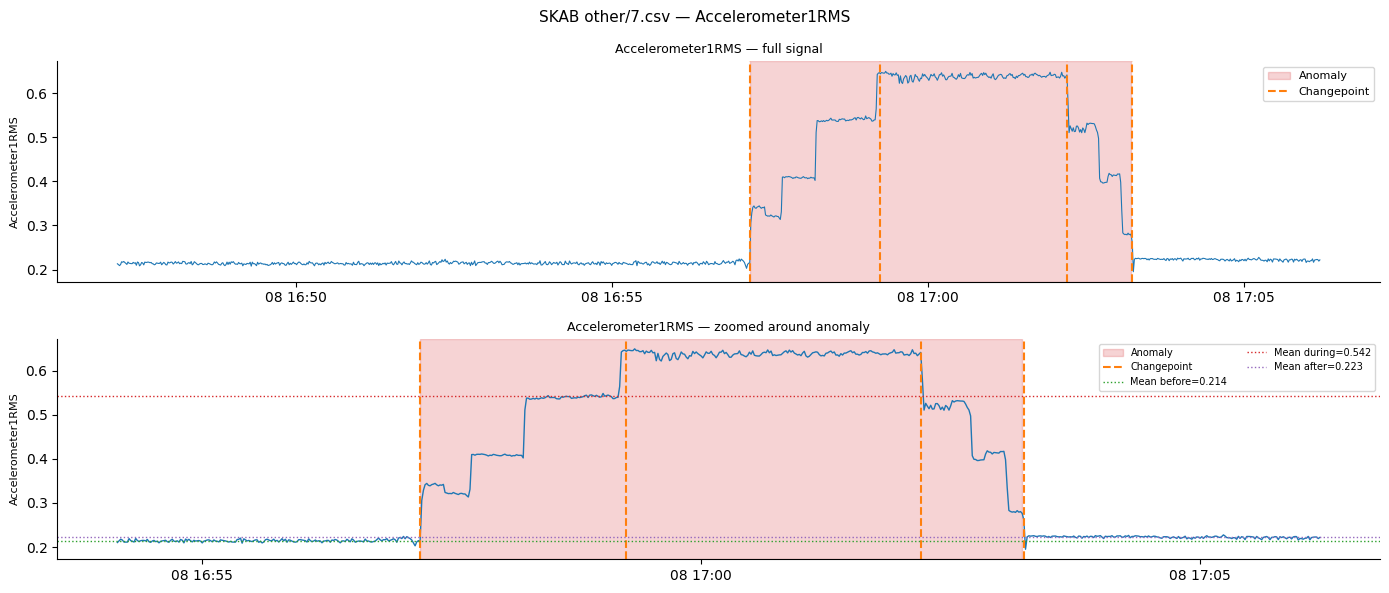

Saved: skab_other7_Accelerometer1RMS.png


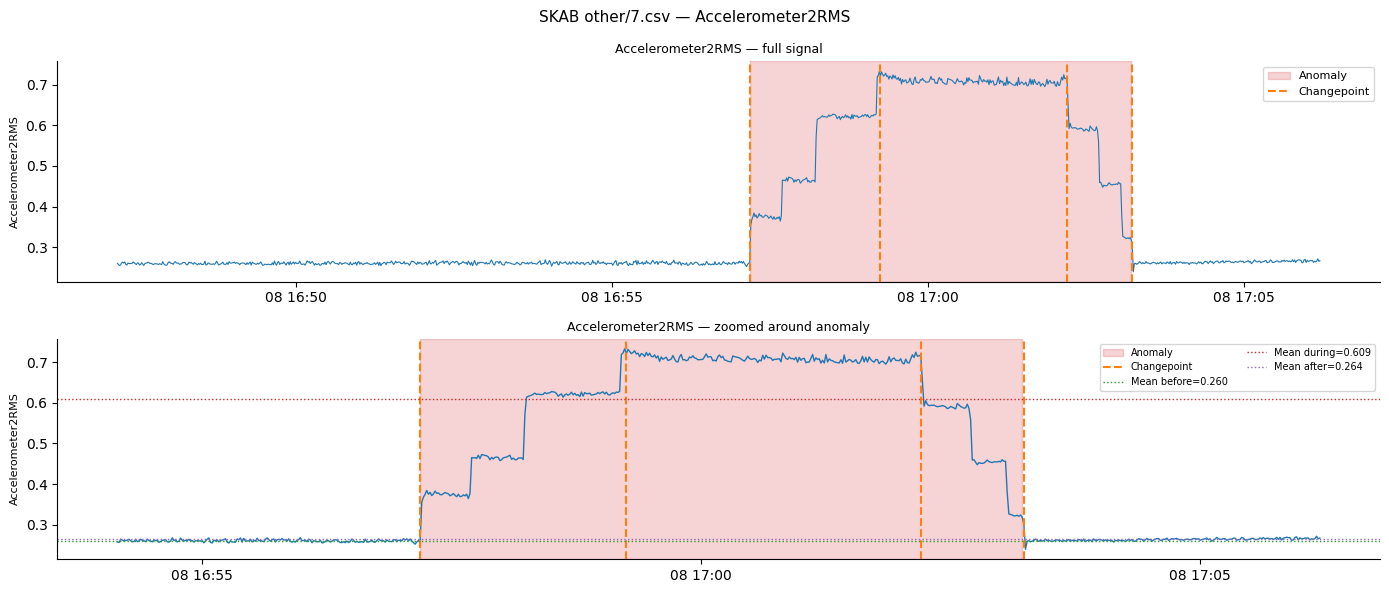

Saved: skab_other7_Accelerometer2RMS.png


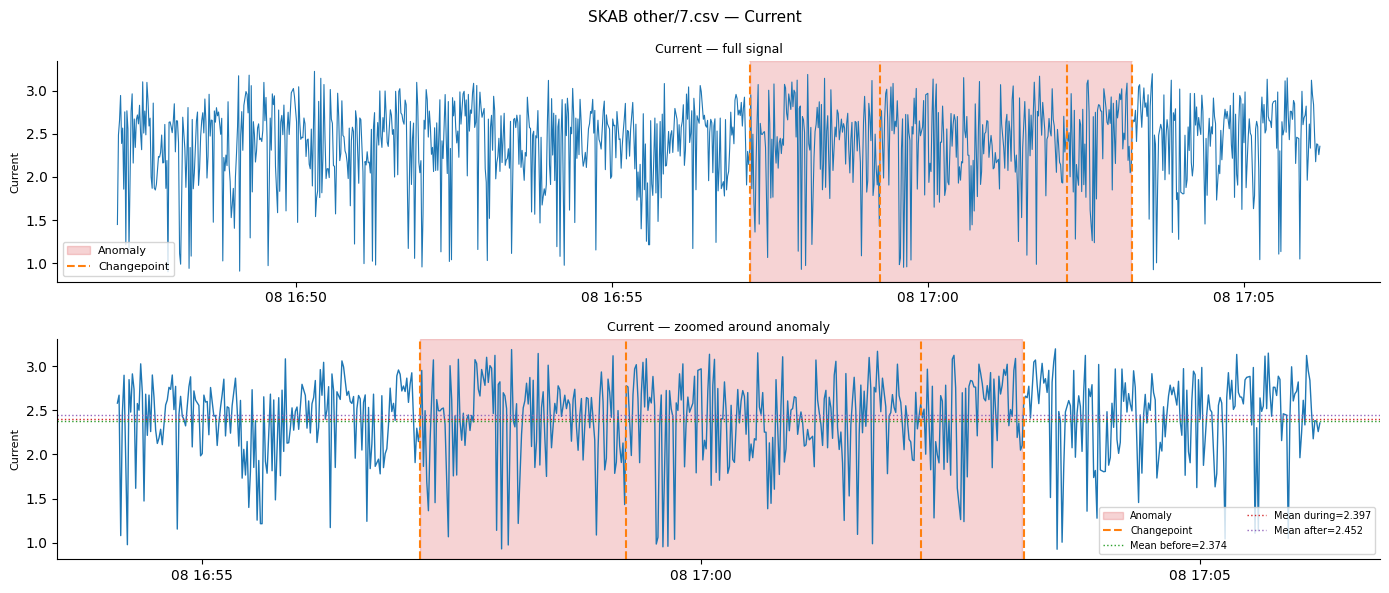

Saved: skab_other7_Current.png


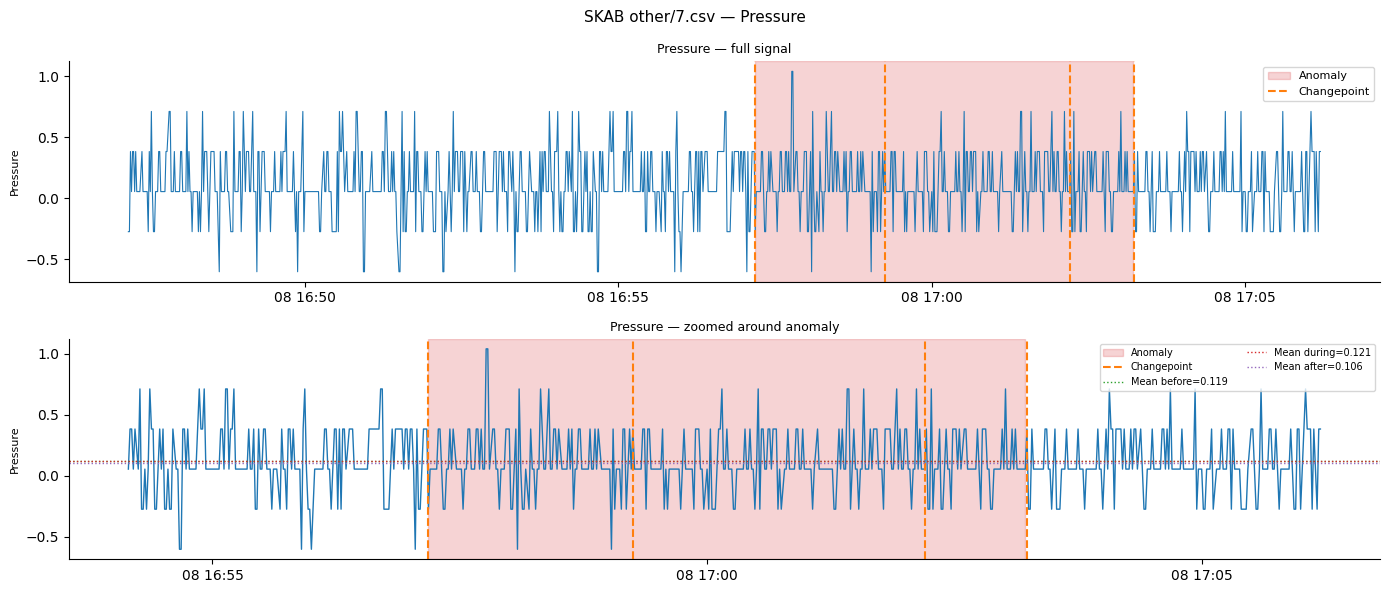

Saved: skab_other7_Pressure.png


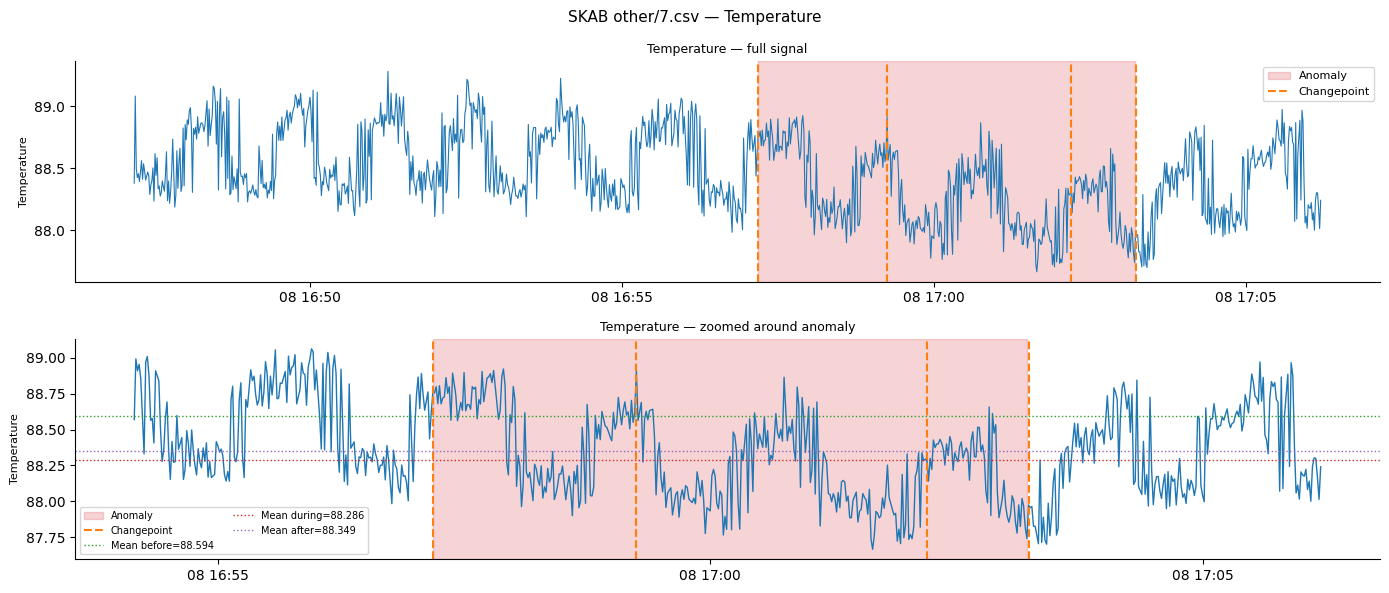

Saved: skab_other7_Temperature.png


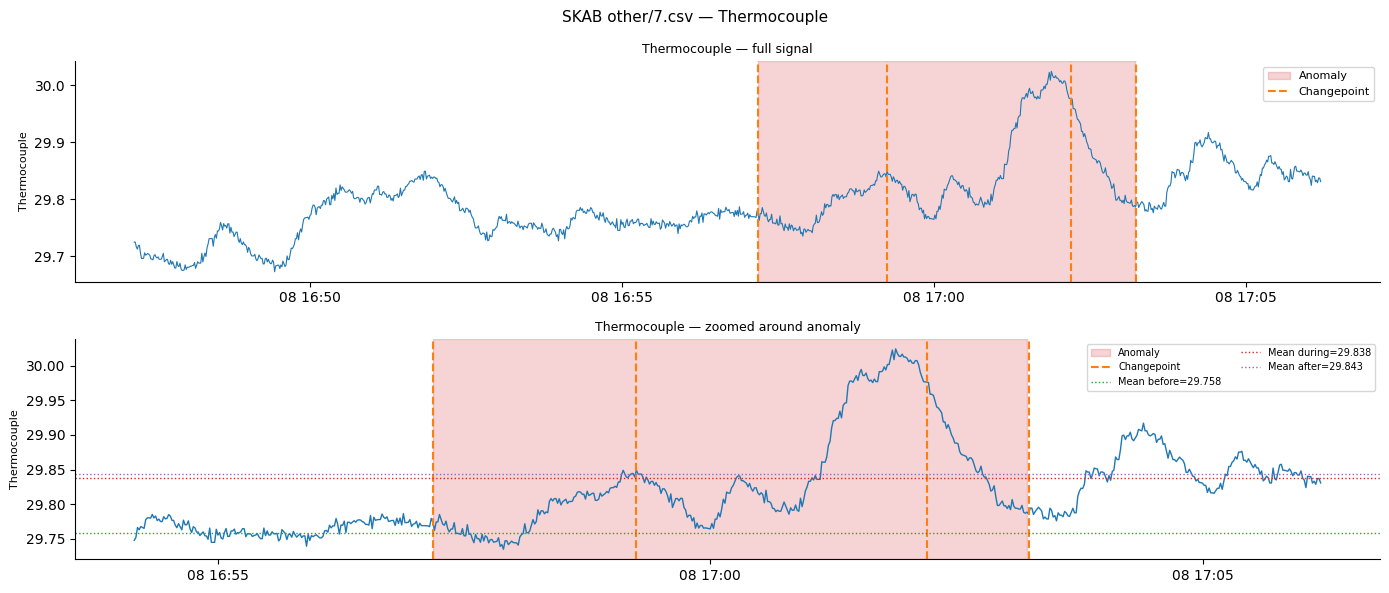

Saved: skab_other7_Thermocouple.png


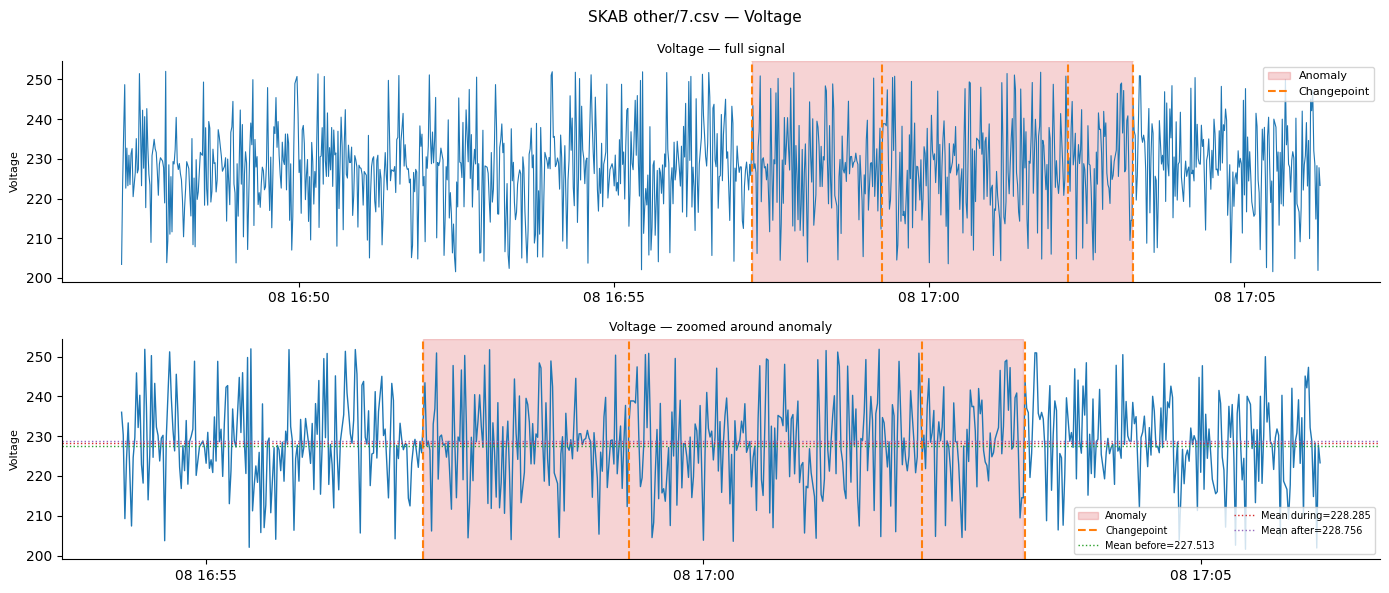

Saved: skab_other7_Voltage.png


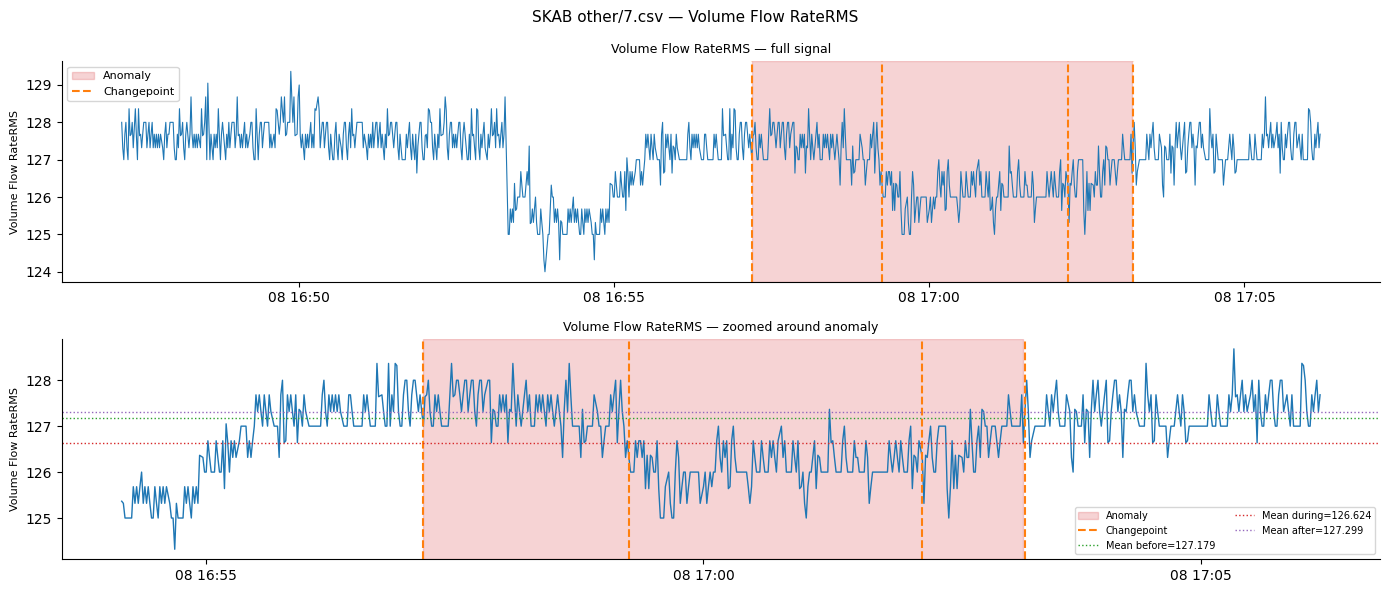

Saved: skab_other7_Volume Flow RateRMS.png


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/waico/SKAB/master/data/other/7.csv"
df  = pd.read_csv(url, sep=";", index_col="datetime", parse_dates=True)
sensor_cols = [c for c in df.columns if c not in ["anomaly", "changepoint"]]
anom_idx    = df[df["anomaly"] == 1].index
cp_idx      = df[df["changepoint"] == 1].index

for col in sensor_cols:
    fig, axes = plt.subplots(2, 1, figsize=(14, 6))

    # ---- Top: full signal ----
    ax = axes[0]
    ax.plot(df.index, df[col], lw=0.8, color="C0")
    if len(anom_idx) > 0:
        ax.axvspan(anom_idx[0], anom_idx[-1], color="C3", alpha=0.2, label="Anomaly")
    for cp in cp_idx:
        ax.axvline(cp, color="C1", lw=1.5, linestyle="--", label="Changepoint")
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(dict(zip(labels, handles)).values(),
              dict(zip(labels, handles)).keys(), fontsize=8)
    ax.set_title(f"{col} — full signal", fontsize=9)
    ax.set_ylabel(col, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    # ---- Bottom: zoomed into anomaly region ----
    ax = axes[1]
    if len(anom_idx) > 0:
        # Add 20% padding around anomaly
        pad   = max(int(len(anom_idx) * 0.5), 10)
        start = max(0, df.index.get_loc(anom_idx[0]) - pad)
        end   = min(len(df), df.index.get_loc(anom_idx[-1]) + pad)
        zoom  = df.iloc[start:end]

        ax.plot(zoom.index, zoom[col], lw=1.0, color="C0")
        ax.axvspan(anom_idx[0], anom_idx[-1], color="C3", alpha=0.2, label="Anomaly")
        for cp in cp_idx:
            if zoom.index[0] <= cp <= zoom.index[-1]:
                ax.axvline(cp, color="C1", lw=1.5, linestyle="--", label="Changepoint")

        # Annotate means
        before = df[col][:anom_idx[0]]
        during = df[col][anom_idx[0]:anom_idx[-1]]
        after  = df[col][anom_idx[-1]:]
        ax.axhline(before.mean(), color="C2", lw=1.0, linestyle=":", label=f"Mean before={before.mean():.3f}")
        ax.axhline(during.mean(), color="C3", lw=1.0, linestyle=":", label=f"Mean during={during.mean():.3f}")
        ax.axhline(after.mean(),  color="C4", lw=1.0, linestyle=":", label=f"Mean after={after.mean():.3f}")

        handles, labels = ax.get_legend_handles_labels()
        ax.legend(dict(zip(labels, handles)).values(),
                  dict(zip(labels, handles)).keys(), fontsize=7, ncol=2)
        ax.set_title(f"{col} — zoomed around anomaly", fontsize=9)
        ax.set_ylabel(col, fontsize=8)
        ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle(f"SKAB other/7.csv — {col}", fontsize=11)
    fig.tight_layout()
    plt.savefig(f"skab_other7_{col}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: skab_other7_{col}.png")


In [6]:
def get_anomaly_intervals(df):
    """
    Returns list of (start_datetime, end_datetime) for each
    contiguous block where anomaly == 1.
    """
    anomaly = df["anomaly"].values
    intervals = []
    in_anomaly = False
    start = None

    for i in range(len(anomaly)):
        if anomaly[i] == 1 and not in_anomaly:
            in_anomaly = True
            start = df.index[i]
        elif anomaly[i] == 0 and in_anomaly:
            in_anomaly = False
            intervals.append((start, df.index[i - 1]))

    # Close final interval if signal ends in anomaly
    if in_anomaly:
        intervals.append((start, df.index[-1]))

    return intervals

In [7]:
intervals = get_anomaly_intervals(df)

print(f"Number of anomaly intervals: {len(intervals)}")
print(f"Total anomalous samples:     {df['anomaly'].sum()}")
print(f"Total samples:               {len(df)}")
print(f"Anomaly fraction:            {df['anomaly'].mean():.3f}")
print()
for i, (s, e) in enumerate(intervals):
    n_samples = (df.index >= s) & (df.index <= e)
    print(f"Interval [{i}]: {s} → {e}  ({n_samples.sum()} samples)")
    print("  Sensor means during anomaly vs baseline:")
    for col in sensor_cols:
        before = df[col][df.index < s].mean()
        during = df[col][(df.index >= s) & (df.index <= e)].mean()
        diff   = during - before
        print(f"    {col:<25}  before={before:.4f}  during={during:.4f}  diff={diff:+.4f}")

Number of anomaly intervals: 1
Total anomalous samples:     347.0
Total samples:               1090
Anomaly fraction:            0.318

Interval [0]: 2020-02-08 16:57:11 → 2020-02-08 17:03:13  (347 samples)
  Sensor means during anomaly vs baseline:
    Accelerometer1RMS          before=0.2142  during=0.5423  diff=+0.3281
    Accelerometer2RMS          before=0.2604  during=0.6086  diff=+0.3482
    Current                    before=2.3736  during=2.3970  diff=+0.0234
    Pressure                   before=0.1195  during=0.1209  diff=+0.0014
    Temperature                before=88.5934  during=88.2860  diff=-0.3073
    Thermocouple               before=29.7582  during=29.8378  diff=+0.0796
    Voltage                    before=227.5011  during=228.2847  diff=+0.7836
    Volume Flow RateRMS        before=127.1798  during=126.6241  diff=-0.5557


In [17]:
candidates = [
    ("https://raw.githubusercontent.com/waico/SKAB/master/data/other/5.csv",  "Accelerometer2RMS", ";"),
    ("https://raw.githubusercontent.com/waico/SKAB/master/data/other/7.csv",  "Accelerometer2RMS", ";"),
    ("https://raw.githubusercontent.com/waico/SKAB/master/data/other/8.csv",  "Accelerometer2RMS", ";"),
    ("https://raw.githubusercontent.com/waico/SKAB/master/data/other/9.csv",  "Accelerometer2RMS", ";"),

    ("https://raw.githubusercontent.com/waico/SKAB/master/data/valve1/0.csv", "Volume Flow RateRMS", ";"),
    ("https://raw.githubusercontent.com/waico/SKAB/master/data/valve1/1.csv", "Volume Flow RateRMS", ";"),
    ("https://raw.githubusercontent.com/waico/SKAB/master/data/valve2/0.csv", "Volume Flow RateRMS", ";"),
    ("https://raw.githubusercontent.com/waico/SKAB/master/data/valve2/1.csv", "Volume Flow RateRMS", ";"),
]

# Quick scan to find which have the cleanest step pattern
for url, col, sep in candidates:
    try:
        df  = pd.read_csv(url, sep=sep, index_col="datetime", parse_dates=True)
        intervals = get_anomaly_intervals(df)
        if len(intervals) == 0:
            print(f"SKIP  {url.split('/')[-2]}/{url.split('/')[-1]}  — no anomaly")
            continue
        s, e = intervals[0]
        before = df[col][df.index < s].mean()
        during = df[col][(df.index >= s) & (df.index <= e)].mean()
        after  = df[col][df.index > e].mean()
        diff   = during - before
        ratio  = abs(diff) / max(abs(before), 1e-9)
        n_anom = (df["anomaly"] == 1).sum()
        print(f"{'✓' if ratio > 0.3 else '~' if ratio > 0.1 else '✗'}  "
              f"{url.split('/')[-2]}/{url.split('/')[-1]:<12} "
              f"col={col:<22} "
              f"before={before:.3f}  during={during:.3f}  "
              f"diff={diff:+.3f}  ratio={ratio:.2f}  "
              f"n_anom={n_anom}")
    except Exception as ex:
        print(f"FAIL  {url}  {ex}")

✓  other/5.csv        col=Accelerometer2RMS      before=0.270  during=0.735  diff=+0.464  ratio=1.72  n_anom=410
✓  other/7.csv        col=Accelerometer2RMS      before=0.260  during=0.609  diff=+0.348  ratio=1.34  n_anom=347
✗  other/8.csv        col=Accelerometer2RMS      before=0.264  during=0.266  diff=+0.002  ratio=0.01  n_anom=403
✓  other/9.csv        col=Accelerometer2RMS      before=0.273  during=0.653  diff=+0.380  ratio=1.39  n_anom=401
✗  valve1/0.csv        col=Volume Flow RateRMS    before=32.112  during=31.796  diff=-0.316  ratio=0.01  n_anom=401
✗  valve1/1.csv        col=Volume Flow RateRMS    before=32.026  during=30.856  diff=-1.171  ratio=0.04  n_anom=402
✗  valve2/0.csv        col=Volume Flow RateRMS    before=32.280  during=31.564  diff=-0.716  ratio=0.02  n_anom=394
✗  valve2/1.csv        col=Volume Flow RateRMS    before=32.211  during=29.931  diff=-2.280  ratio=0.07  n_anom=333


                     Accelerometer1RMS  Accelerometer2RMS  Current  Pressure  \
datetime                                                                       
2020-02-08 16:47:11           0.213089           0.260424  1.44922 -0.273216   
2020-02-08 16:47:12           0.211211           0.257295  2.48733 -0.273216   
2020-02-08 16:47:13           0.208962           0.254713  2.64975  0.382638   
2020-02-08 16:47:14           0.211292           0.256228  2.94410  0.054711   
2020-02-08 16:47:15           0.217600           0.261785  2.38798  0.382638   

                     Temperature  Thermocouple  Voltage  Volume Flow RateRMS  \
datetime                                                                       
2020-02-08 16:47:11      88.3793       29.7245  203.410              128.000   
2020-02-08 16:47:12      89.0805       29.7245  223.716              127.320   
2020-02-08 16:47:13      88.4958       29.7161  236.980              127.000   
2020-02-08 16:47:14      88.4240       

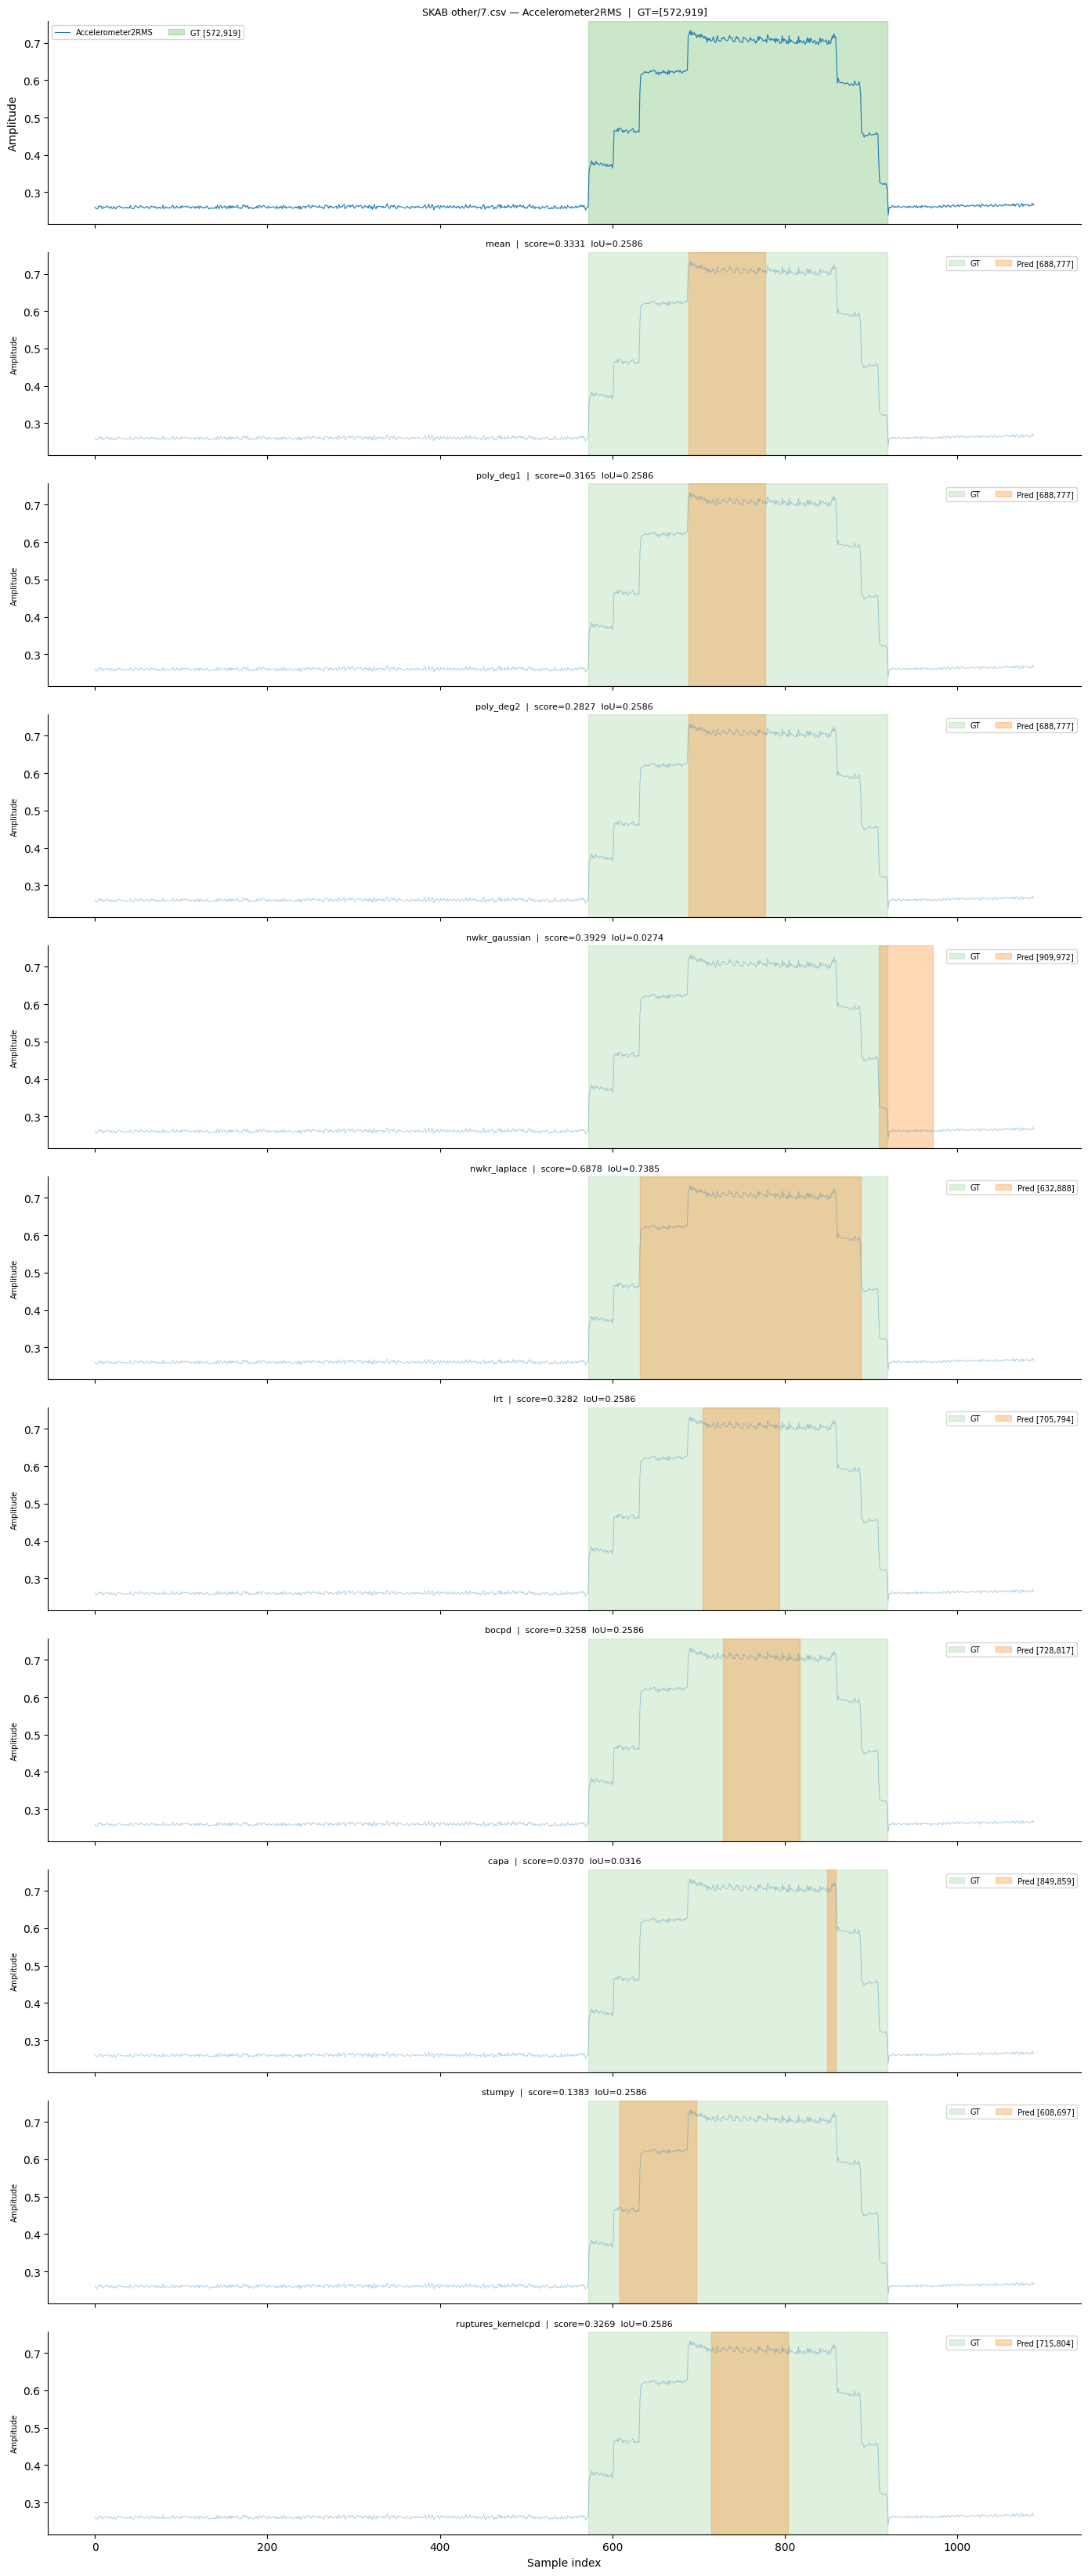

Saved: skab_other7_results.png
W=181, R=543
mean                  score=0.7078  pred=[680,860]  IoU=0.5201
poly_deg1             score=0.6763  pred=[680,860]  IoU=0.5201
poly_deg2             score=0.6776  pred=[909,1089]  IoU=0.0212
nwkr_gaussian         score=0.7727  pred=[632,888]  IoU=0.7385
nwkr_laplace          score=0.8488  pred=[632,888]  IoU=0.7385
lrt                   score=0.6823  pred=[688,859]  IoU=0.4943
bocpd                 score=0.6823  pred=[688,859]  IoU=0.4943
capa                  score=0.0582  pred=[680,699]  IoU=0.0575
stumpy                score=0.1469  pred=[785,965]  IoU=0.3426
ruptures_kernelcpd    score=0.6886  pred=[670,850]  IoU=0.5201

=== Results sorted by IoU ===
            method  score  pred_start  pred_end    iou
     nwkr_gaussian 0.7727         632       888 0.7385
      nwkr_laplace 0.8488         632       888 0.7385
              mean 0.7078         680       860 0.5201
         poly_deg1 0.6763         680       860 0.5201
ruptures_kernelcpd 

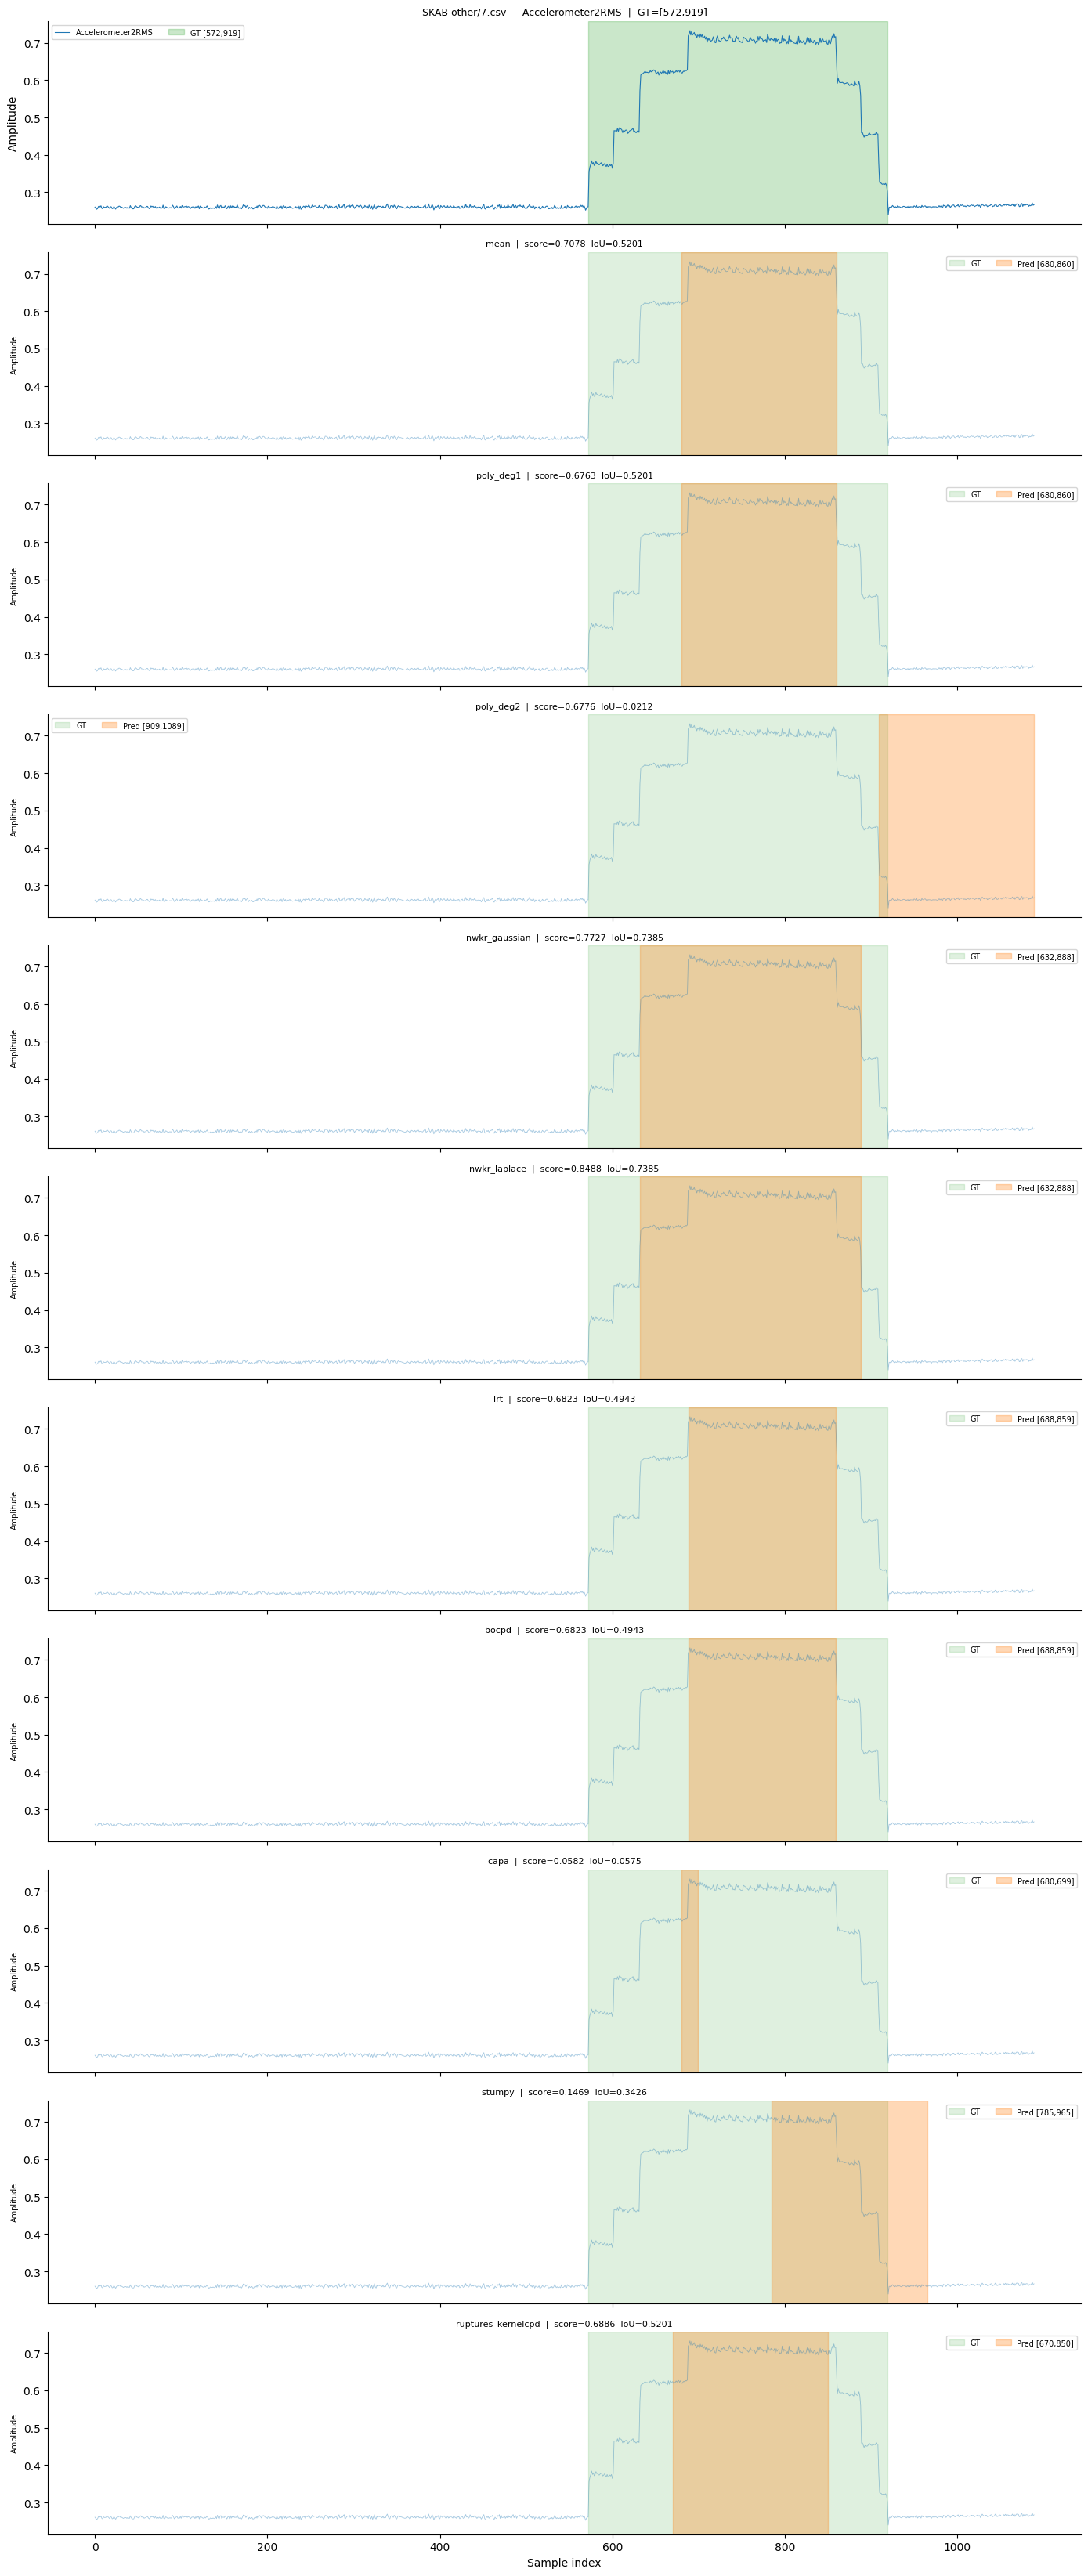

Saved: skab_other7_results.png
W=363, R=1089
mean                  score=0.9187  pred=[632,888]  IoU=0.7385
poly_deg1             score=0.9142  pred=[602,888]  IoU=0.8247
poly_deg2             score=0.9807  pred=[573,909]  IoU=0.9684
nwkr_gaussian         score=0.8883  pred=[632,888]  IoU=0.7385
nwkr_laplace          score=0.8905  pred=[632,888]  IoU=0.7385
lrt                   score=0.8477  pred=[632,860]  IoU=0.6580
bocpd                 score=0.6823  pred=[688,859]  IoU=0.4943
capa                  score=0.0441  pred=[688,699]  IoU=0.0345
stumpy                score=0.5920  pred=[636,998]  IoU=0.6651
ruptures_kernelcpd    score=0.9187  pred=[632,888]  IoU=0.7385

=== Results sorted by IoU ===
            method  score  pred_start  pred_end    iou
         poly_deg2 0.9807         573       909 0.9684
         poly_deg1 0.9142         602       888 0.8247
              mean 0.9187         632       888 0.7385
     nwkr_gaussian 0.8883         632       888 0.7385
      nwkr_laplace 

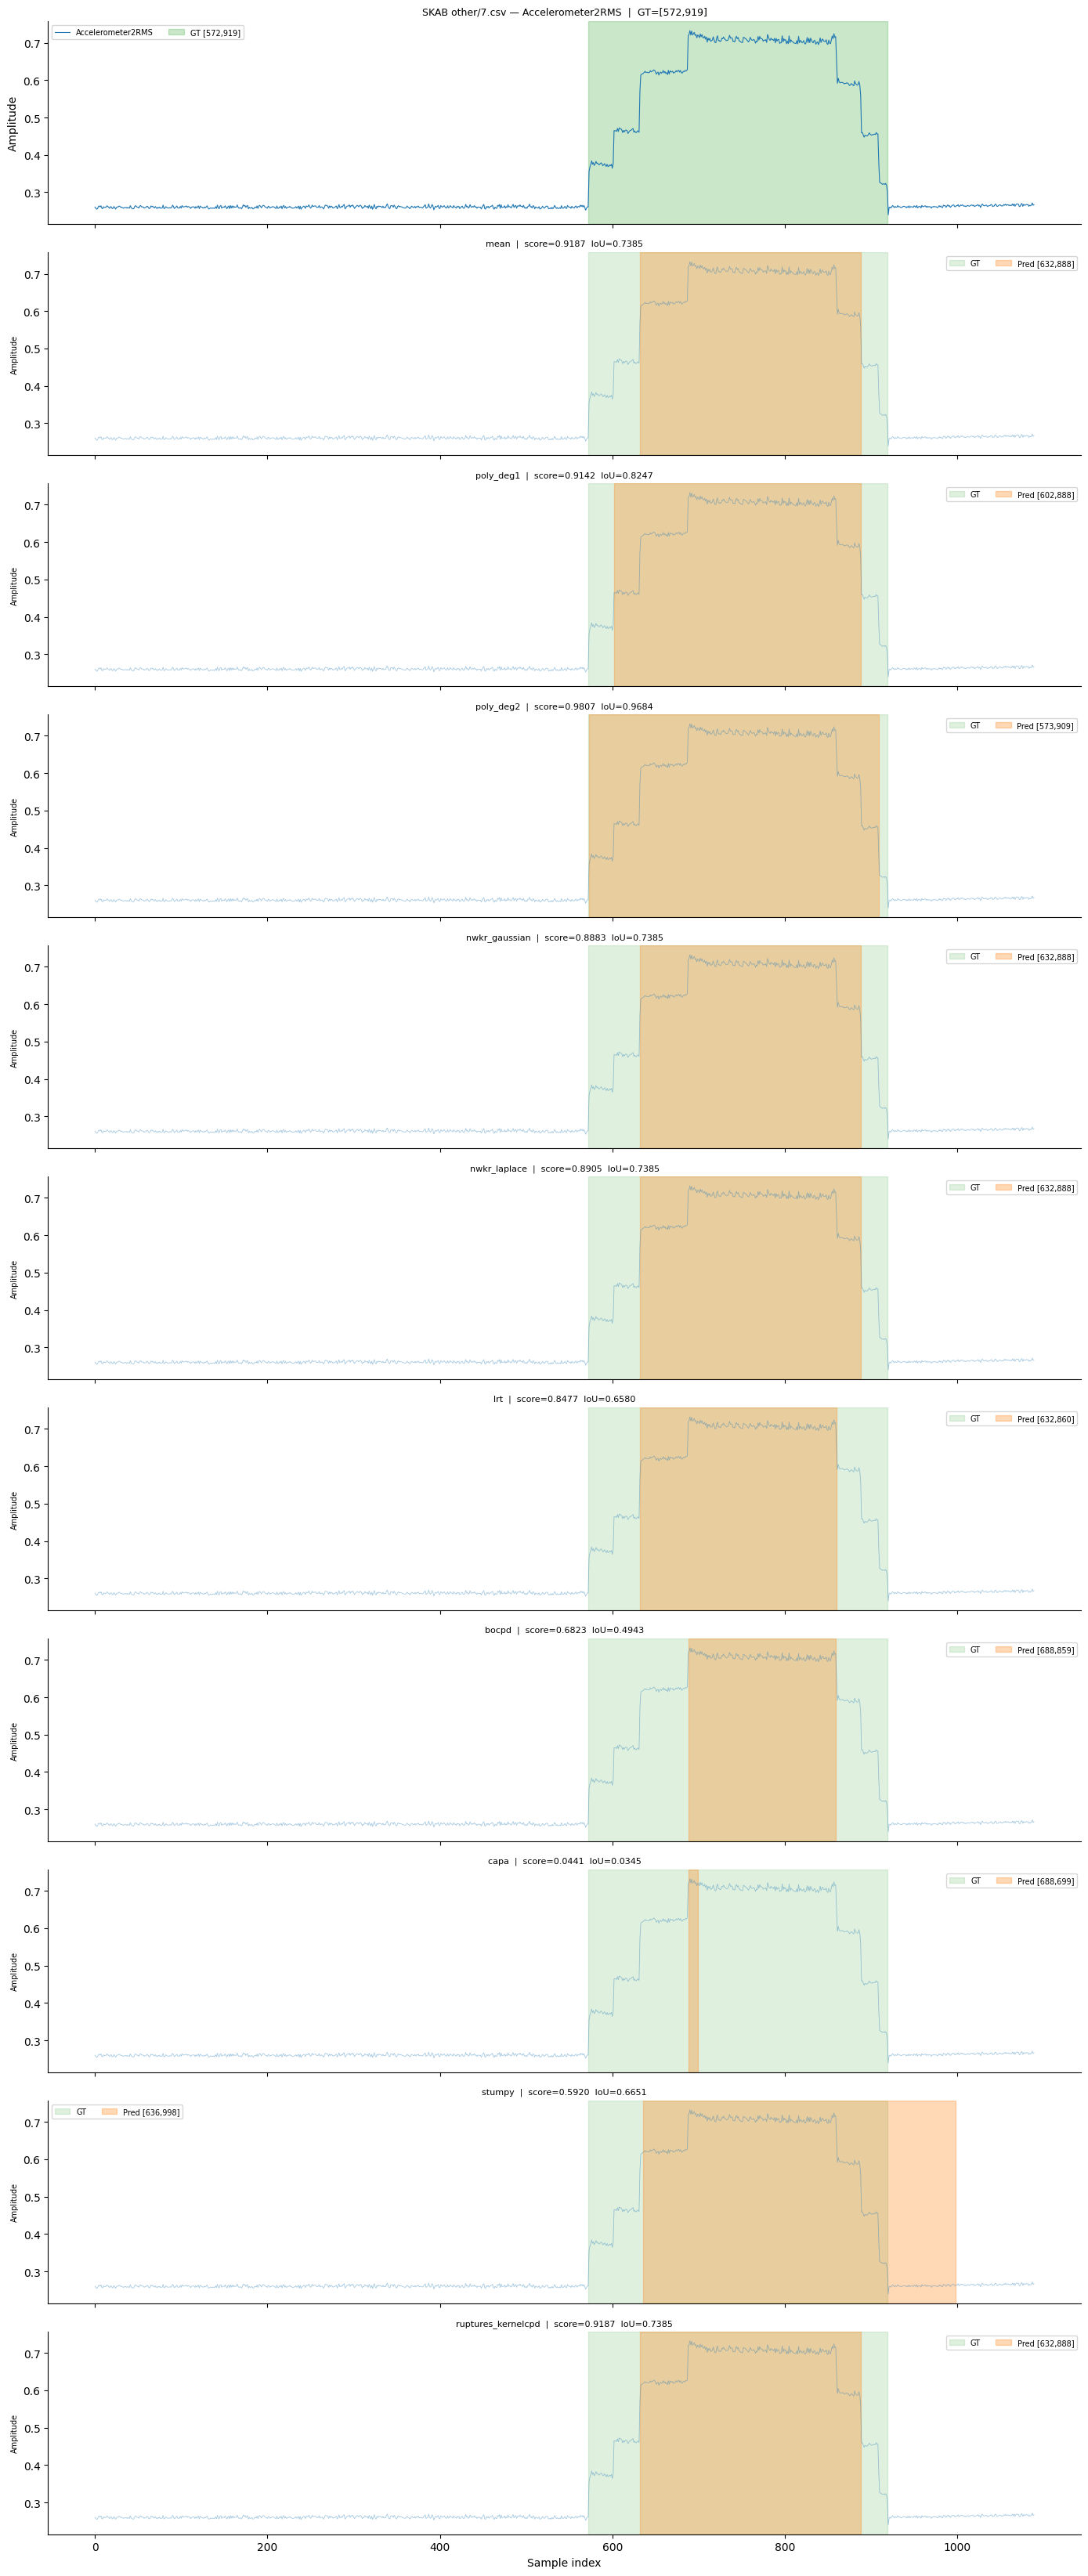

Saved: skab_other7_results.png
W=545, R=1090
mean                  score=0.9187  pred=[632,888]  IoU=0.7385
poly_deg1             score=0.9142  pred=[602,888]  IoU=0.8247
poly_deg2             score=0.9807  pred=[573,909]  IoU=0.9684
nwkr_gaussian         score=0.9045  pred=[632,888]  IoU=0.7385
nwkr_laplace          score=0.9012  pred=[632,888]  IoU=0.7385
lrt                   score=0.8477  pred=[632,860]  IoU=0.6580
bocpd                 score=0.6823  pred=[688,859]  IoU=0.4943
capa                  score=0.0441  pred=[688,699]  IoU=0.0345
stumpy                score=0.6006  pred=[602,1010]  IoU=0.7244
ruptures_kernelcpd    score=0.9187  pred=[632,888]  IoU=0.7385

=== Results sorted by IoU ===
            method  score  pred_start  pred_end    iou
         poly_deg2 0.9807         573       909 0.9684
         poly_deg1 0.9142         602       888 0.8247
              mean 0.9187         632       888 0.7385
     nwkr_gaussian 0.9045         632       888 0.7385
      nwkr_laplace

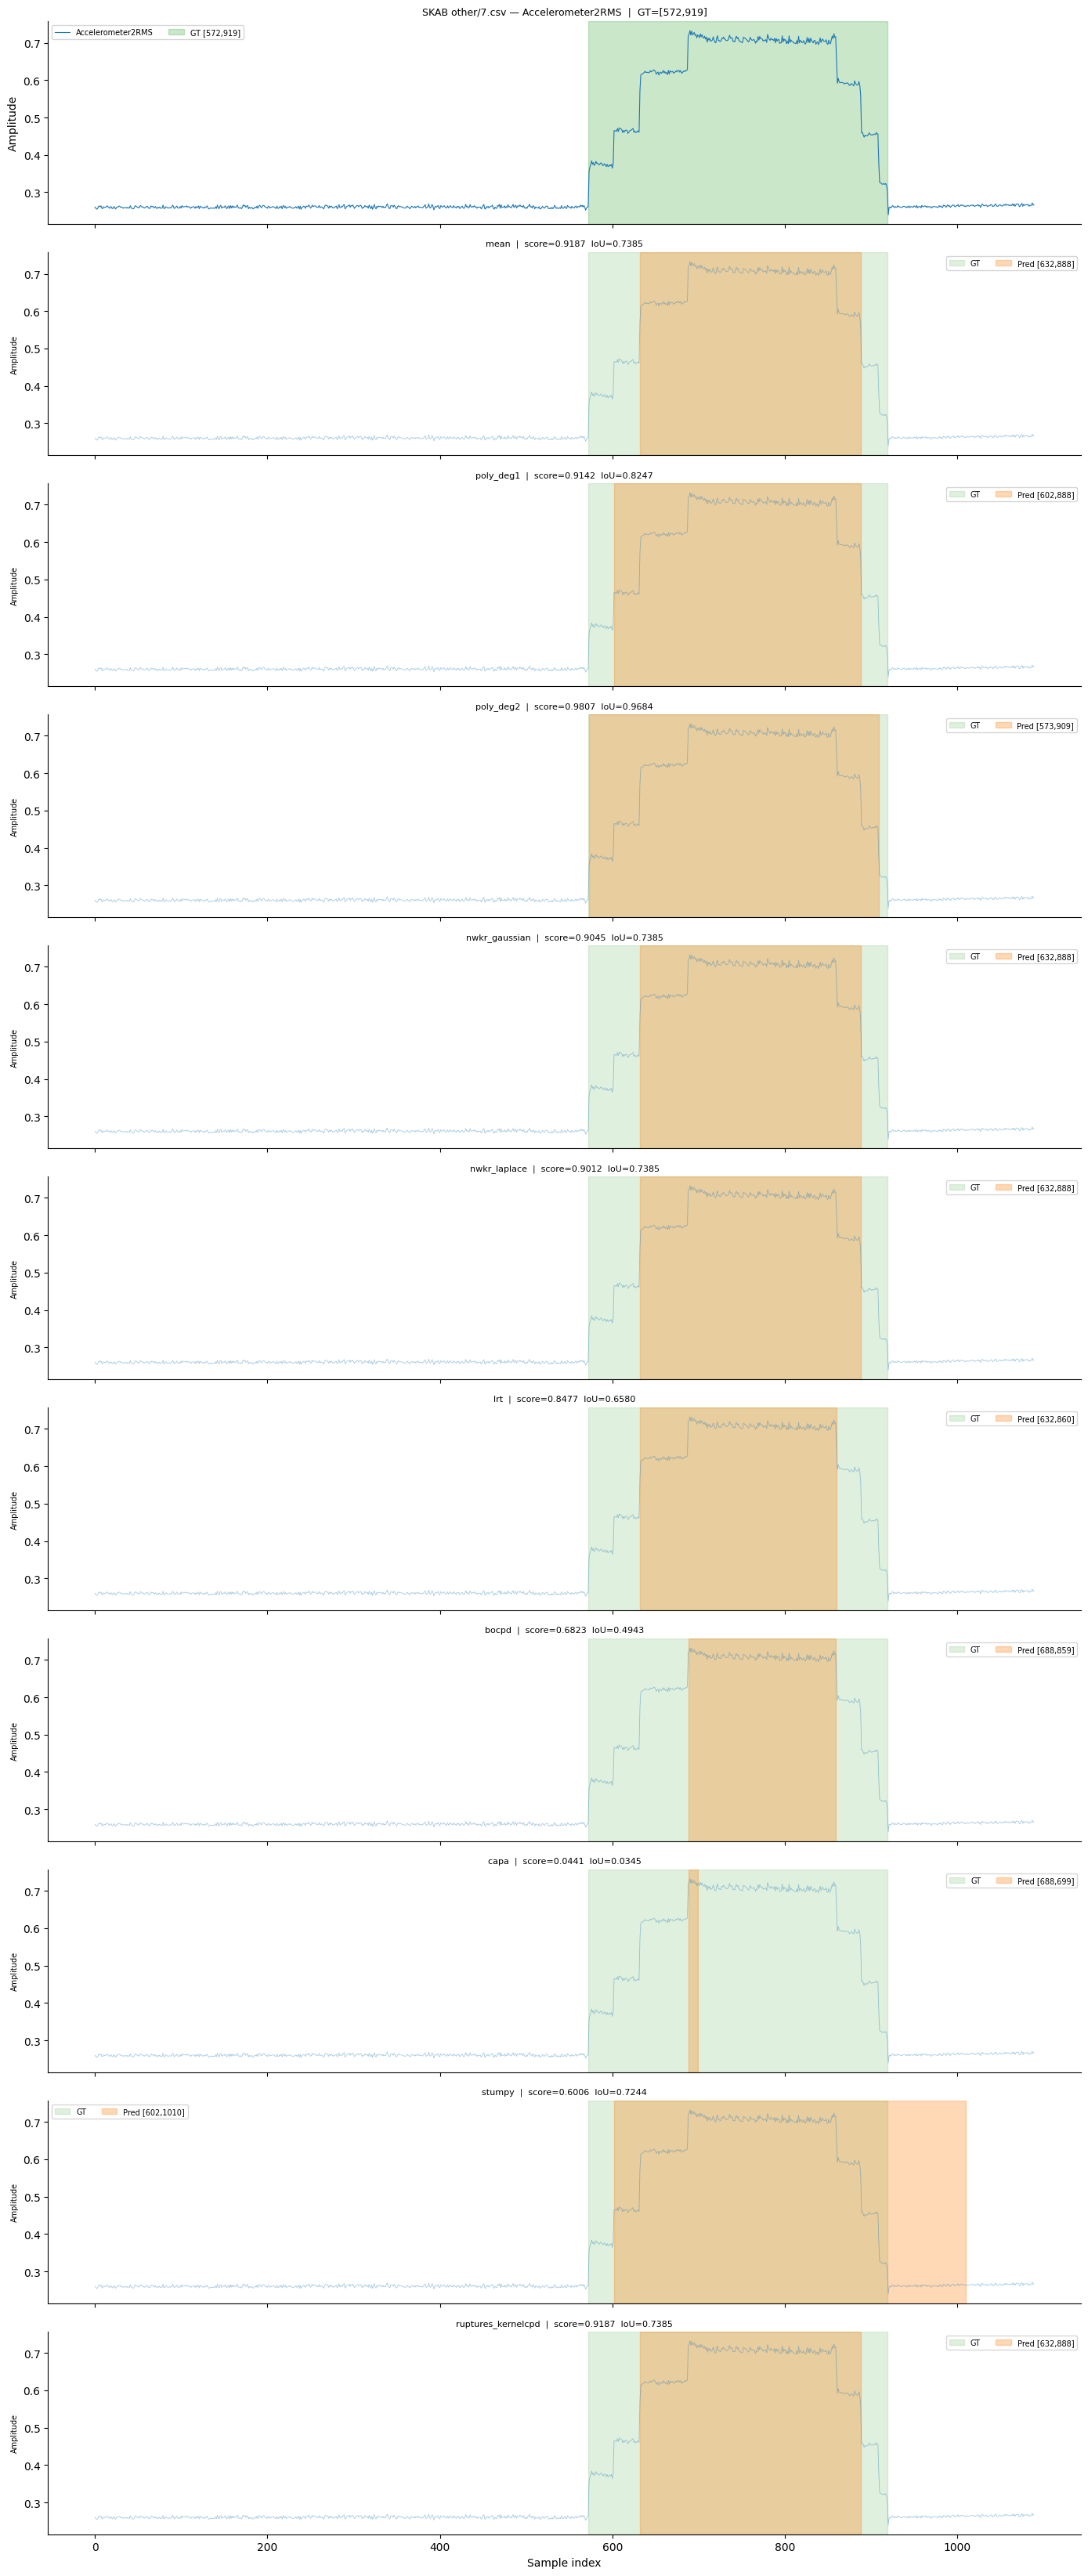

Saved: skab_other7_results.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from benchmark_regressor_on_syth import _run_one, ALL_METHODS, _resolve_methods, iou as compute_iou
from helpers.config import ref_freq

# ---- Load SKAB file ----
url_source = "7"
url = f"https://raw.githubusercontent.com/waico/SKAB/master/data/other/{url_source}.csv"
df  = pd.read_csv(url, sep=";", index_col="datetime", parse_dates=True)
print(df.head())
print(df.columns.tolist())

# ---- Extract univariate signal ----
col = "Accelerometer2RMS"
x   = df[col].values.astype(np.float64)
n   = len(x)

# ---- Extract ground truth interval from changepoint labels ----
cp = df["changepoint"].values
anomaly = df["anomaly"].values

# Find start and end of anomalous interval
cp_indices = np.where(cp == 1)[0]
if len(cp_indices) >= 2:
    gt_start = int(cp_indices[0])
    gt_end   = int(cp_indices[-1])
elif len(cp_indices) == 1:
    gt_start = int(cp_indices[0])
    gt_end   = int(np.where(anomaly == 1)[0][-1])
else:
    # Fall back to anomaly column
    anom_idx = np.where(anomaly == 1)[0]
    gt_start, gt_end = int(anom_idx[0]), int(anom_idx[-1])

print(f"Signal length: {n}")
print(f"GT interval:   [{gt_start}, {gt_end}]  ({gt_end - gt_start + 1} samples)")
print(f"Mean before:   {x[:gt_start].mean():.4f}")
print(f"Mean during:   {x[gt_start:gt_end+1].mean():.4f}")
print(f"Mean after:    {x[gt_end+1:].mean():.4f}")

    # ---- Derive W from signal (use fixed freq spacing as proxy) ----
    # SKAB is 1Hz sampling — treat each sample as a "channel"
    # Set W to roughly the anomaly width / 2 as the scan cap

W_list = [n//12, n//6, n//3, n//2]
for W in W_list:
    W = max(10, W)
    R = min(n, 3 * W)

    # Dummy frequency array (1 Hz sampling → treat as GHz proxy)
    freqs = np.arange(n, dtype=np.float64) * (ref_freq / W)

    print(f"W={W}, R={R}")

    # ---- Run all methods ----
    families = _resolve_methods(
        "mean,poly_deg1,poly_deg2,nwkr_gaussian,nwkr_laplace,lrt,bocpd,capa,stumpy,ruptures_kernelcpd", []
    )

    results = []
    for name, cfg in families.items():
        try:
            score, (a, b) = _run_one(x, freqs, W, R, cfg)
        except Exception as e:
            import traceback
            print(f"{name} failed: {e}")
            traceback.print_exc()
            score, a, b = 0.0, 0, -1

        iou_val = compute_iou(a, b, gt_start, gt_end) if b > a else 0.0
        results.append({
            "method": name, "score": round(score, 4),
            "pred_start": a, "pred_end": b,
            "iou": round(iou_val, 4),
        })
        print(f"{name:<20}  score={score:.4f}  pred=[{a},{b}]  IoU={iou_val:.4f}")

    results_df = pd.DataFrame(results).sort_values("iou", ascending=False)
    print("\n=== Results sorted by IoU ===")
    print(results_df.to_string(index=False))

    # ---- Plot ----
    fig, axes = plt.subplots(len(families) + 1, 1,
                            figsize=(14, 3 * (len(families) + 1)),
                            sharex=True)

    # Top panel: raw signal with GT
    ax = axes[0]
    ax.plot(x, lw=0.8, color="C0", label=col)
    ax.axvspan(gt_start, gt_end, color="C2", alpha=0.25, label=f"GT [{gt_start},{gt_end}]")
    ax.set_title(f"SKAB other/7.csv — {col}  |  GT=[{gt_start},{gt_end}]", fontsize=9)
    ax.set_ylabel("Amplitude")
    ax.legend(fontsize=7, ncol=2)
    ax.spines[["top","right"]].set_visible(False)

    # One panel per method
    for i, row in enumerate(results):
        ax = axes[i + 1]
        ax.plot(x, lw=0.6, color="C0", alpha=0.4)
        ax.axvspan(gt_start, gt_end, color="C2", alpha=0.15, label="GT")
        a, b = row["pred_start"], row["pred_end"]
        if b > a:
            ax.axvspan(a, b, color="C1", alpha=0.3, label=f"Pred [{a},{b}]")
        ax.set_title(
            f"{row['method']}  |  score={row['score']:.4f}  IoU={row['iou']:.4f}",
            fontsize=8)
        ax.set_ylabel("Amplitude", fontsize=7)
        ax.legend(fontsize=7, ncol=3)
        ax.spines[["top","right"]].set_visible(False)

    axes[-1].set_xlabel("Sample index")
    fig.tight_layout()
    plt.savefig(f"data/skab/skab_other7_results_{col}_w={W}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: skab_other7_results.png")

# Weather station data

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 150

df = pd.read_parquet('data/wbb.parquet')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (6599273, 132)
Columns: ['STID', 'Date', 'year', 'NO2_concentration_set_1', 'NO_concentration_set_1', 'NOx_concentration_set_1', 'PM_25_concentration_set_1', 'PM_25_concentration_set_2', 'T_water_temp_set_1', 'air_flow_temperature_set_1', 'air_flow_temperature_set_2', 'air_temp_set_1', 'air_temp_set_2', 'air_temp_set_3', 'air_temp_set_4', 'air_temp_set_5', 'air_temp_set_6', 'air_temp_set_7', 'air_temp_set_8', 'air_temp_set_9', 'air_temp_set_10', 'air_temp_set_11', 'air_temp_set_12', 'air_temp_set_13', 'air_temp_set_14', 'air_temp_set_15', 'air_temp_set_16', 'air_temp_10m_set_1', 'altimeter_set_1', 'black_carbon_concentration_set_1', 'black_carbon_concentration_set_2', 'black_carbon_concentration_set_3', 'black_carbon_concentration_set_4', 'black_carbon_concentration_set_5', 'ceiling_set_1', 'clear_sky_solar_radiation_set_1', 'cloud_layer_1_code_set_1', 'cloud_layer_2_code_set_1', 'cloud_layer_3_code_set_1', 'derived_aerosol_boundary_layer_depth_set_1', 'electric_conductivity_set

,STID,Date,year,NO2_concentration_set_1,NO_concentration_set_1,NOx_concentration_set_1,PM_25_concentration_set_1,PM_25_concentration_set_2,T_water_temp_set_1,air_flow_temperature_set_1,...,wind_direction_set_1,wind_direction_set_2,wind_gust_set_1,wind_gust_set_2,wind_speed_set_1,wind_speed_set_2,wind_speed_set_3,wind_speed_set_4,wind_speed_set_5,wind_speed_set_6
0,WBB,1997-01-01 07:00:00,1997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,120.0,NaN,7.72,NaN,5.14,NaN,NaN,NaN,NaN,NaN
1,WBB,1997-01-01 07:05:00,1997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,130.0,NaN,7.20,NaN,5.66,NaN,NaN,NaN,NaN,NaN
2,WBB,1997-01-01 07:10:00,1997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,150.0,NaN,6.17,NaN,4.63,NaN,NaN,NaN,NaN,NaN
3,WBB,1997-01-01 07:15:00,1997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,140.0,NaN,4.12,NaN,2.57,NaN,NaN,NaN,NaN,NaN
4,WBB,1997-01-01 07:20:00,1997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,120.0,NaN,3.60,NaN,2.57,NaN,NaN,NaN,NaN,NaN


In [5]:
TIME_COL = 'Date'
SOLAR_COL = 'solar_radiation_set_1'

In [6]:
df[TIME_COL] = pd.to_datetime(df[TIME_COL])
df = df.sort_values(TIME_COL).set_index(TIME_COL)
solar = df[[SOLAR_COL]].dropna().rename(columns={SOLAR_COL: 'solar'})
print(f'{len(solar)} readings from {solar.index.min()} to {solar.index.max()}')

5796129 readings from 1997-01-01 07:00:00 to 2026-03-14 22:00:00


In [7]:
def segment_days(series, min_hours=4, min_peak=50):
    s = series['solar'].values
    t = series.index
    dates = t.date

    days = []
    for date in np.unique(dates):
        mask = dates == date
        day_s = s[mask].astype(float)
        day_t = t[mask]

        nonzero = np.where(day_s > 0)[0]
        if len(nonzero) < 10:
            continue

        lo = max(0, nonzero[0] - 5)
        hi = min(len(day_s) - 1, nonzero[-1] + 5)
        sl_s = day_s[lo:hi+1]
        sl_t = day_t[lo:hi+1]

        dur = (sl_t[-1] - sl_t[0]).total_seconds() / 3600
        if dur < min_hours or len(sl_s) < 20 or np.max(sl_s) < min_peak:
            continue

        days.append({'date': date, 'time': sl_t, 'solar': sl_s,
                     'peak': np.max(sl_s), 'duration_h': dur})
    return days

days = segment_days(solar)
print(f'Found {len(days)} daytime segments')

Found 7115 daytime segments


In [8]:
def score_dip(day, smooth_win=15):
    s = day['solar']
    n = len(s)
    if n < 2 * smooth_win + 1:
        return 0, {}
 
    # Rolling median as the smooth envelope
    pad = np.pad(s, smooth_win, mode='edge')
    smooth = pd.Series(pad).rolling(2*smooth_win+1, center=True).median().values
    smooth = smooth[smooth_win:-smooth_win]
 
    residual = s - smooth
 
    # ---- Smoothness filter: reject jittery/noisy days ----
    # Count zero-crossings in the derivative (sign changes = wiggles)
    deriv = np.diff(s)
    sign_changes = np.sum(np.abs(np.diff(np.sign(deriv))) > 0)
    wiggle_rate = sign_changes / max(n, 1)  # wiggles per sample
 
    # Also measure roughness: std of second derivative
    if n > 3:
        second_deriv = np.diff(s, n=2)
        roughness = np.std(second_deriv) / max(day['peak'], 1)
    else:
        roughness = 0
 
    # Skip days that are too jittery
    if wiggle_rate > 0.55:  # more than 55% of samples change direction
        return 0, {}
    if roughness > 0.08:    # too much high-frequency noise relative to peak
        return 0, {}
    # -------------------------------------------------------
 
    thresh = -0.15 * day['peak']
    in_dip = residual < thresh
 
    if not np.any(in_dip):
        return 0, {}
 
    # Find contiguous dip regions
    regions = []
    start = None
    for i in range(n):
        if in_dip[i]:
            if start is None: start = i
        else:
            if start is not None:
                regions.append((start, i-1))
                start = None
    if start is not None:
        regions.append((start, n-1))
 
    if not regions:
        return 0, {}
 
    biggest = max(regions, key=lambda r: r[1]-r[0])
    width = biggest[1] - biggest[0] + 1
    depth = np.min(residual)
    dip_idx = np.argmin(residual)
 
    recovery = 0
    if dip_idx < n - 5:
        recovery = np.max(s[dip_idx:min(dip_idx+30, n)]) - s[dip_idx]
 
    nd = abs(depth) / max(day['peak'], 1)
    ns = abs(np.min(np.diff(s))) / max(day['peak'], 1)
    nr = recovery / max(day['peak'], 1)
 
    if day['peak'] < 100 or nd < 0.15:
        return 0, {}
 
    # Bonus for smooth signals, penalty for noisy ones
    smoothness_bonus = max(0, 1.0 - wiggle_rate * 2)  # 0 to 1
    score = (nd*2 + ns + nr) * np.sqrt(width) * (1 + smoothness_bonus)
 
    return score, {'depth': depth, 'dip_idx': dip_idx, 'width': width,
                   'region': biggest, 'smooth': smooth, 'recovery': recovery,
                   'wiggle_rate': wiggle_rate, 'roughness': roughness}

In [9]:
scored = []
for day in days:
    sc, info = score_dip(day)
    if sc > 0:
        scored.append((sc, day, info))

scored.sort(key=lambda x: x[0], reverse=True)
print(f'Found {len(scored)} days with dips')

Found 3043 days with dips


In [10]:
TOP_N = 25

for rank, (score, day, info) in enumerate(scored[:TOP_N], 1):
    print(f"#{rank}  {day['date']}  score={score:.2f}  "
          f"depth={info['depth']:.0f} W/m²  width={info['width']} pts  "
          f"peak={day['peak']:.0f} W/m²")



#1  2024-12-10  score=19.48  depth=-384 W/m²  width=10 pts  peak=454 W/m²
#2  2023-11-09  score=19.03  depth=-407 W/m²  width=15 pts  peak=572 W/m²
#3  2022-09-16  score=18.57  depth=-792 W/m²  width=11 pts  peak=1015 W/m²
#4  2018-04-09  score=18.06  depth=-826 W/m²  width=11 pts  peak=1027 W/m²
#5  2019-08-29  score=17.90  depth=-745 W/m²  width=13 pts  peak=1023 W/m²
#6  2018-05-17  score=17.65  depth=-947 W/m²  width=10 pts  peak=1259 W/m²
#7  2025-10-12  score=17.32  depth=-557 W/m²  width=11 pts  peak=833 W/m²
#8  2019-05-02  score=17.31  depth=-811 W/m²  width=12 pts  peak=1170 W/m²
#9  2023-05-29  score=17.19  depth=-850 W/m²  width=12 pts  peak=1183 W/m²
#10  2013-07-08  score=16.88  depth=-643 W/m²  width=14 pts  peak=1014 W/m²
#11  2018-11-05  score=16.83  depth=-400 W/m²  width=11 pts  peak=599 W/m²
#12  2025-12-04  score=16.79  depth=-435 W/m²  width=12 pts  peak=590 W/m²
#13  2001-07-27  score=16.71  depth=-771 W/m²  width=11 pts  peak=1011 W/m²
#14  2025-08-14  score=16.

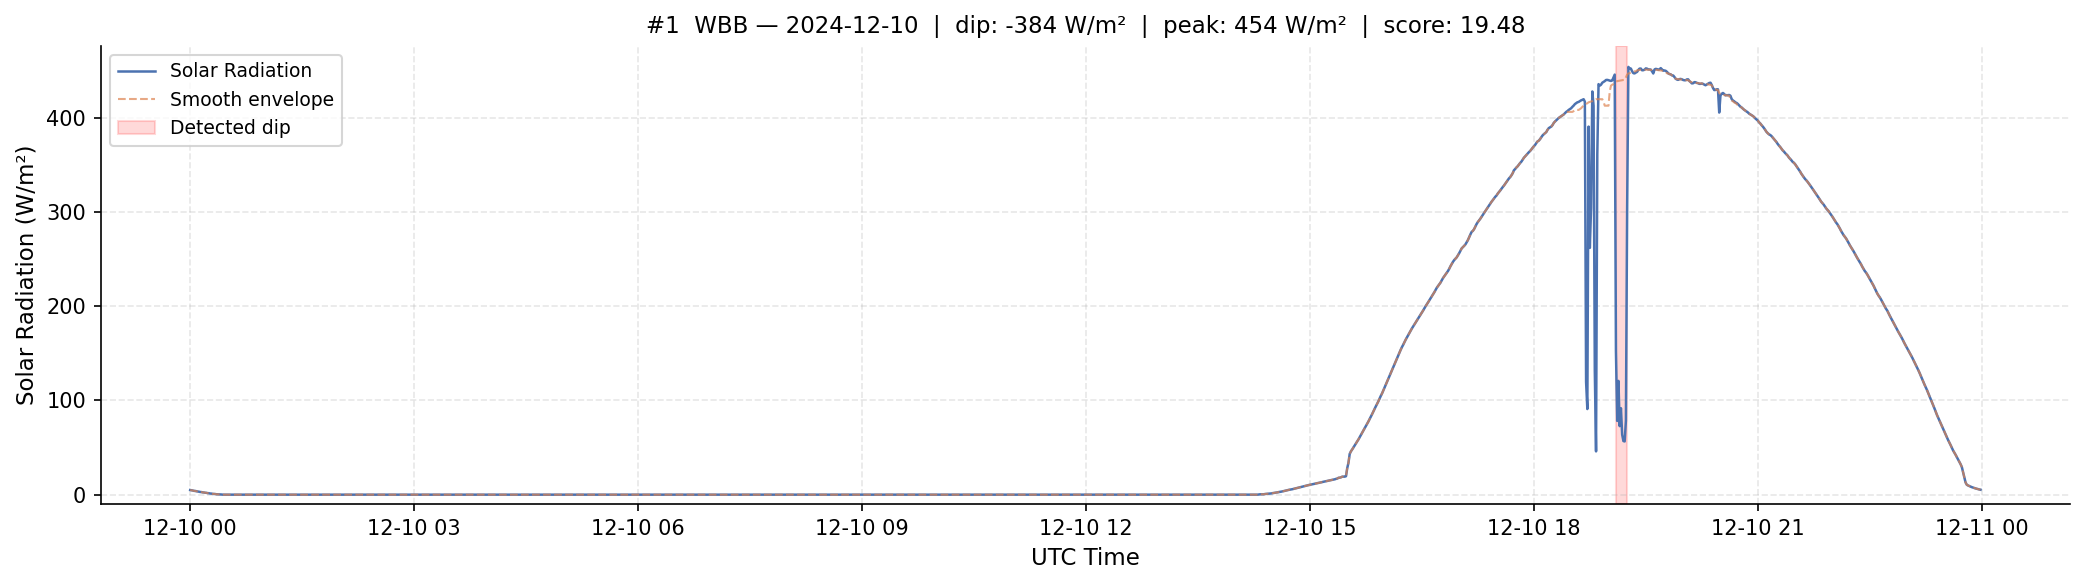

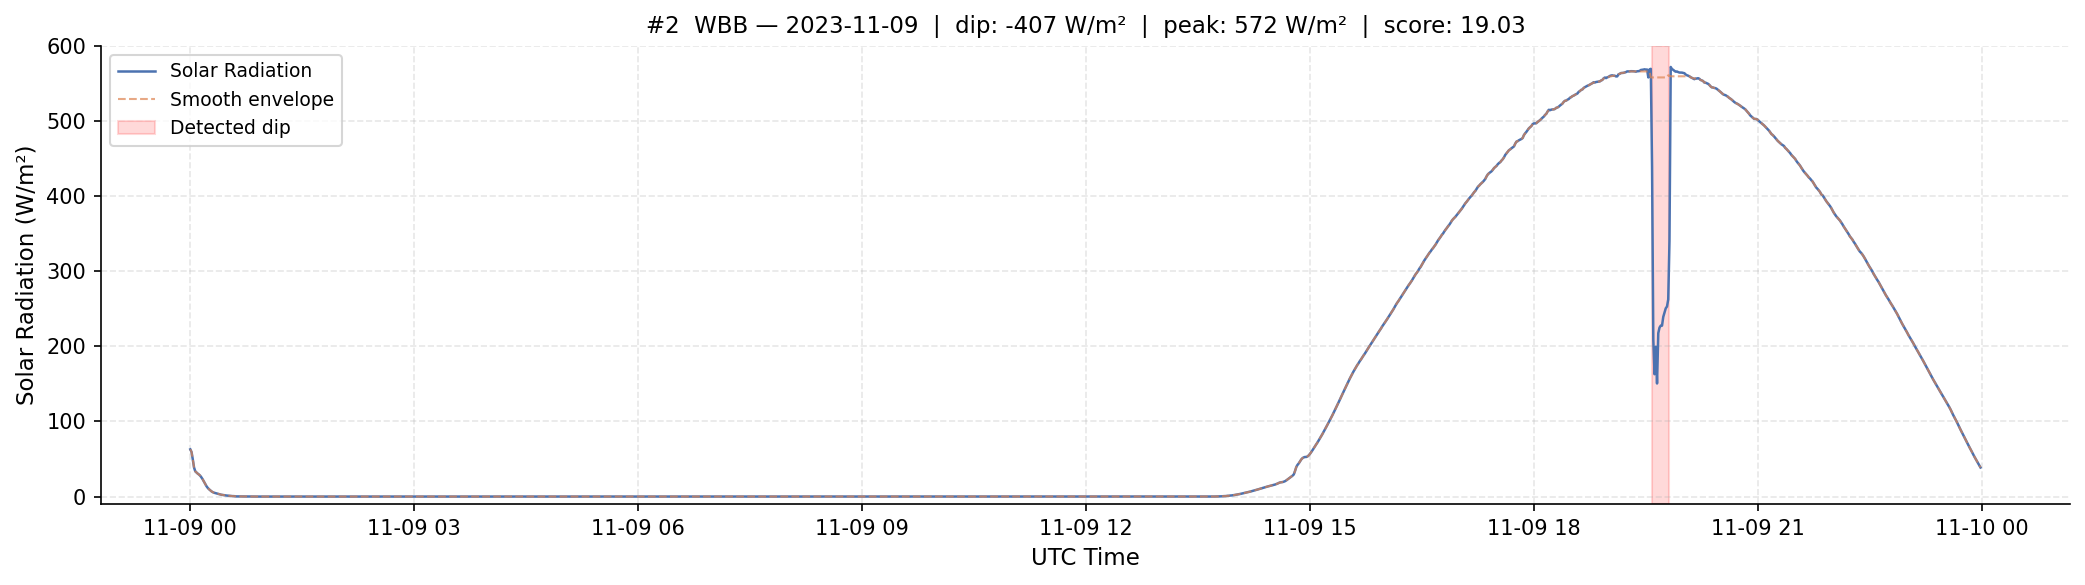

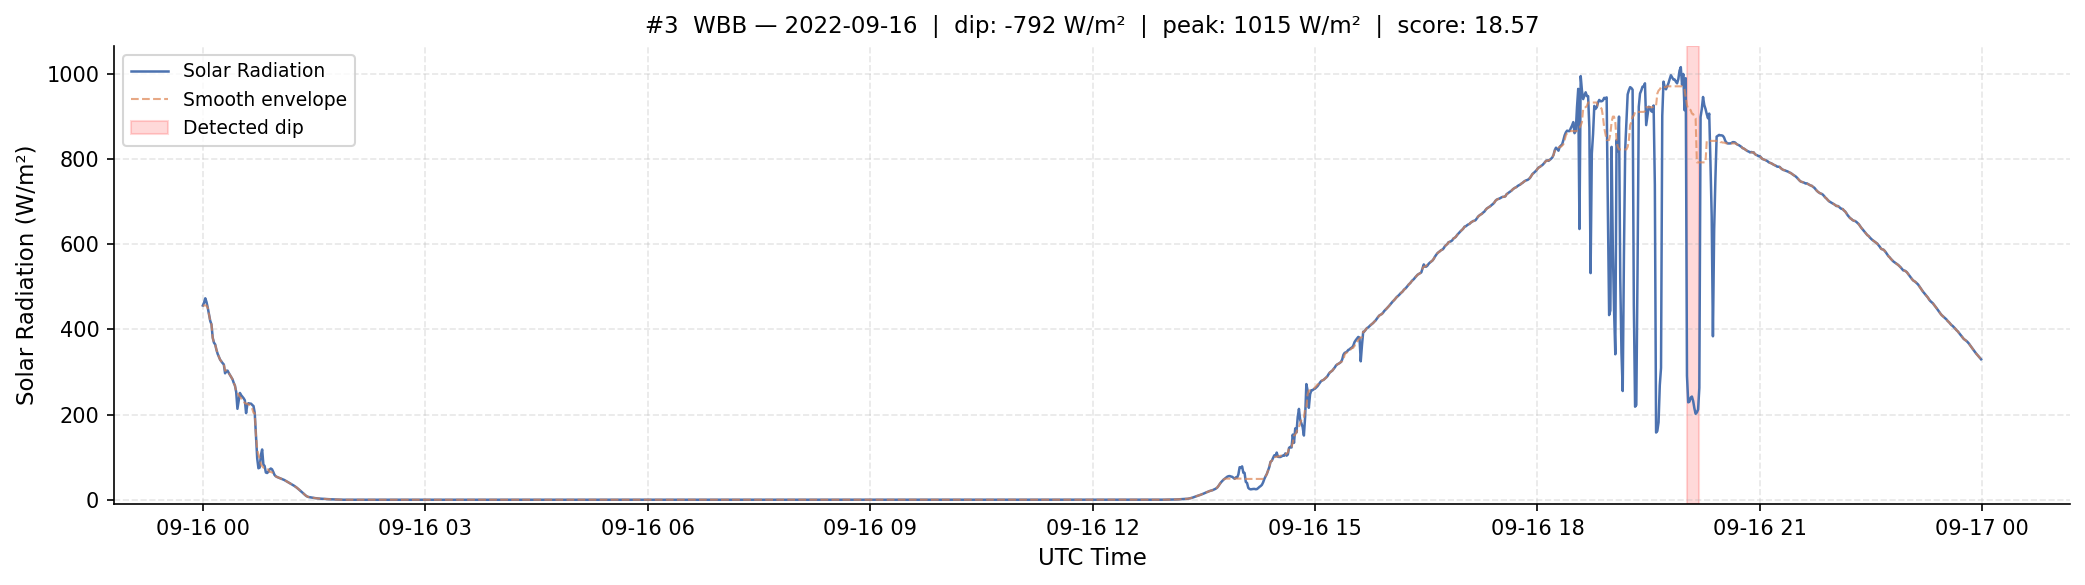

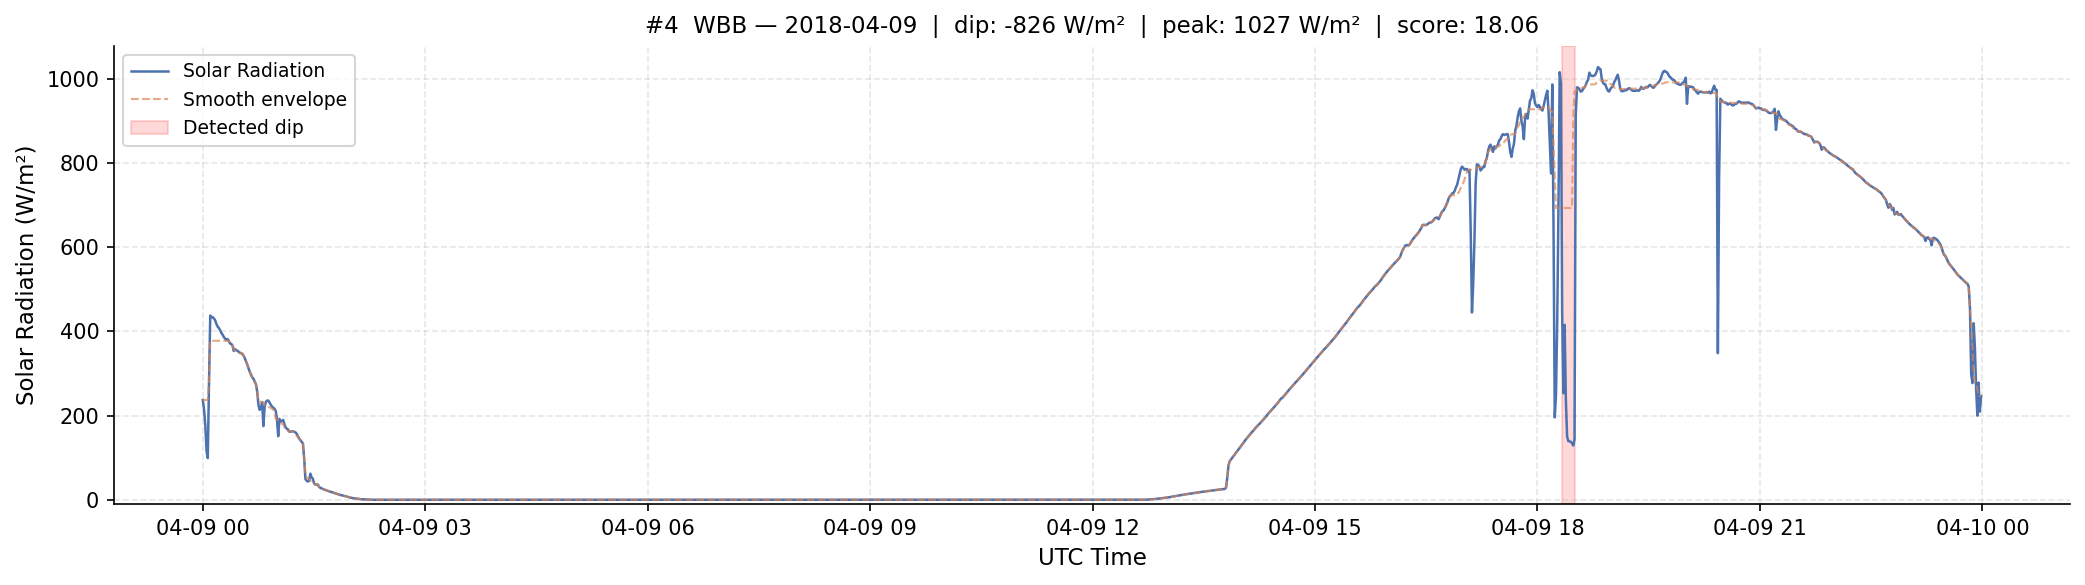

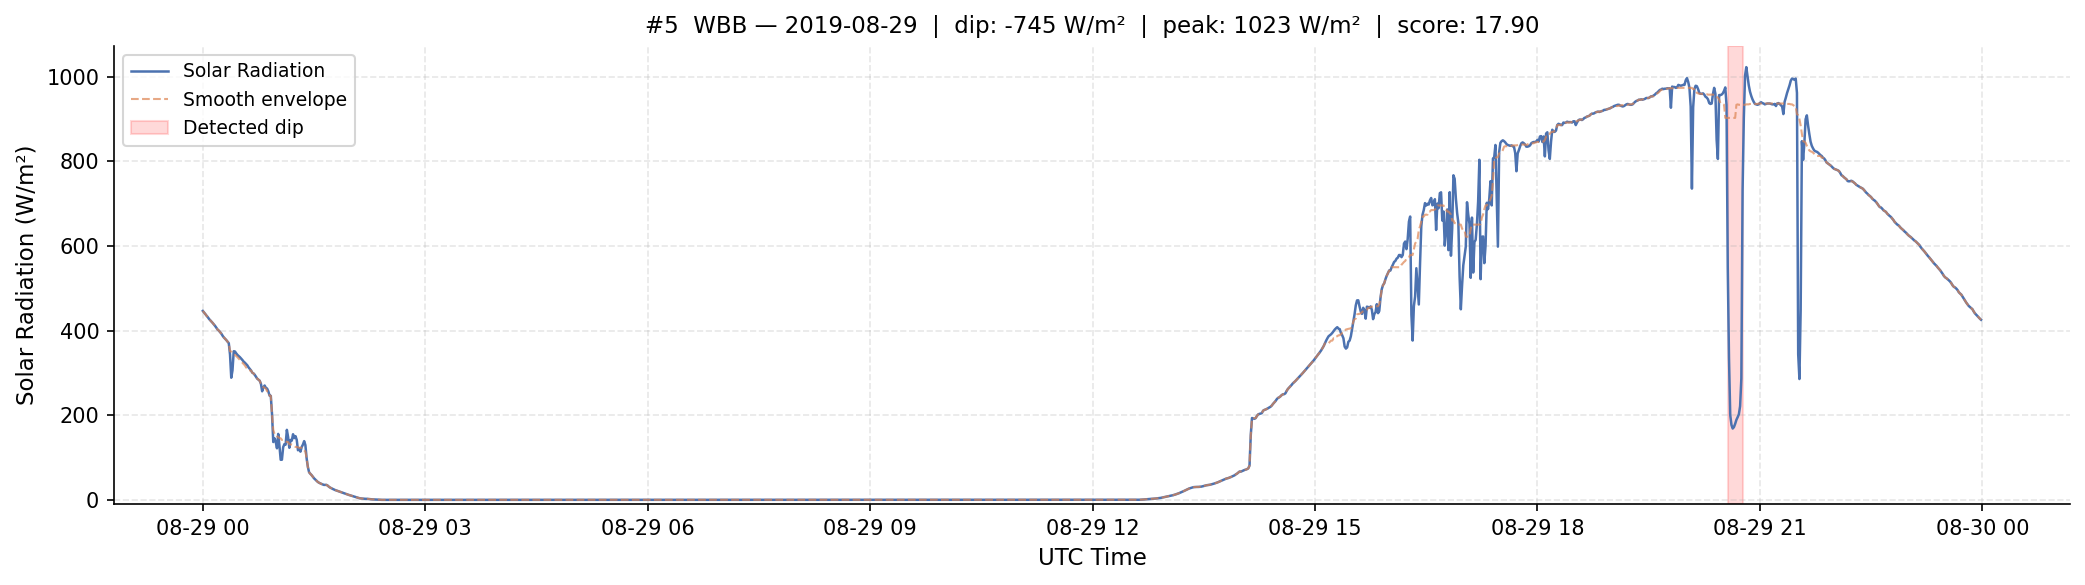

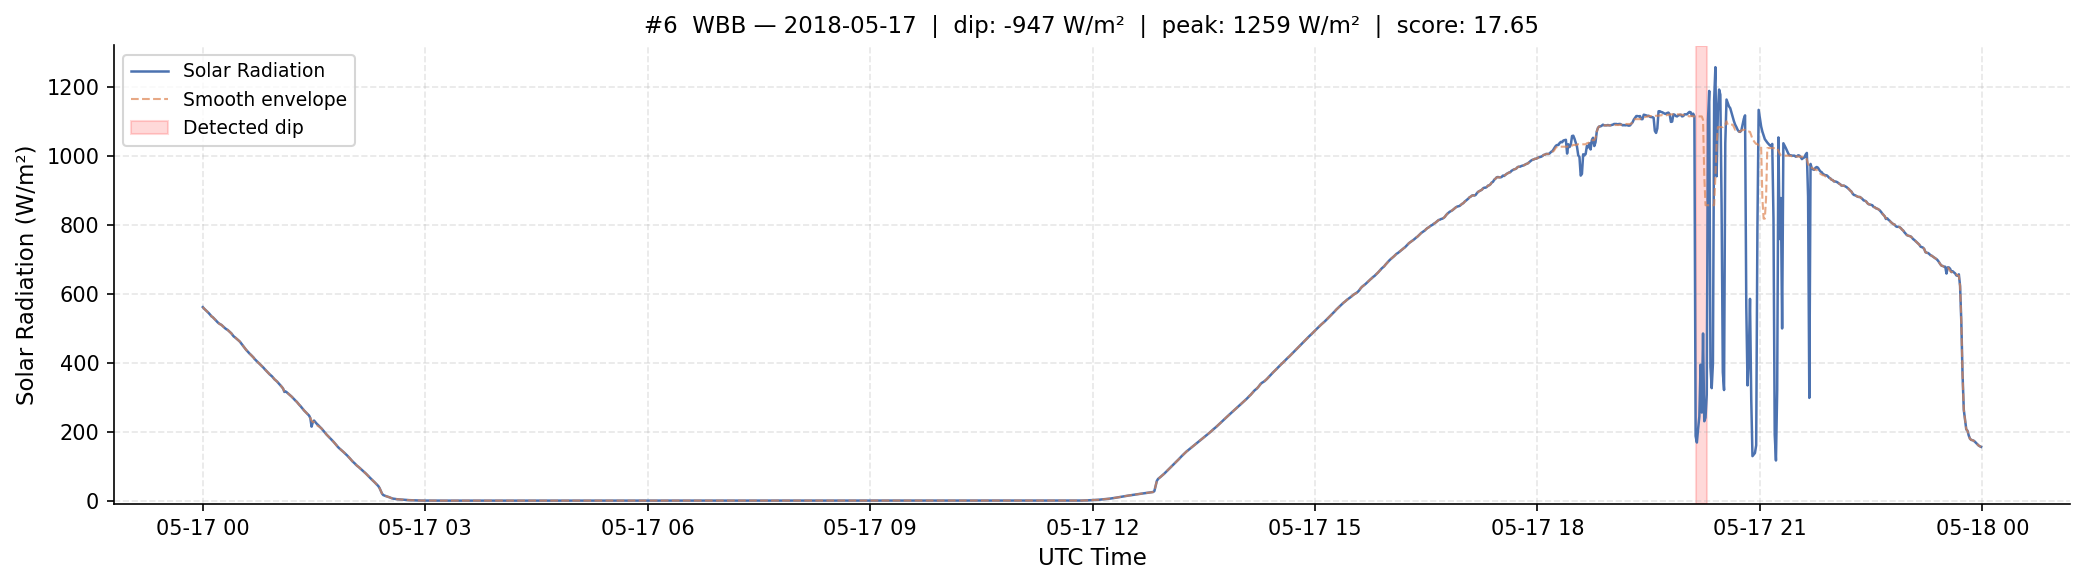

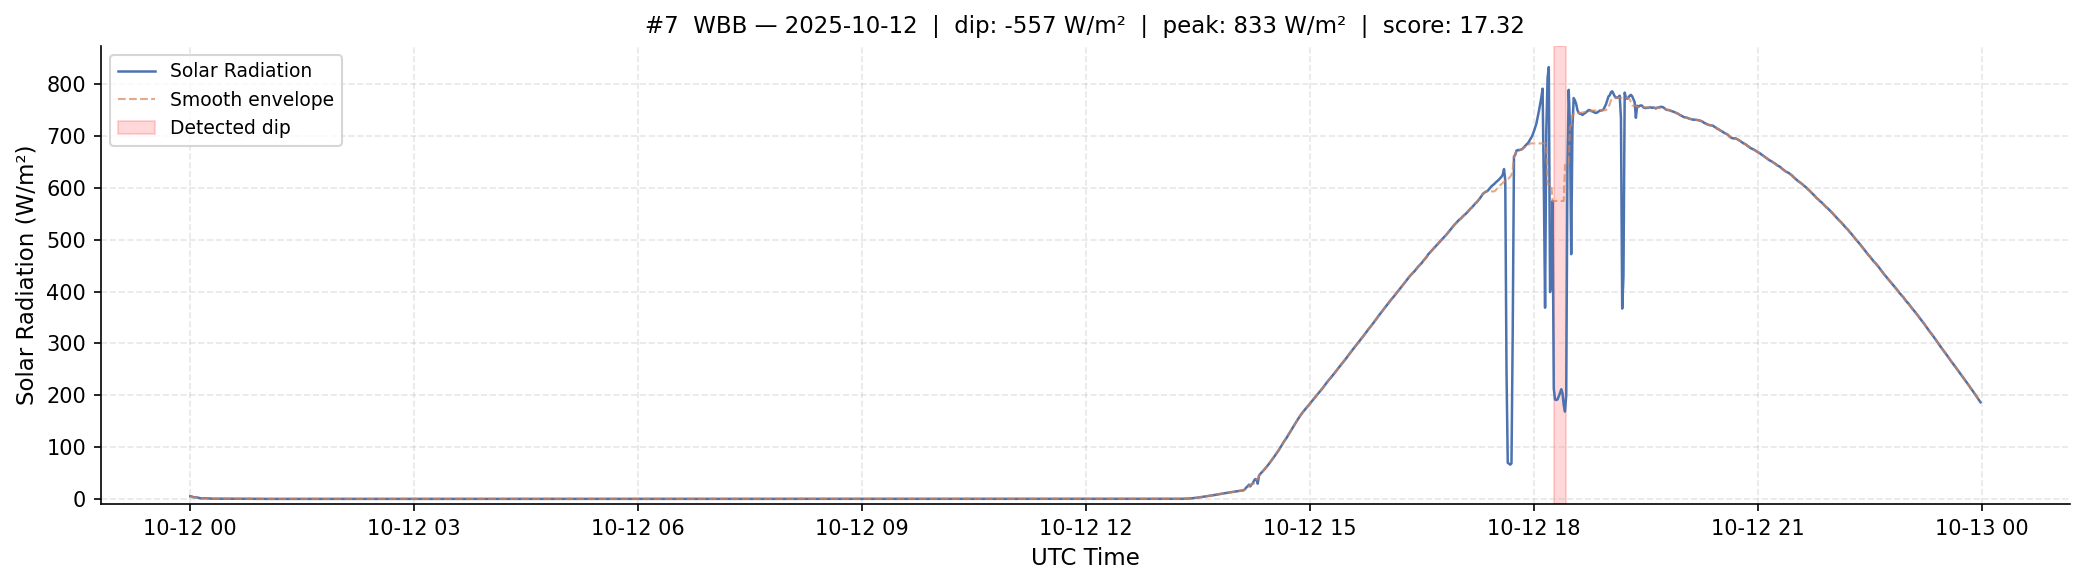

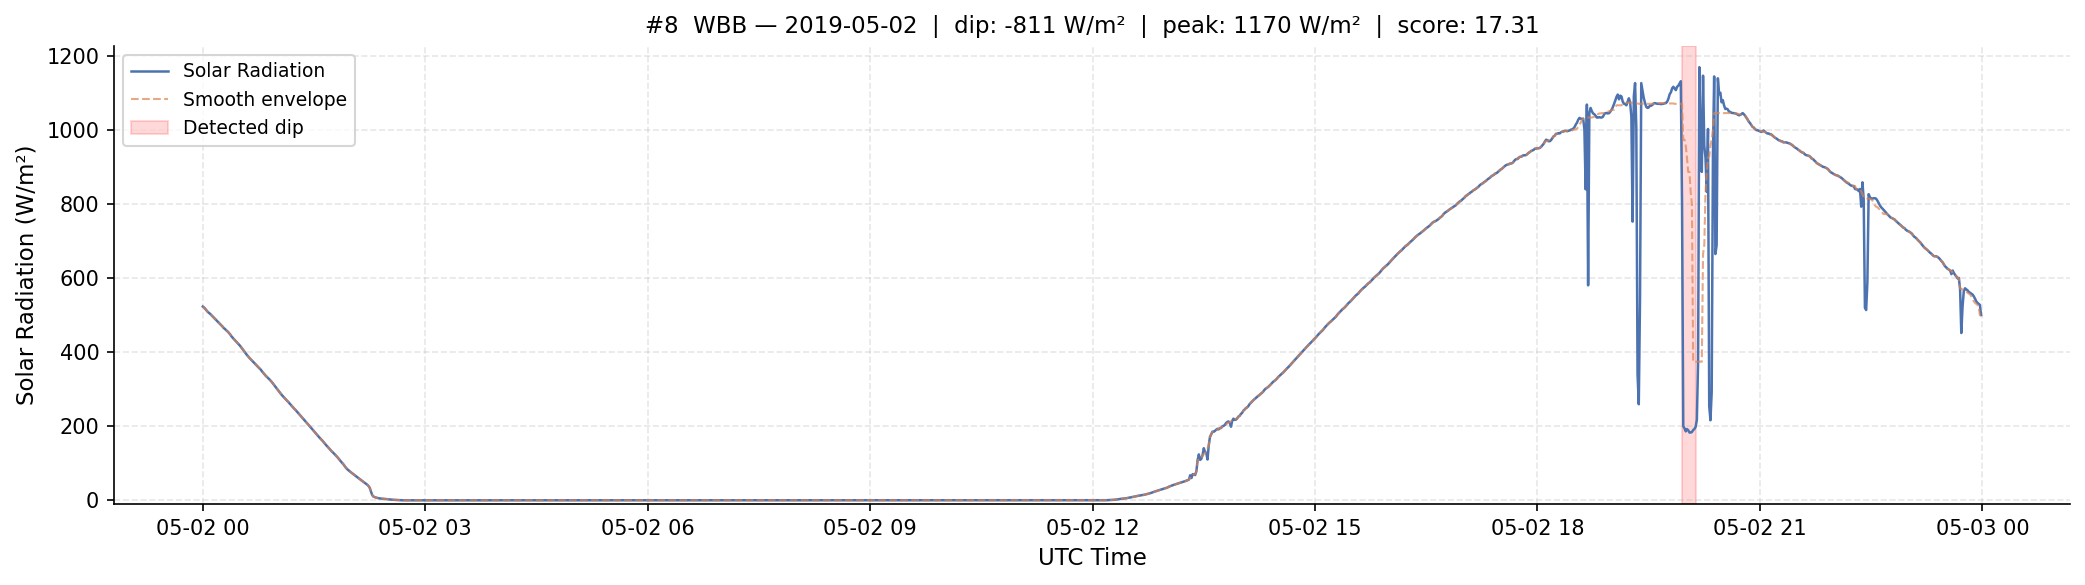

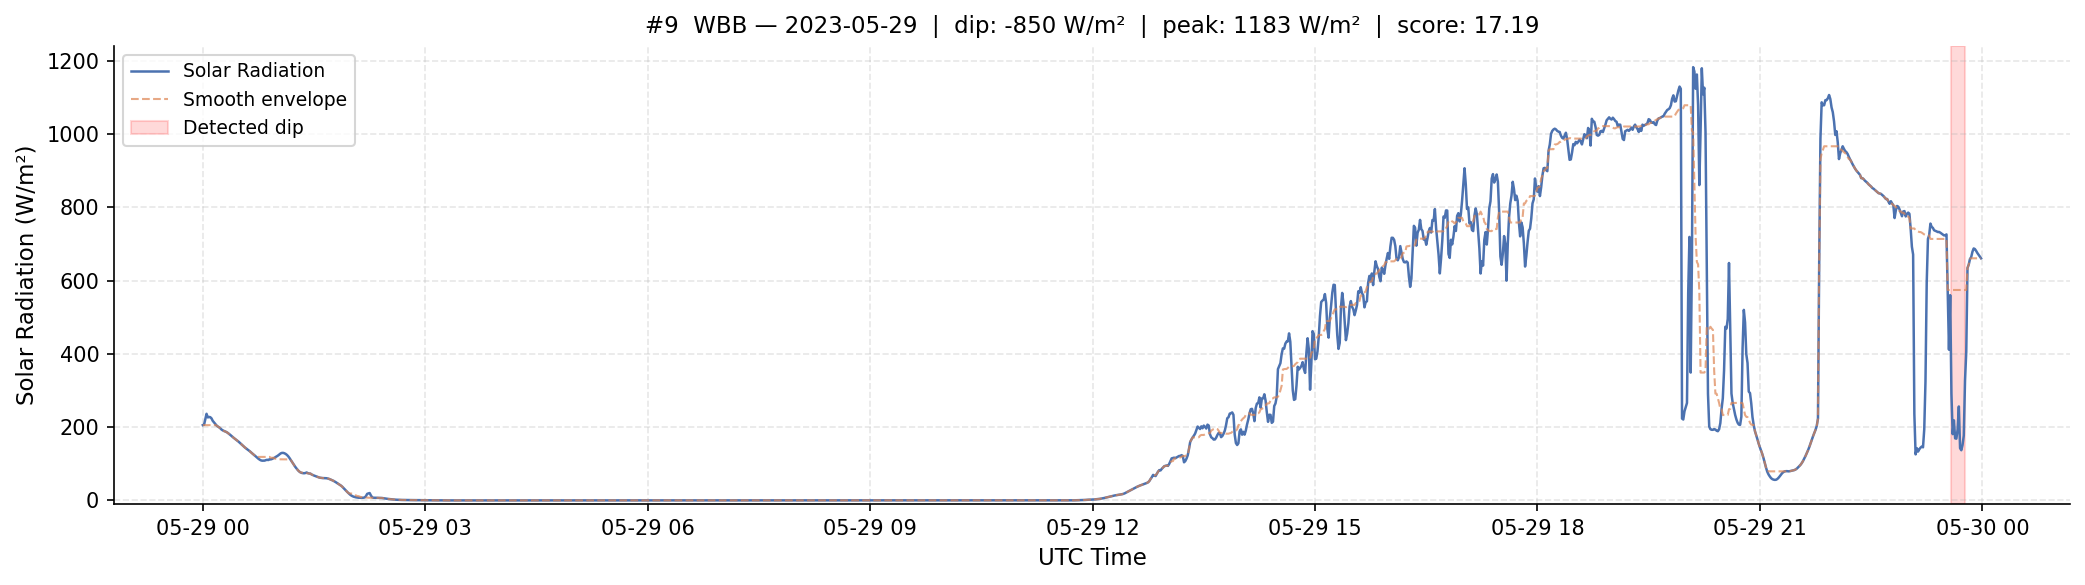

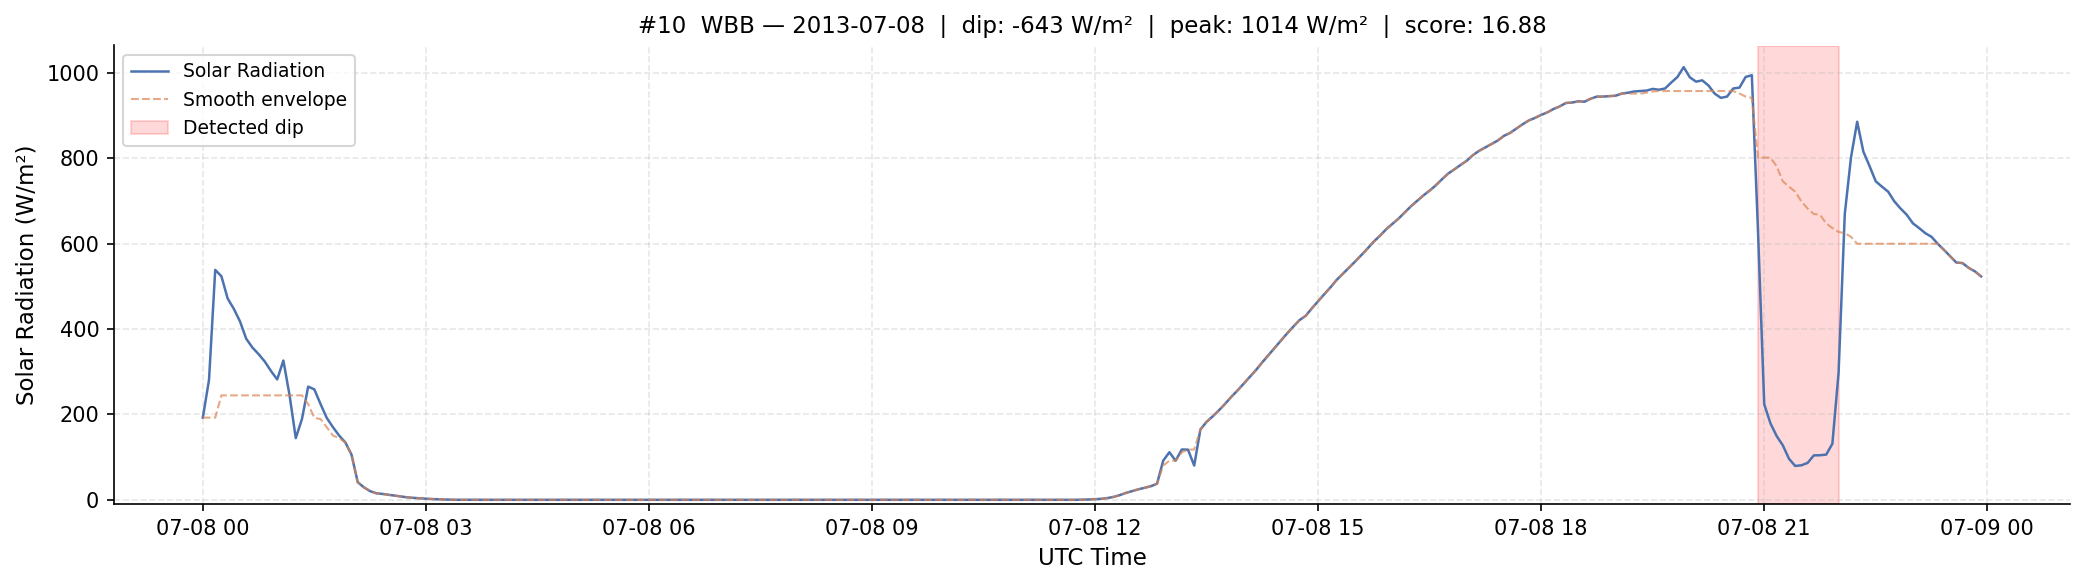

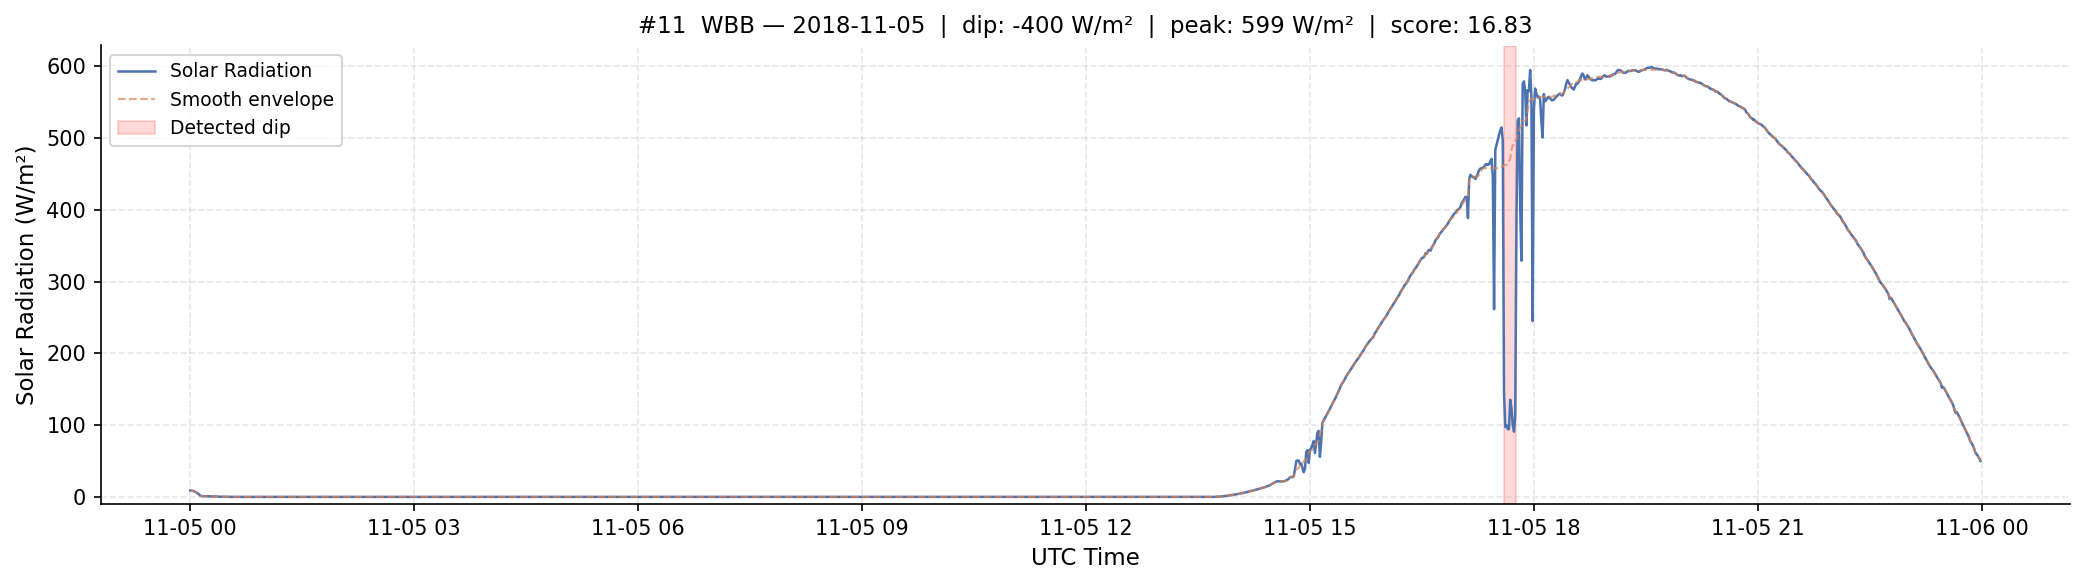

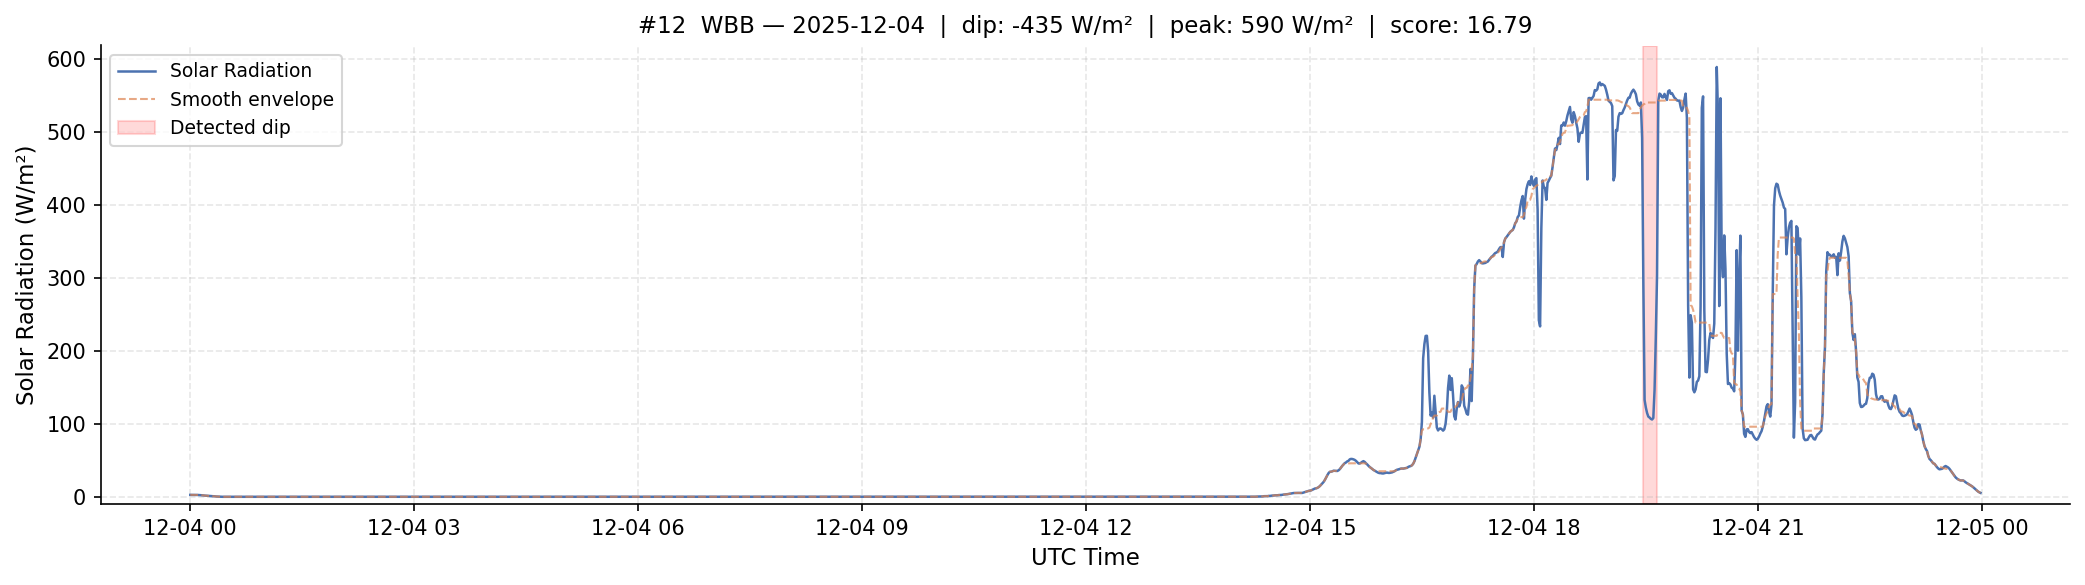

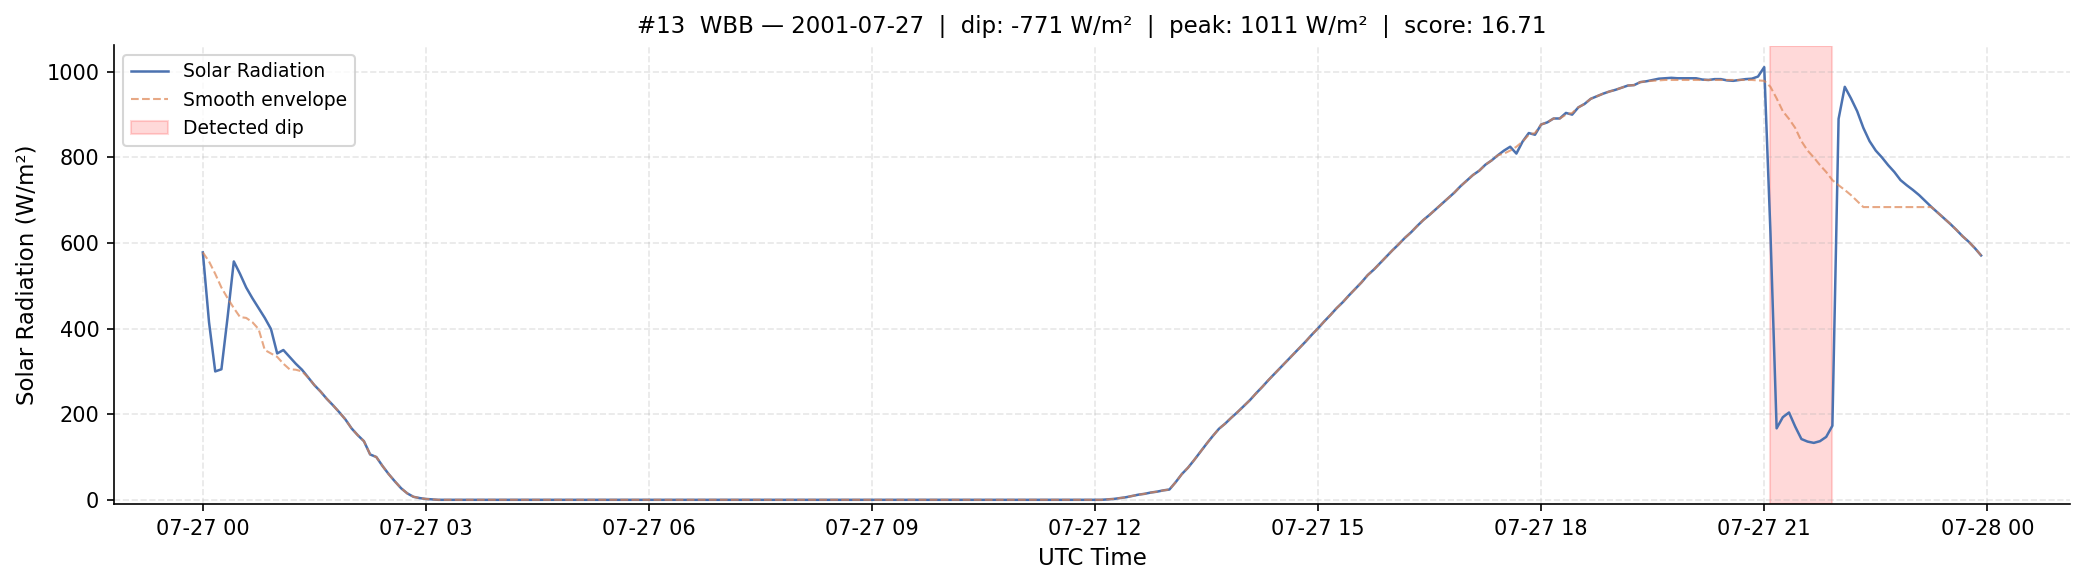

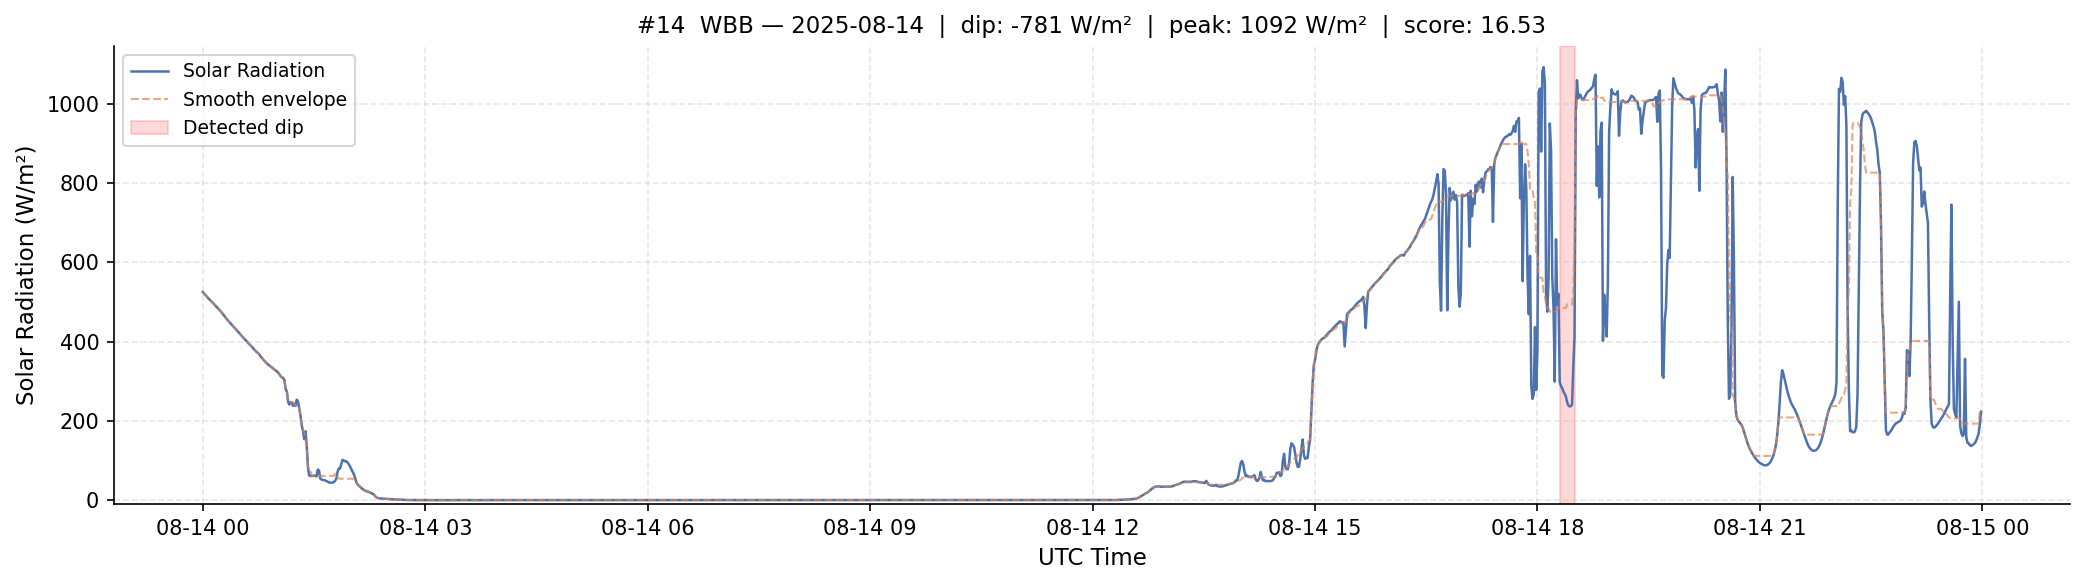

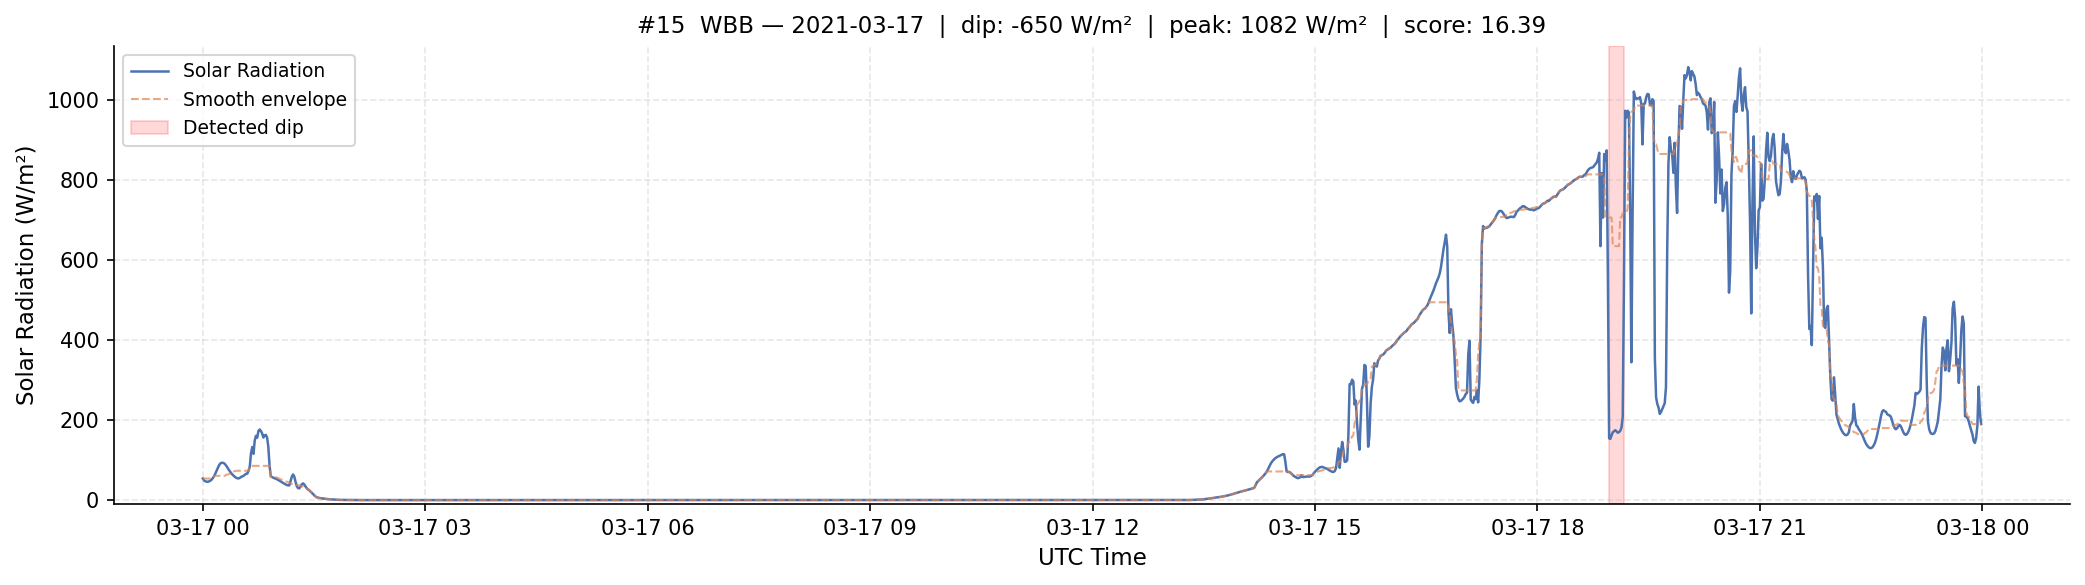

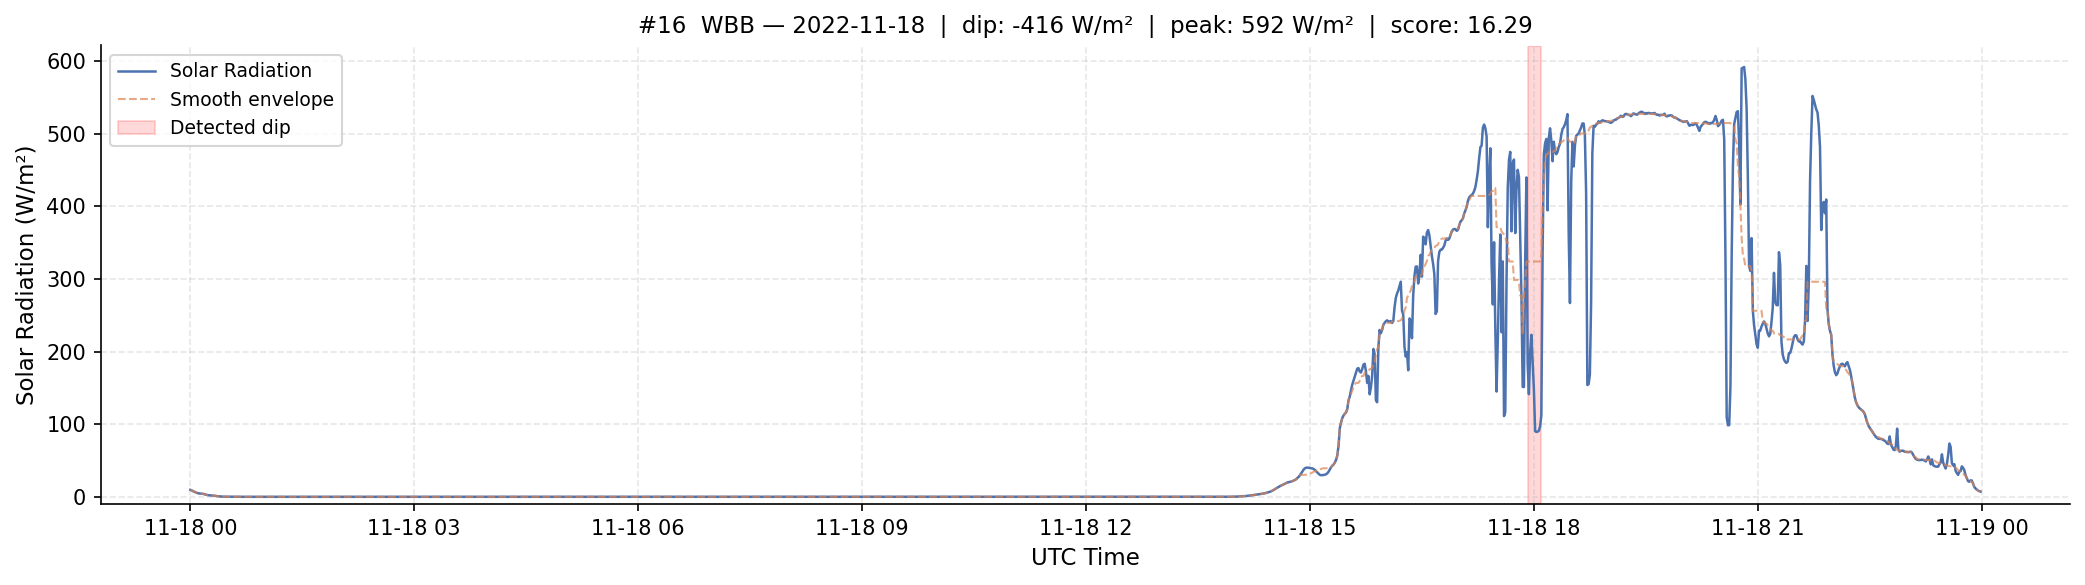

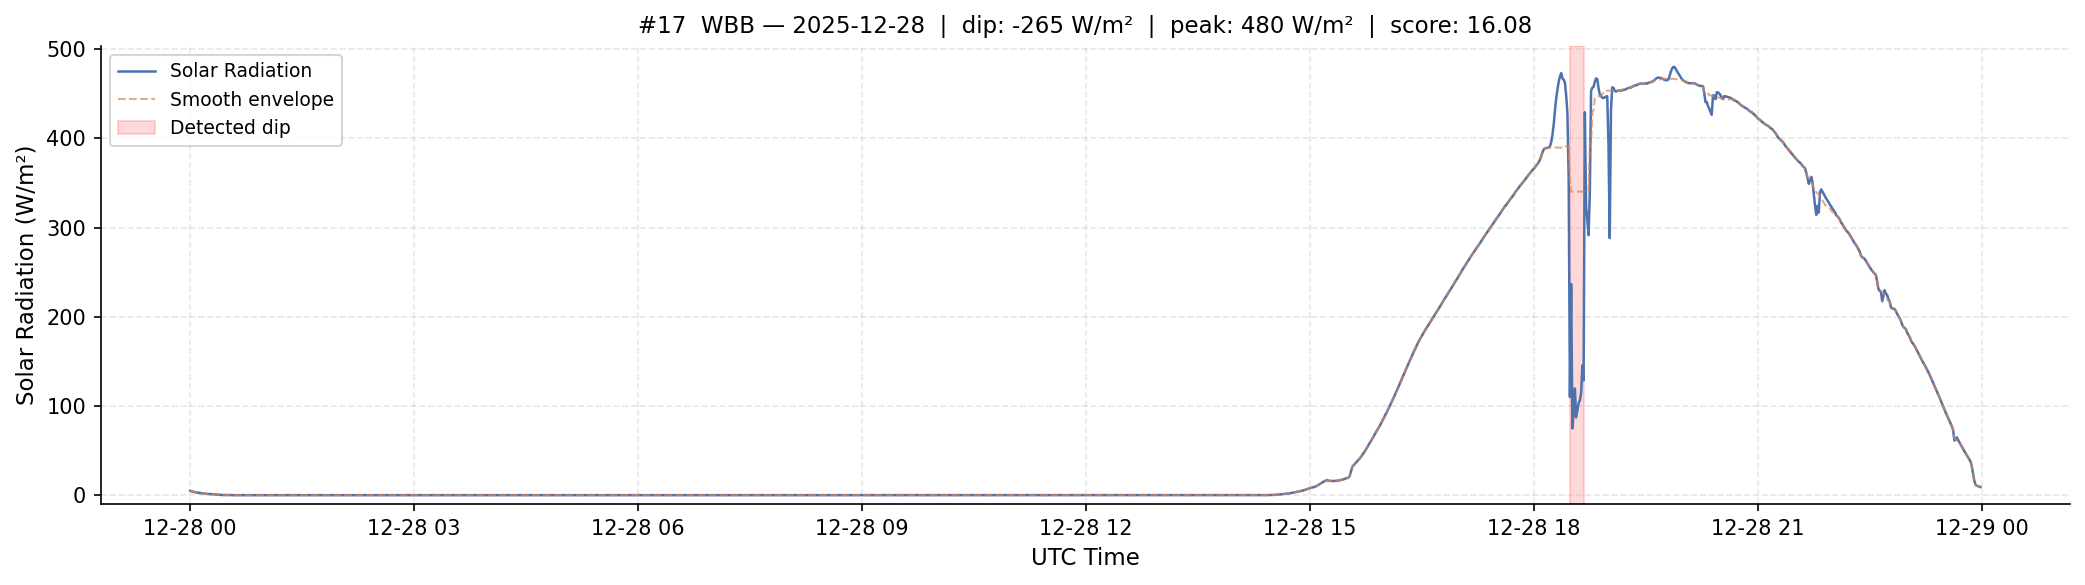

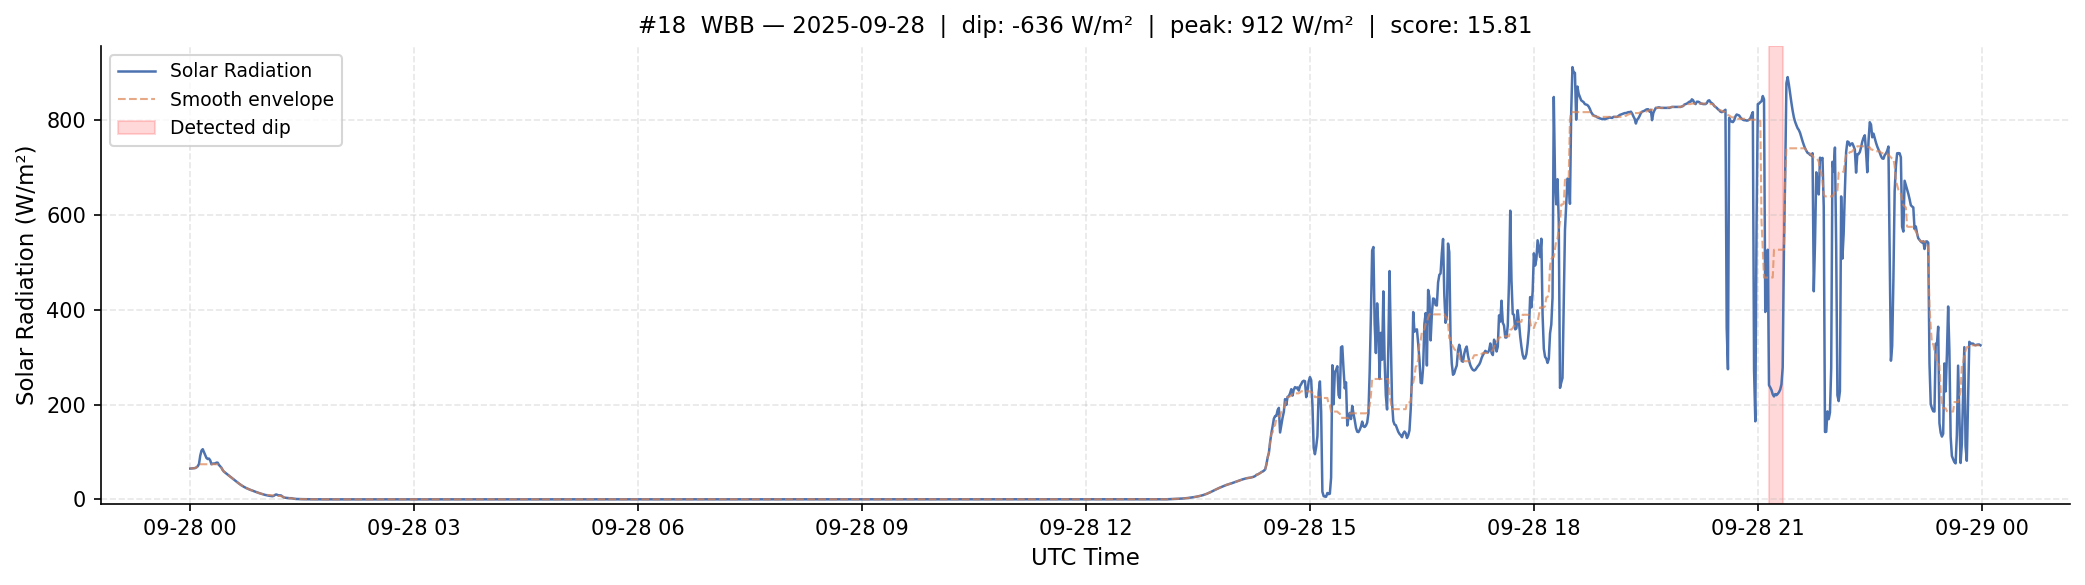

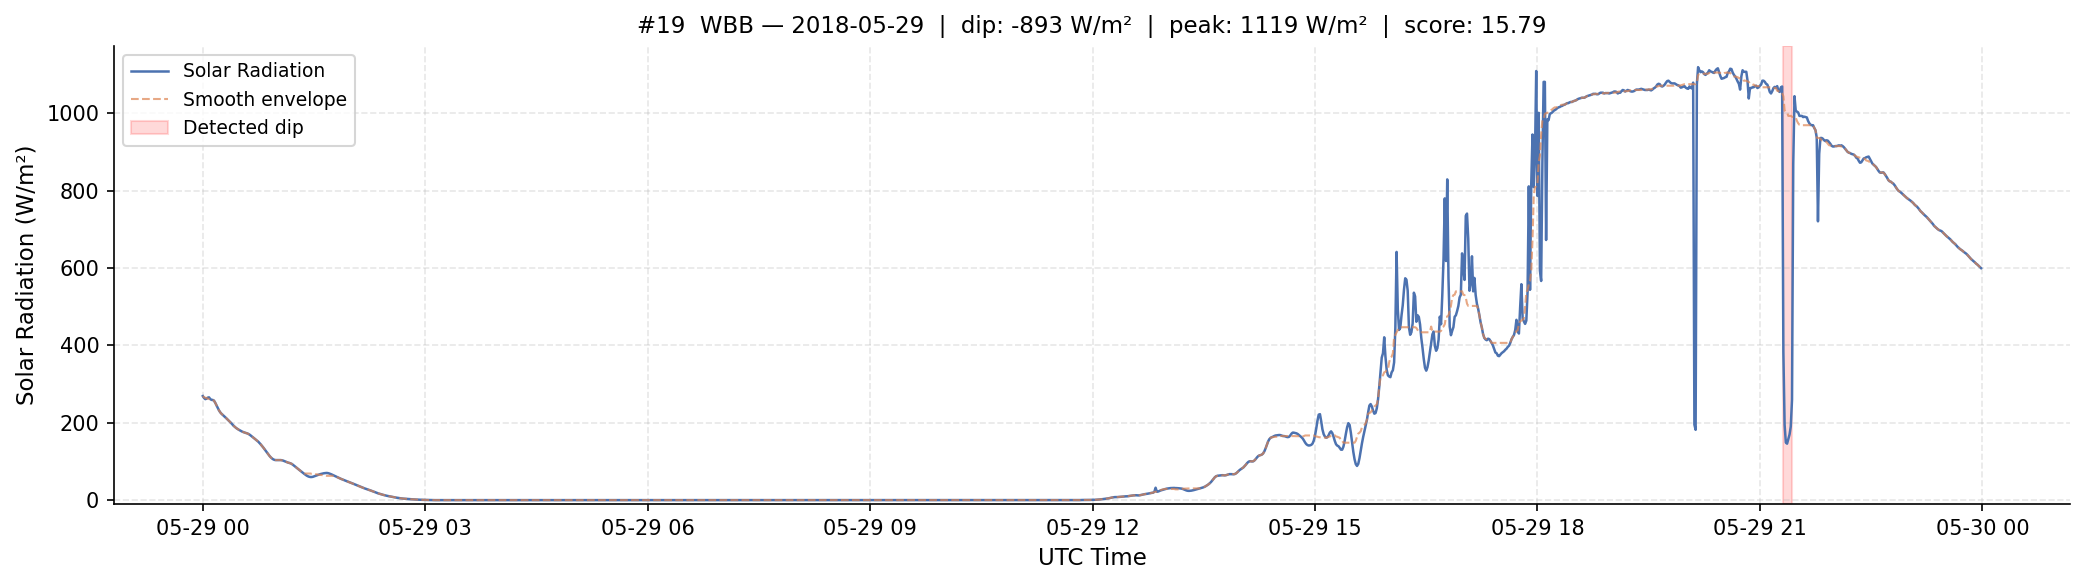

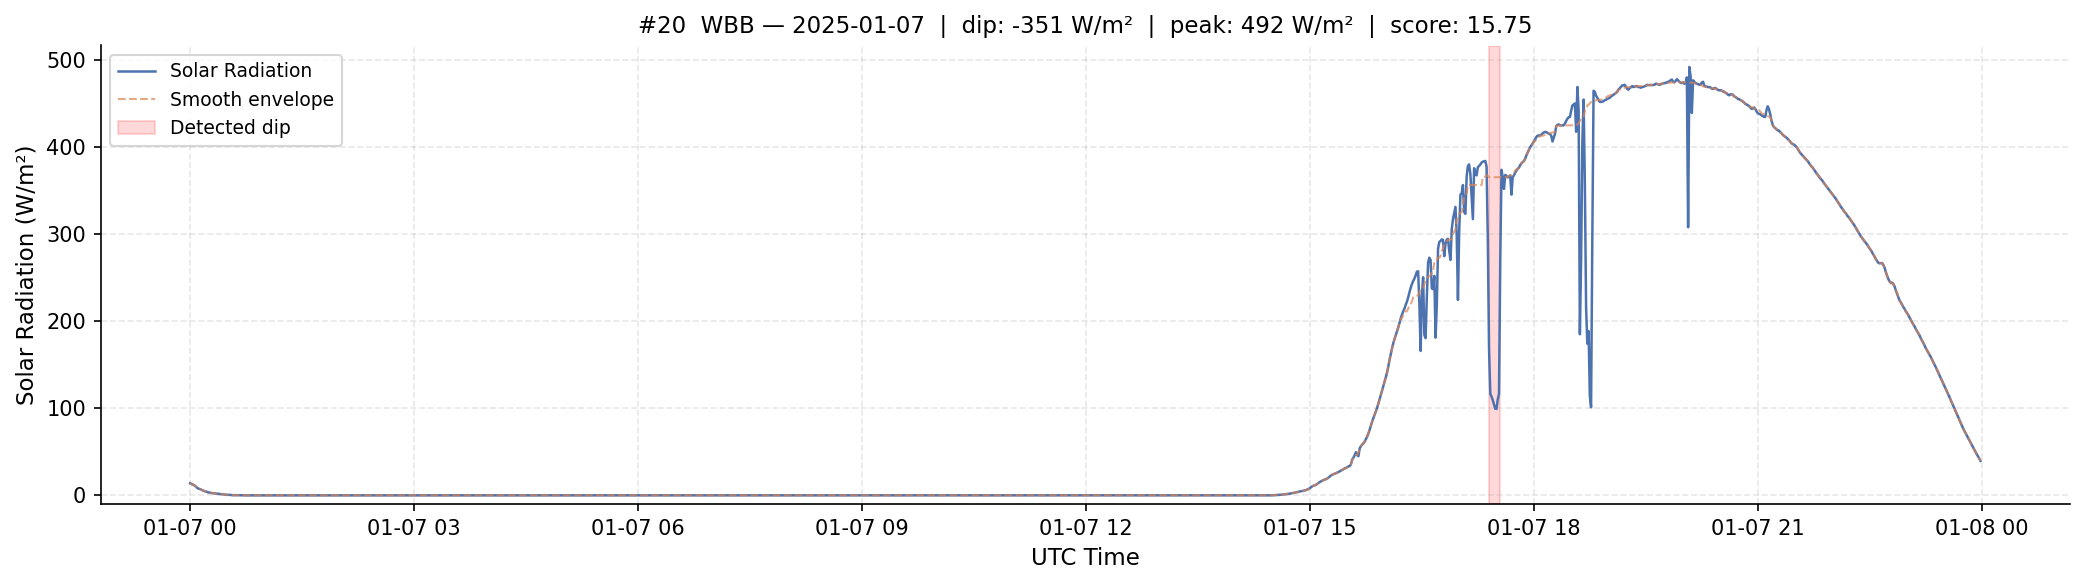

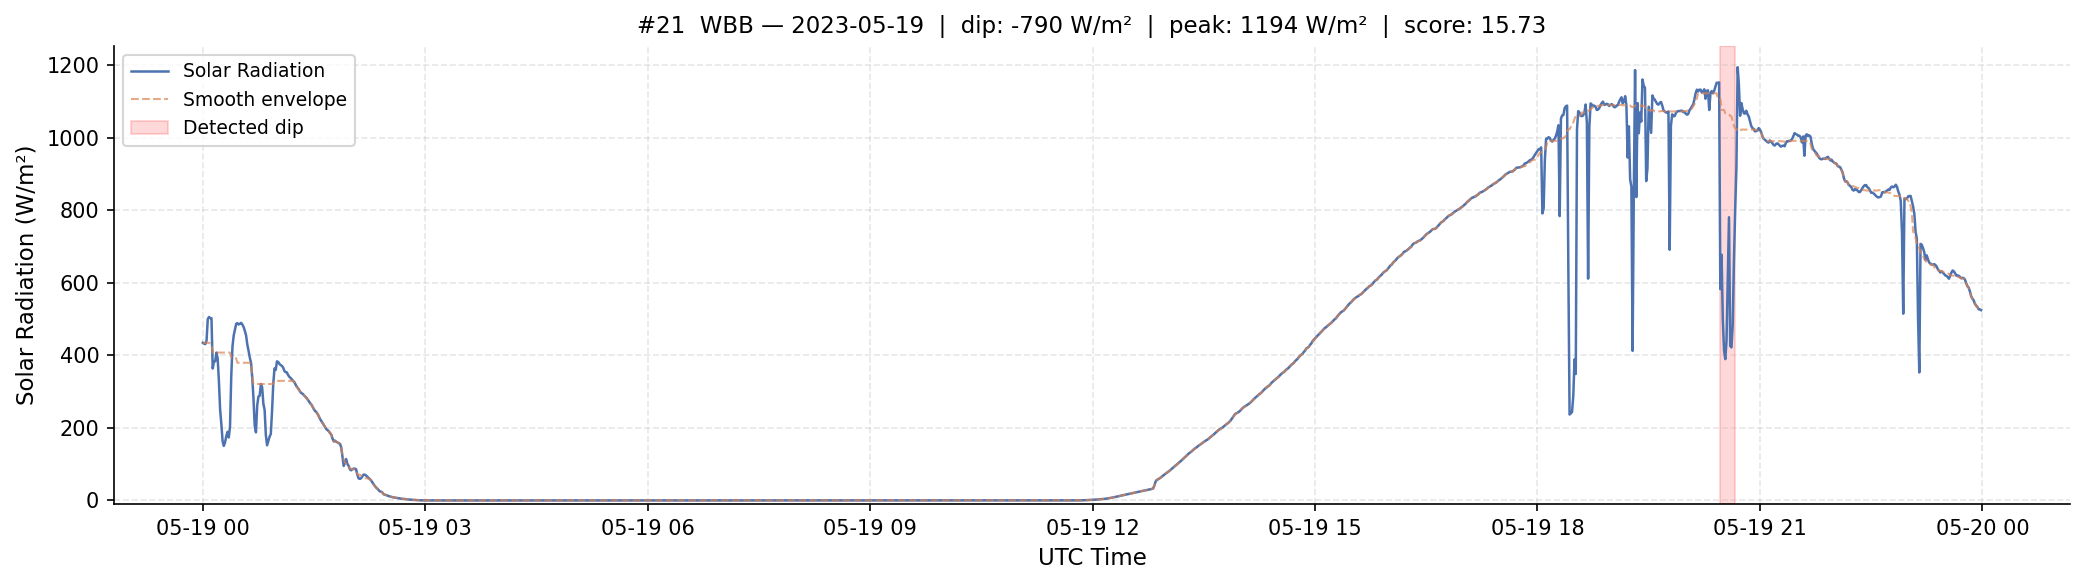

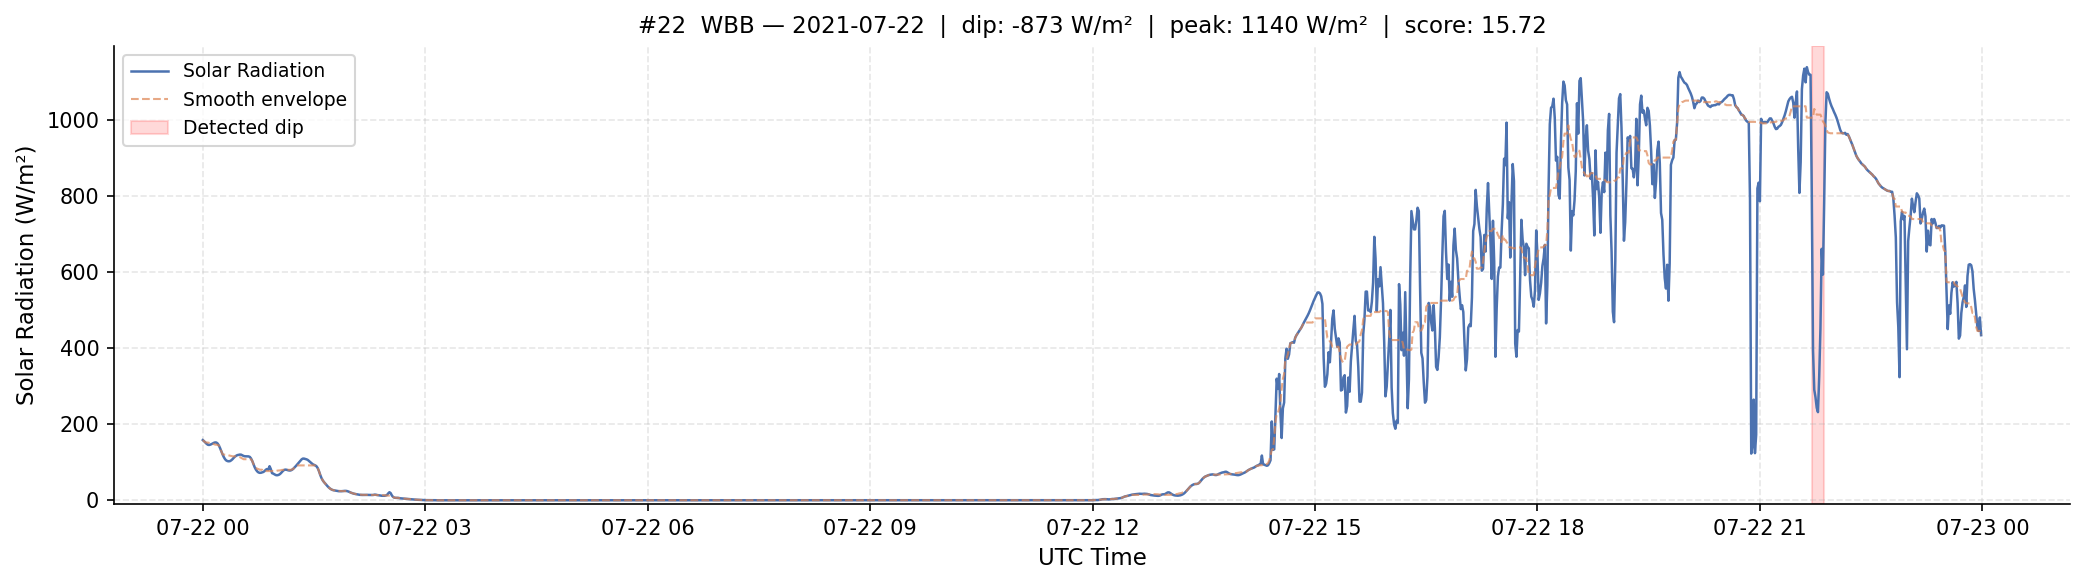

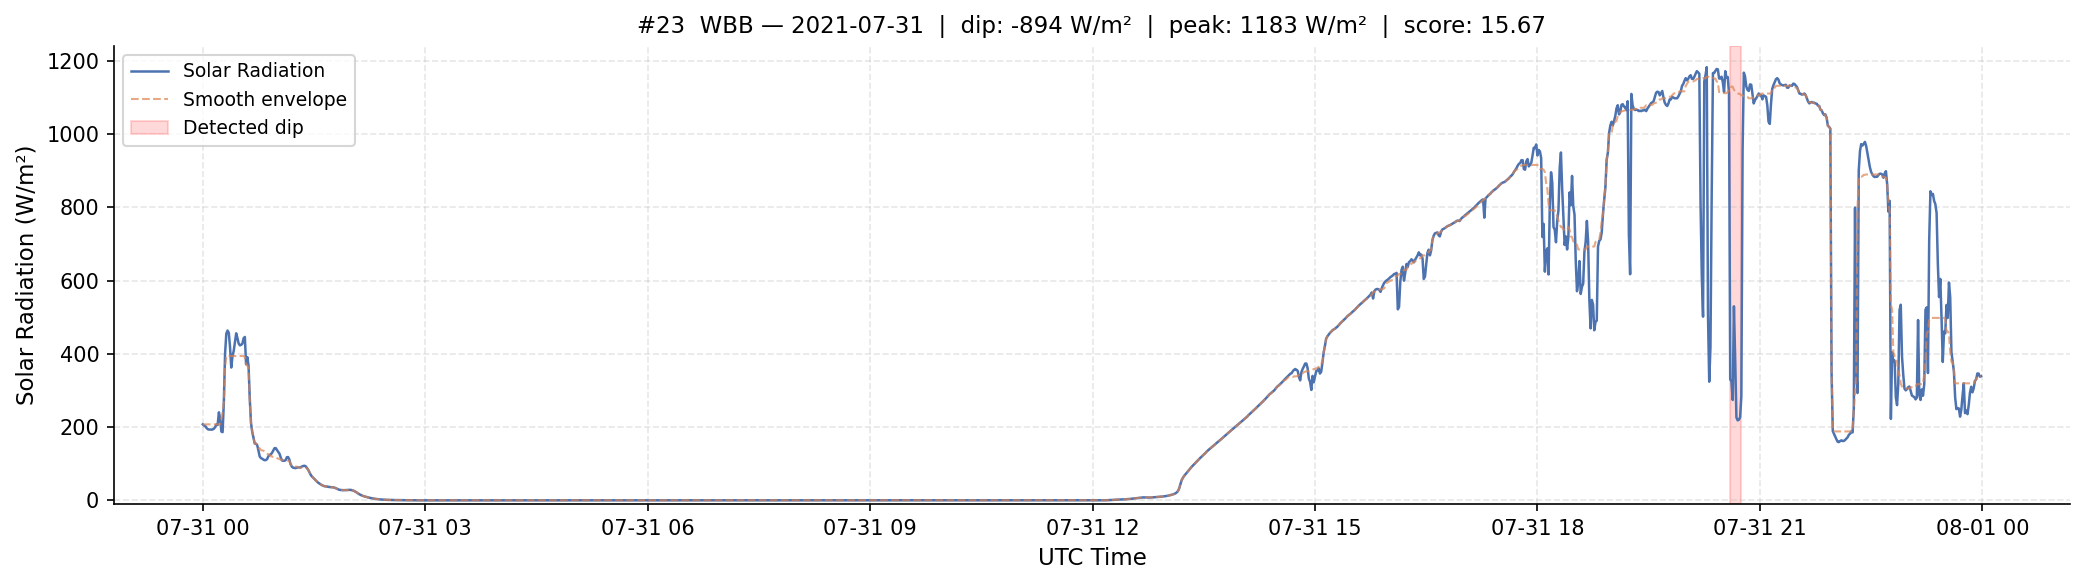

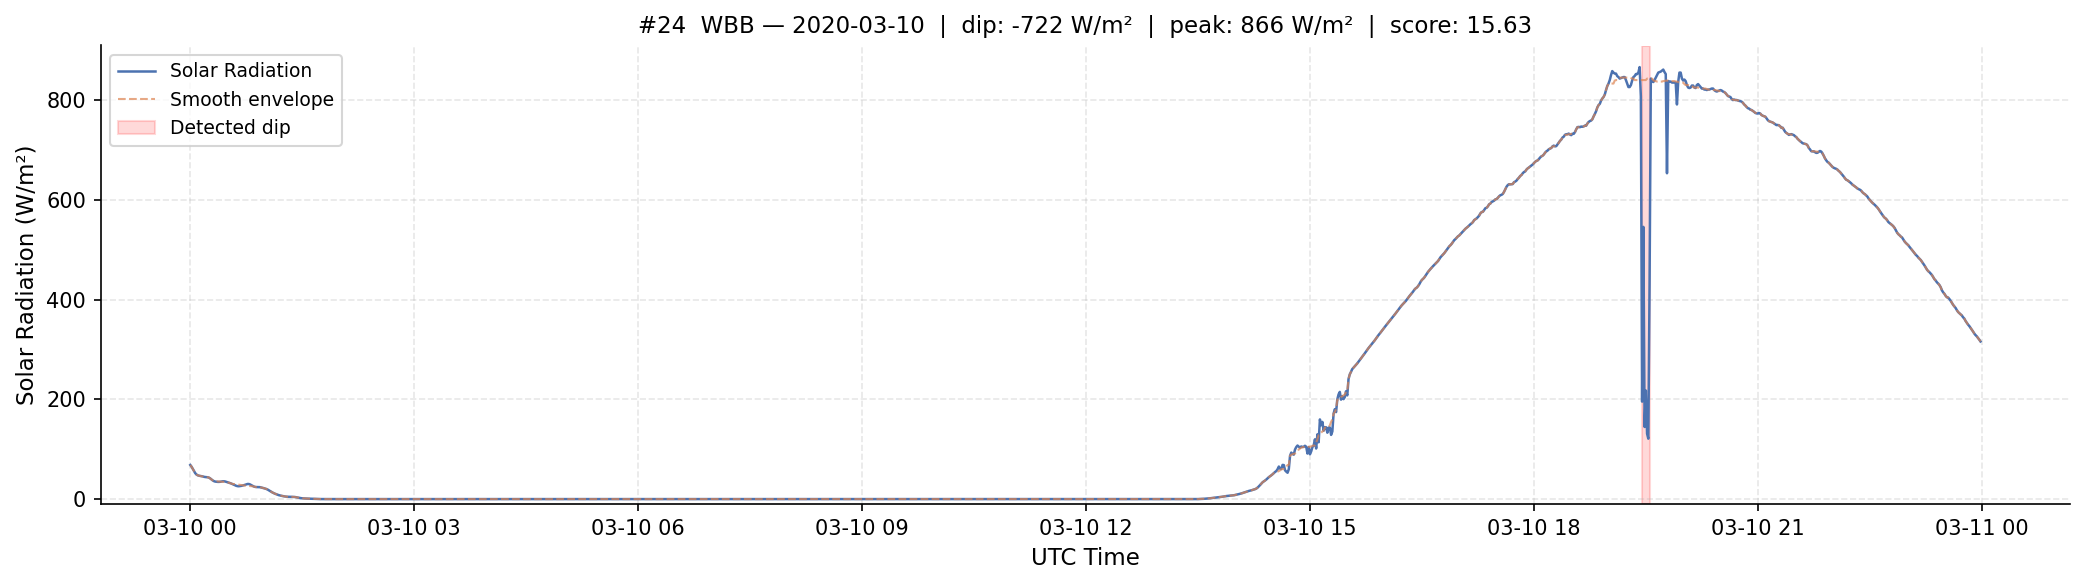

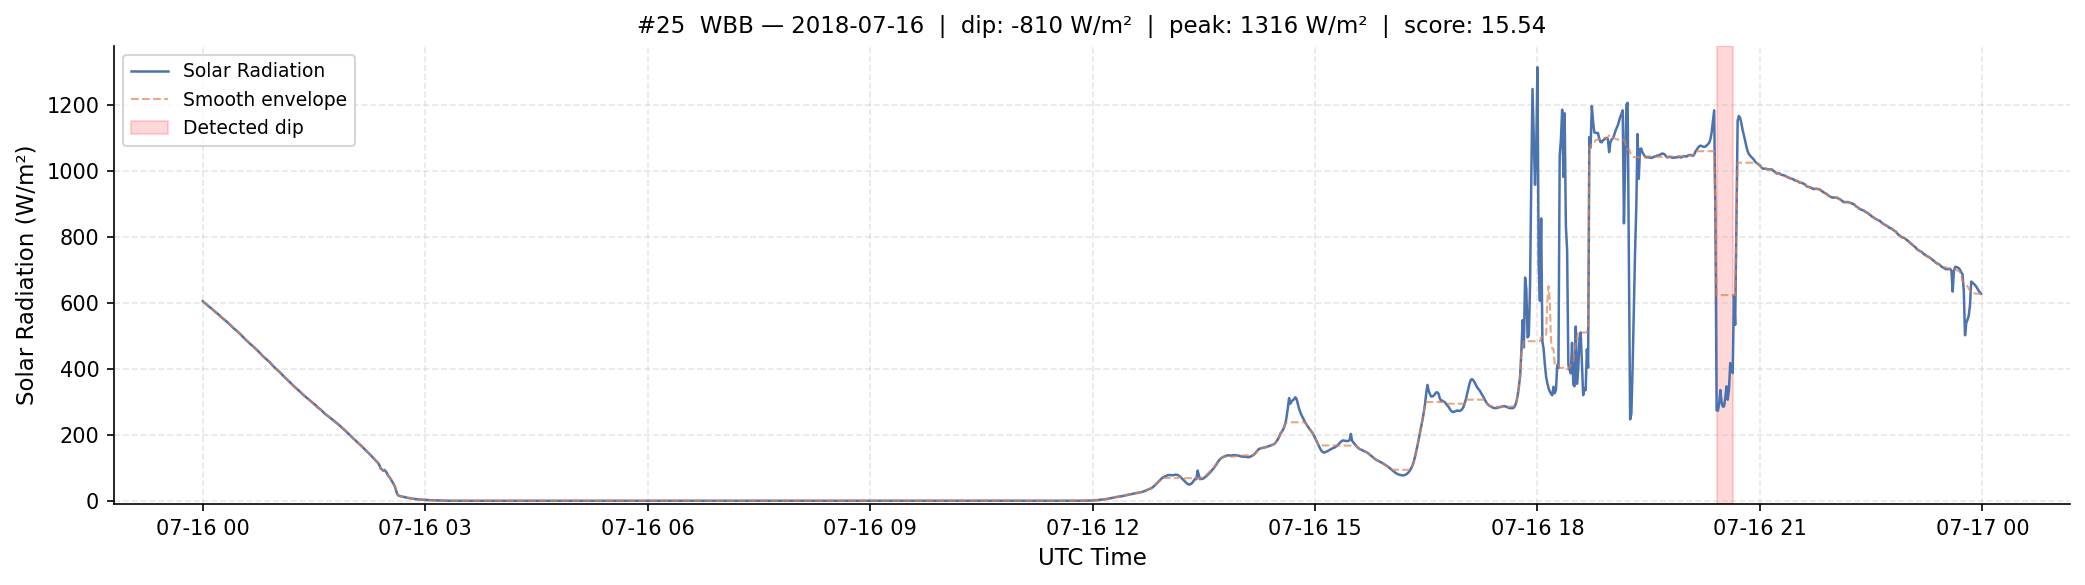

In [11]:
for rank, (score, day, info) in enumerate(scored[:TOP_N], 1):
    fig, ax = plt.subplots(figsize=(14, 4), dpi=150)
    t = day['time']
    s = day['solar']

    ax.plot(t, s, color='#4C72B0', linewidth=1.2, label='Solar Radiation')

    if 'smooth' in info and len(info['smooth']) == len(s):
        ax.plot(t, info['smooth'], color='#DD8452', linewidth=1.0,
                linestyle='--', alpha=0.7, label='Smooth envelope')

    if 'region' in info:
        a, b = info['region']
        ax.axvspan(t[a], t[b], alpha=0.15, color='red', label='Detected dip')

    ax.set_xlabel('UTC Time', fontsize=11)
    ax.set_ylabel('Solar Radiation (W/m²)', fontsize=11)
    ax.set_title(f"#{rank}  WBB — {day['date']}  |  "
                 f"dip: {info['depth']:.0f} W/m²  |  "
                 f"peak: {day['peak']:.0f} W/m²  |  "
                 f"score: {score:.2f}", fontsize=11)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(bottom=-10)
    plt.tight_layout()
    plt.show()

In [12]:
KEEP_RANKS = [1, 2, 5, 17, 25]

In [13]:
rows = []
for rank, (score, day, info) in enumerate(scored[:TOP_N], 1):
    if rank in KEEP_RANKS:
        rows.append({
            'rank': rank,
            'date': day['date'],
            'timestamps': np.array(day['time']),
            'solar': np.array(day['solar']),
        })
 
df_slices = pd.DataFrame(rows)
print(df_slices[['rank', 'date']].to_string(index=False))
print()
for _, row in df_slices.iterrows():
    print(f"Rank {row['rank']}  {row['date']}  —  "
          f"{len(row['timestamps'])} points,  "
          f"solar range [{row['solar'].min():.0f}, {row['solar'].max():.0f}]")
df_slices

 rank       date
    1 2024-12-10
    2 2023-11-09
    5 2019-08-29
   17 2025-12-28
   25 2018-07-16

Rank 1  2024-12-10  —  1440 points,  solar range [0, 454]
Rank 2  2023-11-09  —  1440 points,  solar range [0, 572]
Rank 5  2019-08-29  —  1440 points,  solar range [0, 1023]
Rank 17  2025-12-28  —  1440 points,  solar range [0, 480]
Rank 25  2018-07-16  —  1440 points,  solar range [0, 1316]


,rank,date,timestamps,solar
0,1,2024-12-10,"[2024-12-10T00:00:00.000000000, 2024-12-10T00:...","[4.93, 4.71, 4.42, 4.07, 3.93, 3.63, 3.38, 3.1..."
1,2,2023-11-09,"[2023-11-09T00:00:00.000000000, 2023-11-09T00:...","[62.84, 59.25, 49.47, 38.71, 33.6, 32.0, 30.47..."
2,5,2019-08-29,"[2019-08-29T00:00:00.000000000, 2019-08-29T00:...","[446.6, 443.1, 439.3, 435.4, 432.0, 427.8, 424..."
3,17,2025-12-28,"[2025-12-28T00:00:00.000000000, 2025-12-28T00:...","[4.96, 4.44, 3.94, 3.62, 3.37, 3.01, 2.8, 2.61..."
4,25,2018-07-16,"[2018-07-16T00:00:00.000000000, 2018-07-16T00:...","[605.9, 602.0, 599.0, 595.7, 592.7, 589.4, 586..."


In [19]:
import numpy as np
import pandas as pd
import traceback
from benchmark_regressor_on_syth import _run_one, ALL_METHODS, _resolve_methods
import math
from helpers.config import ref_freq

families = _resolve_methods(
    "mean,poly_deg1,poly_deg2,nwkr_gaussian,nwkr_laplace,lrt,bocpd,capa", []
)

all_results = []

for idx, row in df_slices.iterrows():
    x     = np.asarray(row["solar"],      dtype=np.float64)
    times = np.asarray(row["timestamps"], dtype="datetime64[ns]")
    n     = len(x)

    if n < 10:
        print(f"Row {idx} too short ({n}), skipping")
        continue

    # Derive freq array from timestamps (convert to seconds, treat as GHz proxy)
    t_sec  = (times - times[0]).astype(np.float64) / 1e9  # nanoseconds → seconds
    # Normalise to GHz-like units so W formula gives sensible window
    freqs  = t_sec / t_sec[-1] * ref_freq * 10            # scale to ~0.6 GHz range

    freq_step = abs(freqs[1] - freqs[0]) if len(freqs) > 1 else 1.0
    r  = ref_freq / (freq_step if freq_step > 0 else 1.0)
    W  = 10
    R  = 3 * W
    # sr = max(1, 2 ** math.ceil(math.log2(max(1, math.ceil((n + 1) / 450)))))
    sr = 1

    print(f"Row {idx}  date={row['date']}  n={n}  W={W}  R={R}")

    for name, cfg in families.items():
        cfg_row = dict(cfg)
        cfg_row["sr_factor"] = sr

        try:
            score, (a, b) = _run_one(x, freqs, W, R, cfg_row)
        except Exception as e:
            print(f"  {name} failed: {e}")
            traceback.print_exc()
            score, a, b = 0.0, 0, -1

        all_results.append({
            "row_idx":  idx,
            "rank":     row["rank"],
            "date":     row["date"],
            "method":   name,
            "score":    round(float(score), 4),
            "pred_a":   int(a),
            "pred_b":   int(b),
            "n":        n,
            "W":        W,
        })

results_df = pd.DataFrame(all_results)
print("\n=== Results ===")
print(results_df.pivot_table(
    index=["row_idx", "date"],
    columns="method",
    values="score"
).round(3).to_string())

Row 0  date=2024-12-10  n=1440  W=10  R=30
Row 1  date=2023-11-09  n=1440  W=10  R=30
Row 2  date=2019-08-29  n=1440  W=10  R=30
Row 3  date=2025-12-28  n=1440  W=10  R=30
Row 4  date=2018-07-16  n=1440  W=10  R=30

=== Results ===
method              bocpd   capa    lrt   mean  nwkr_gaussian  nwkr_laplace  poly_deg1  poly_deg2
row_idx date                                                                                     
0       2024-12-10  0.033  0.035  0.003  0.035          0.581         0.599      0.046      0.082
1       2023-11-09  0.001  0.031  0.003  0.031          0.916         0.933      0.045      0.080
2       2019-08-29  0.023  0.024  0.004  0.025          0.526         0.595      0.048      0.066
3       2025-12-28  0.032  0.034  0.003  0.036          0.727         0.788      0.045      0.090
4       2018-07-16  0.032  0.034  0.004  0.036          0.236         0.280      0.046      0.068


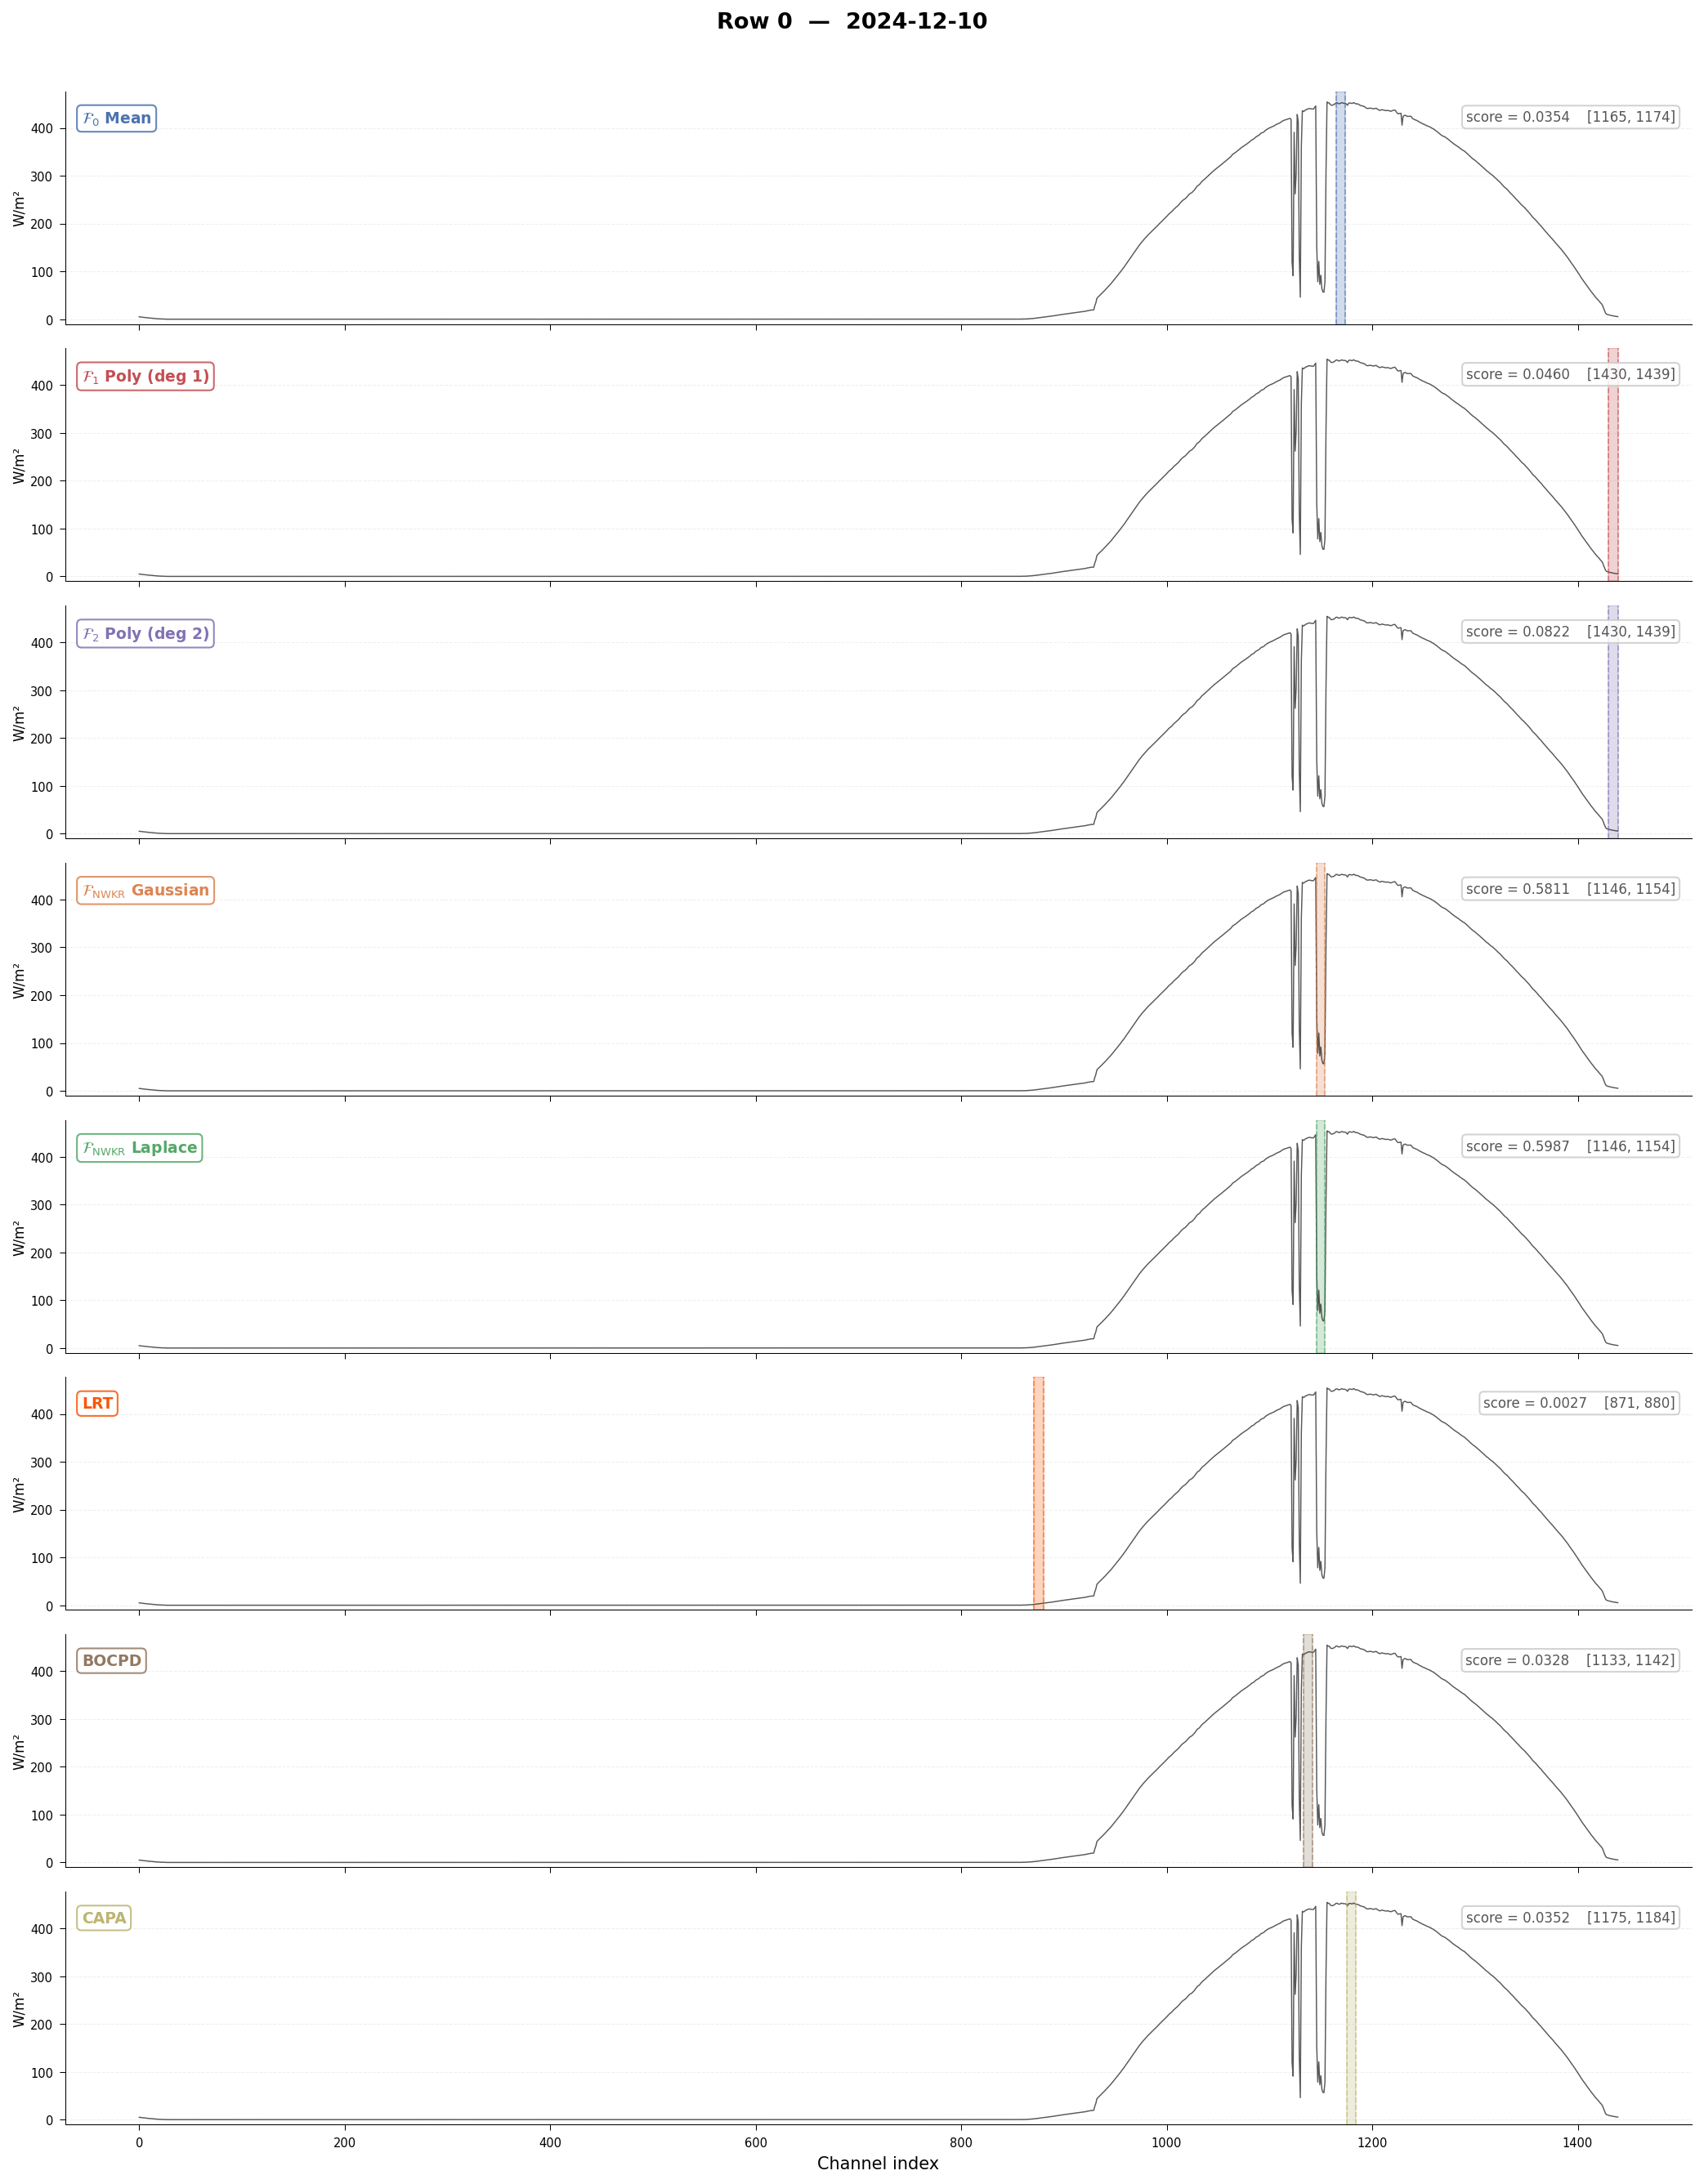

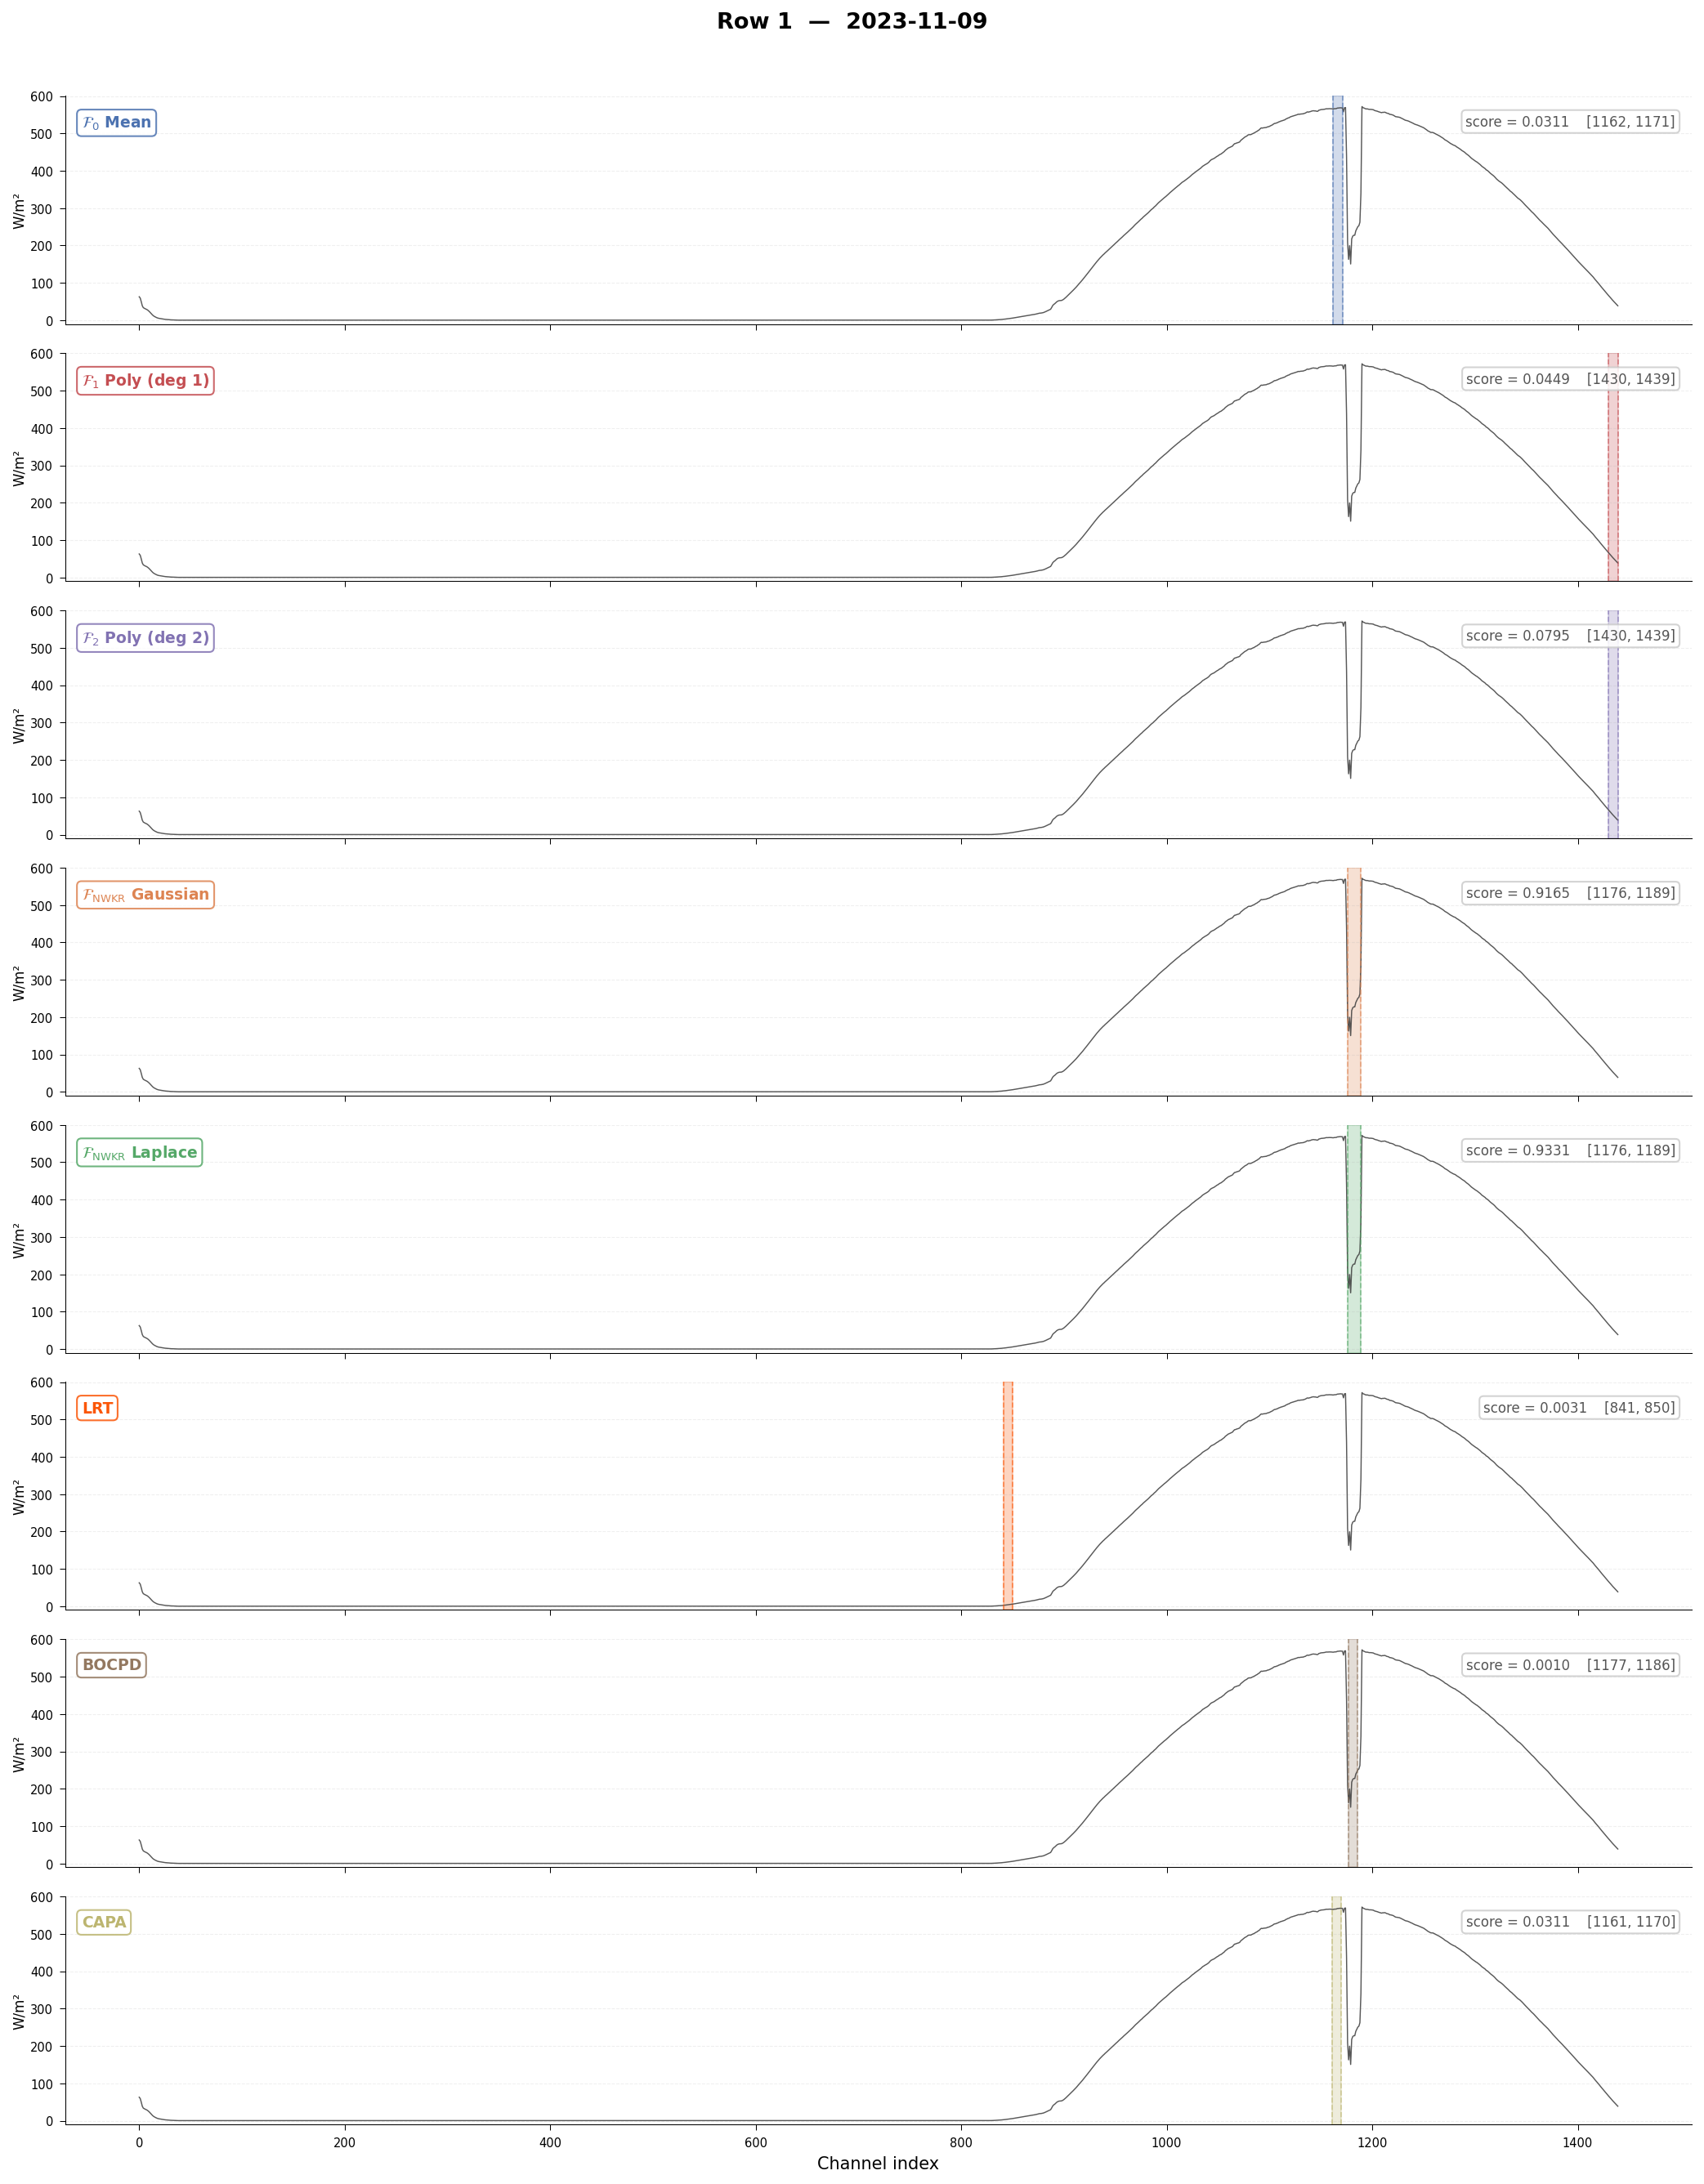

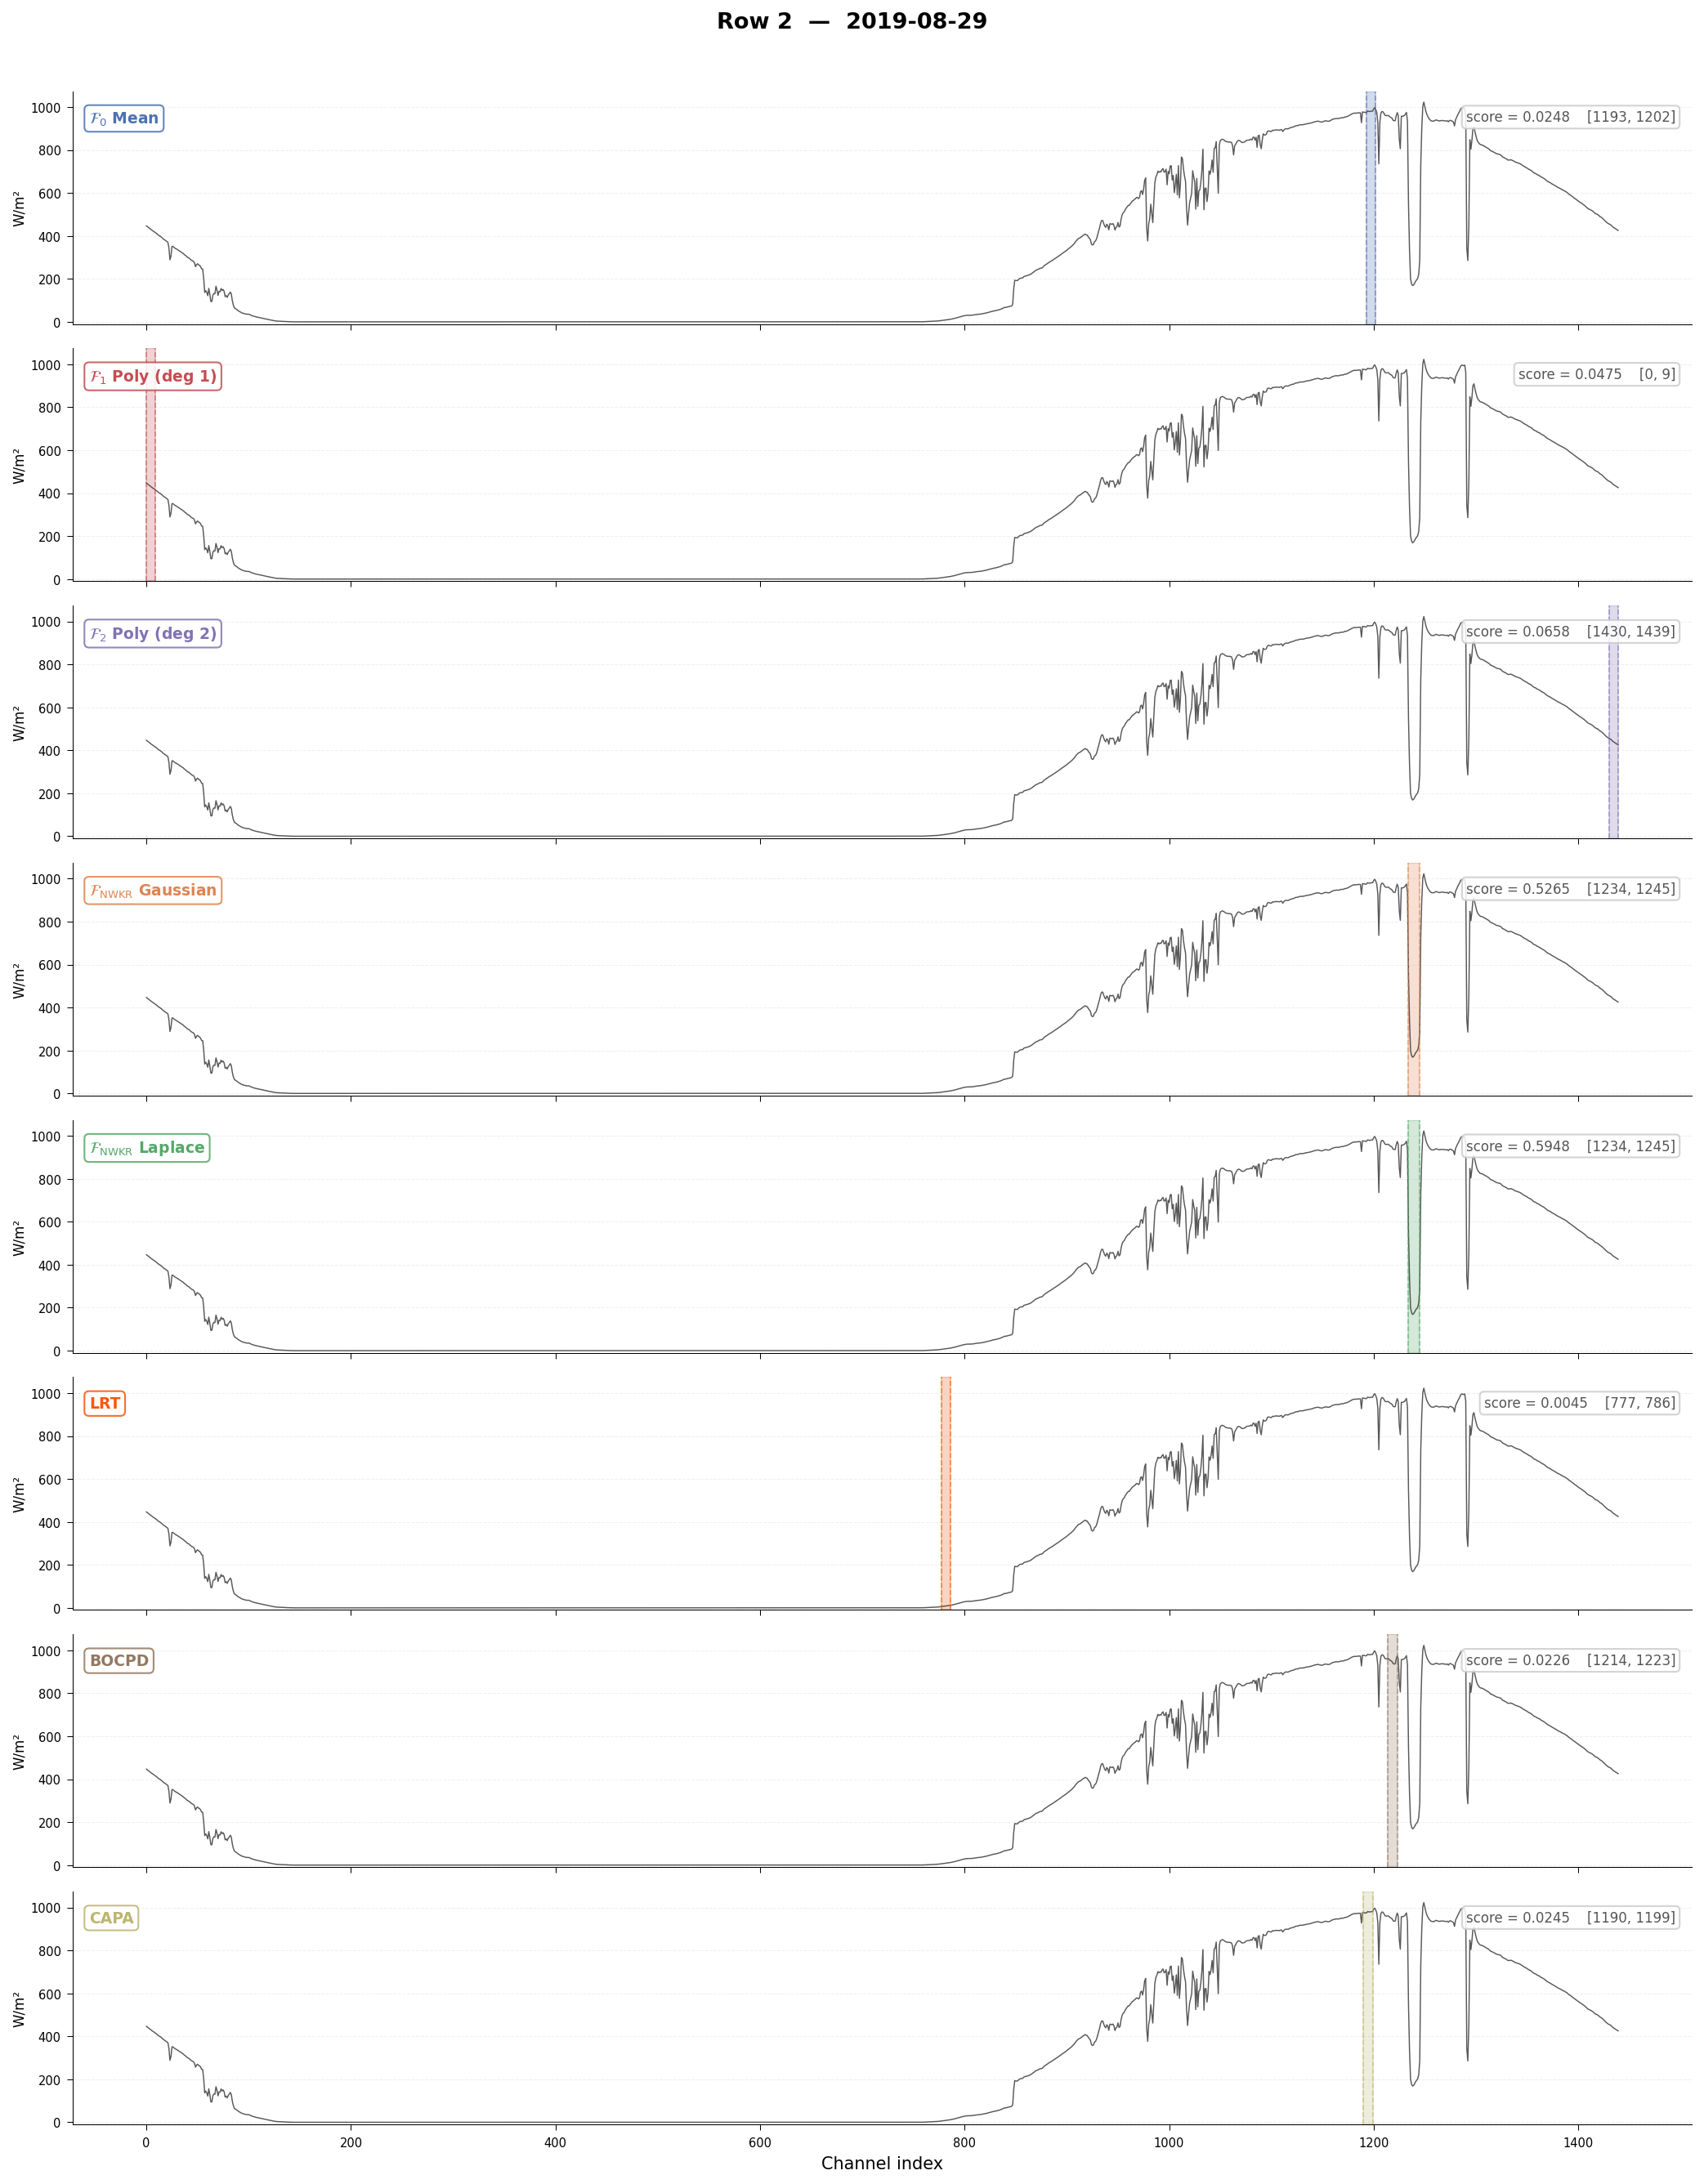

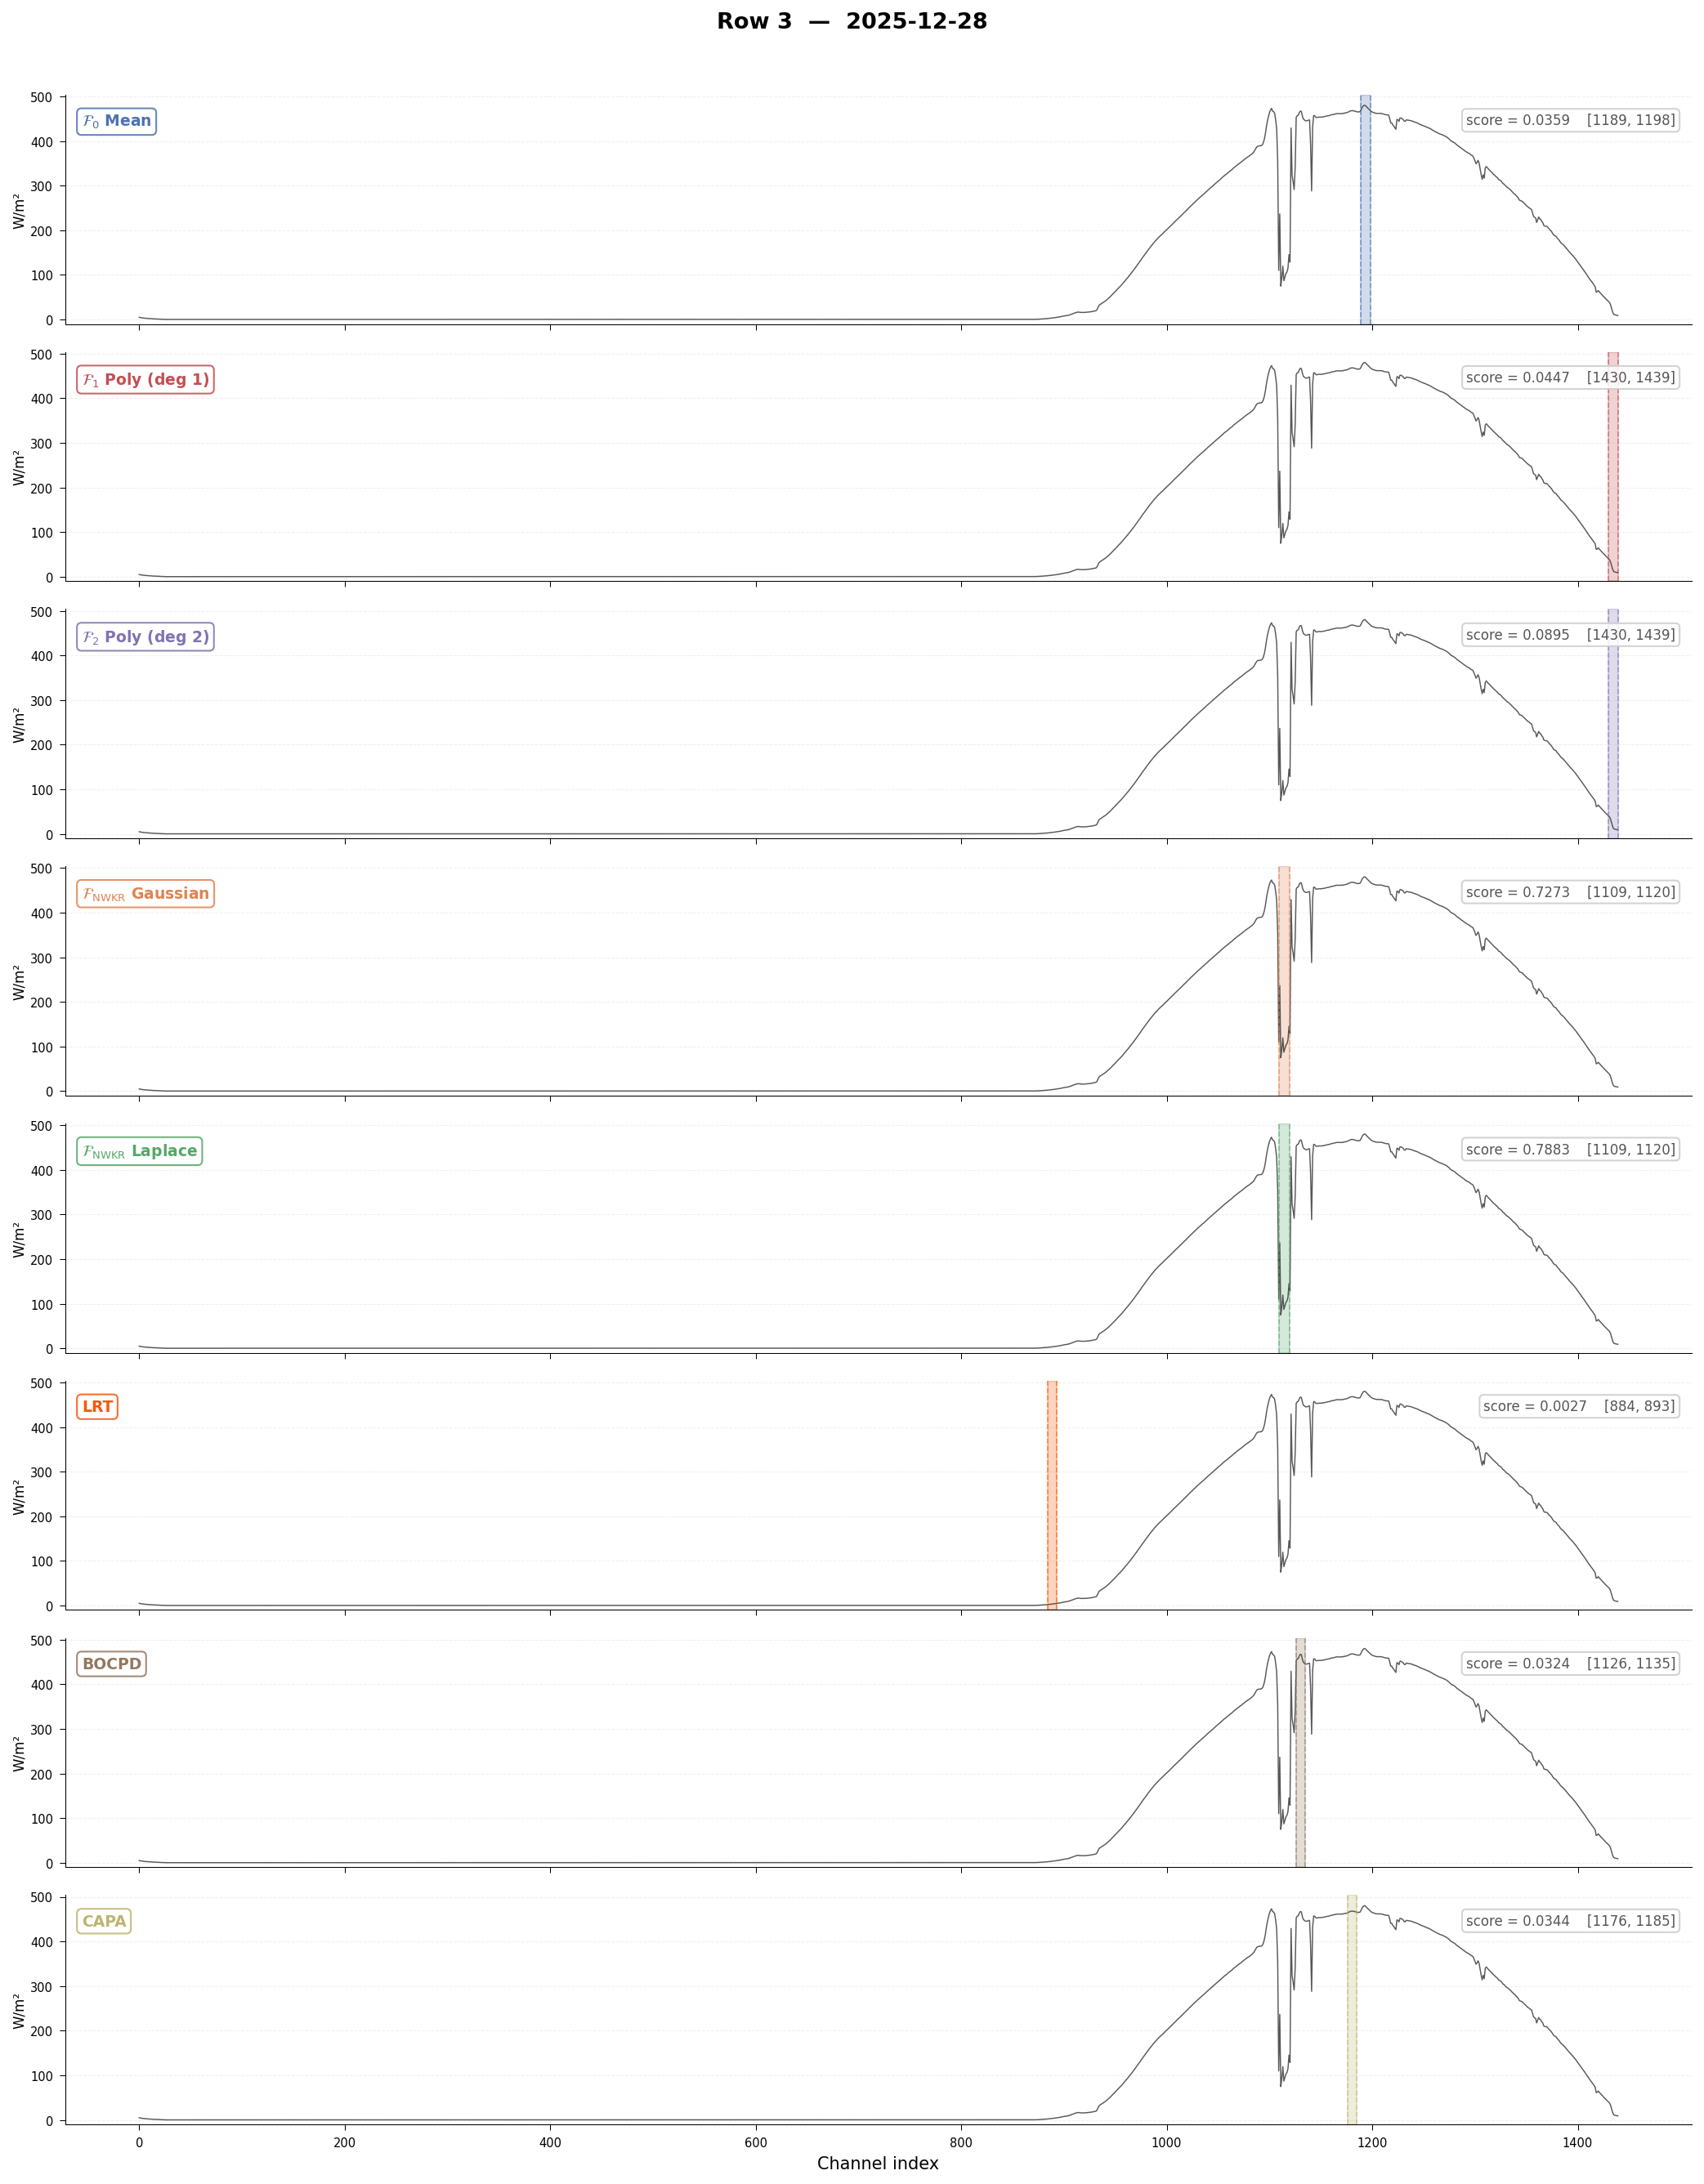

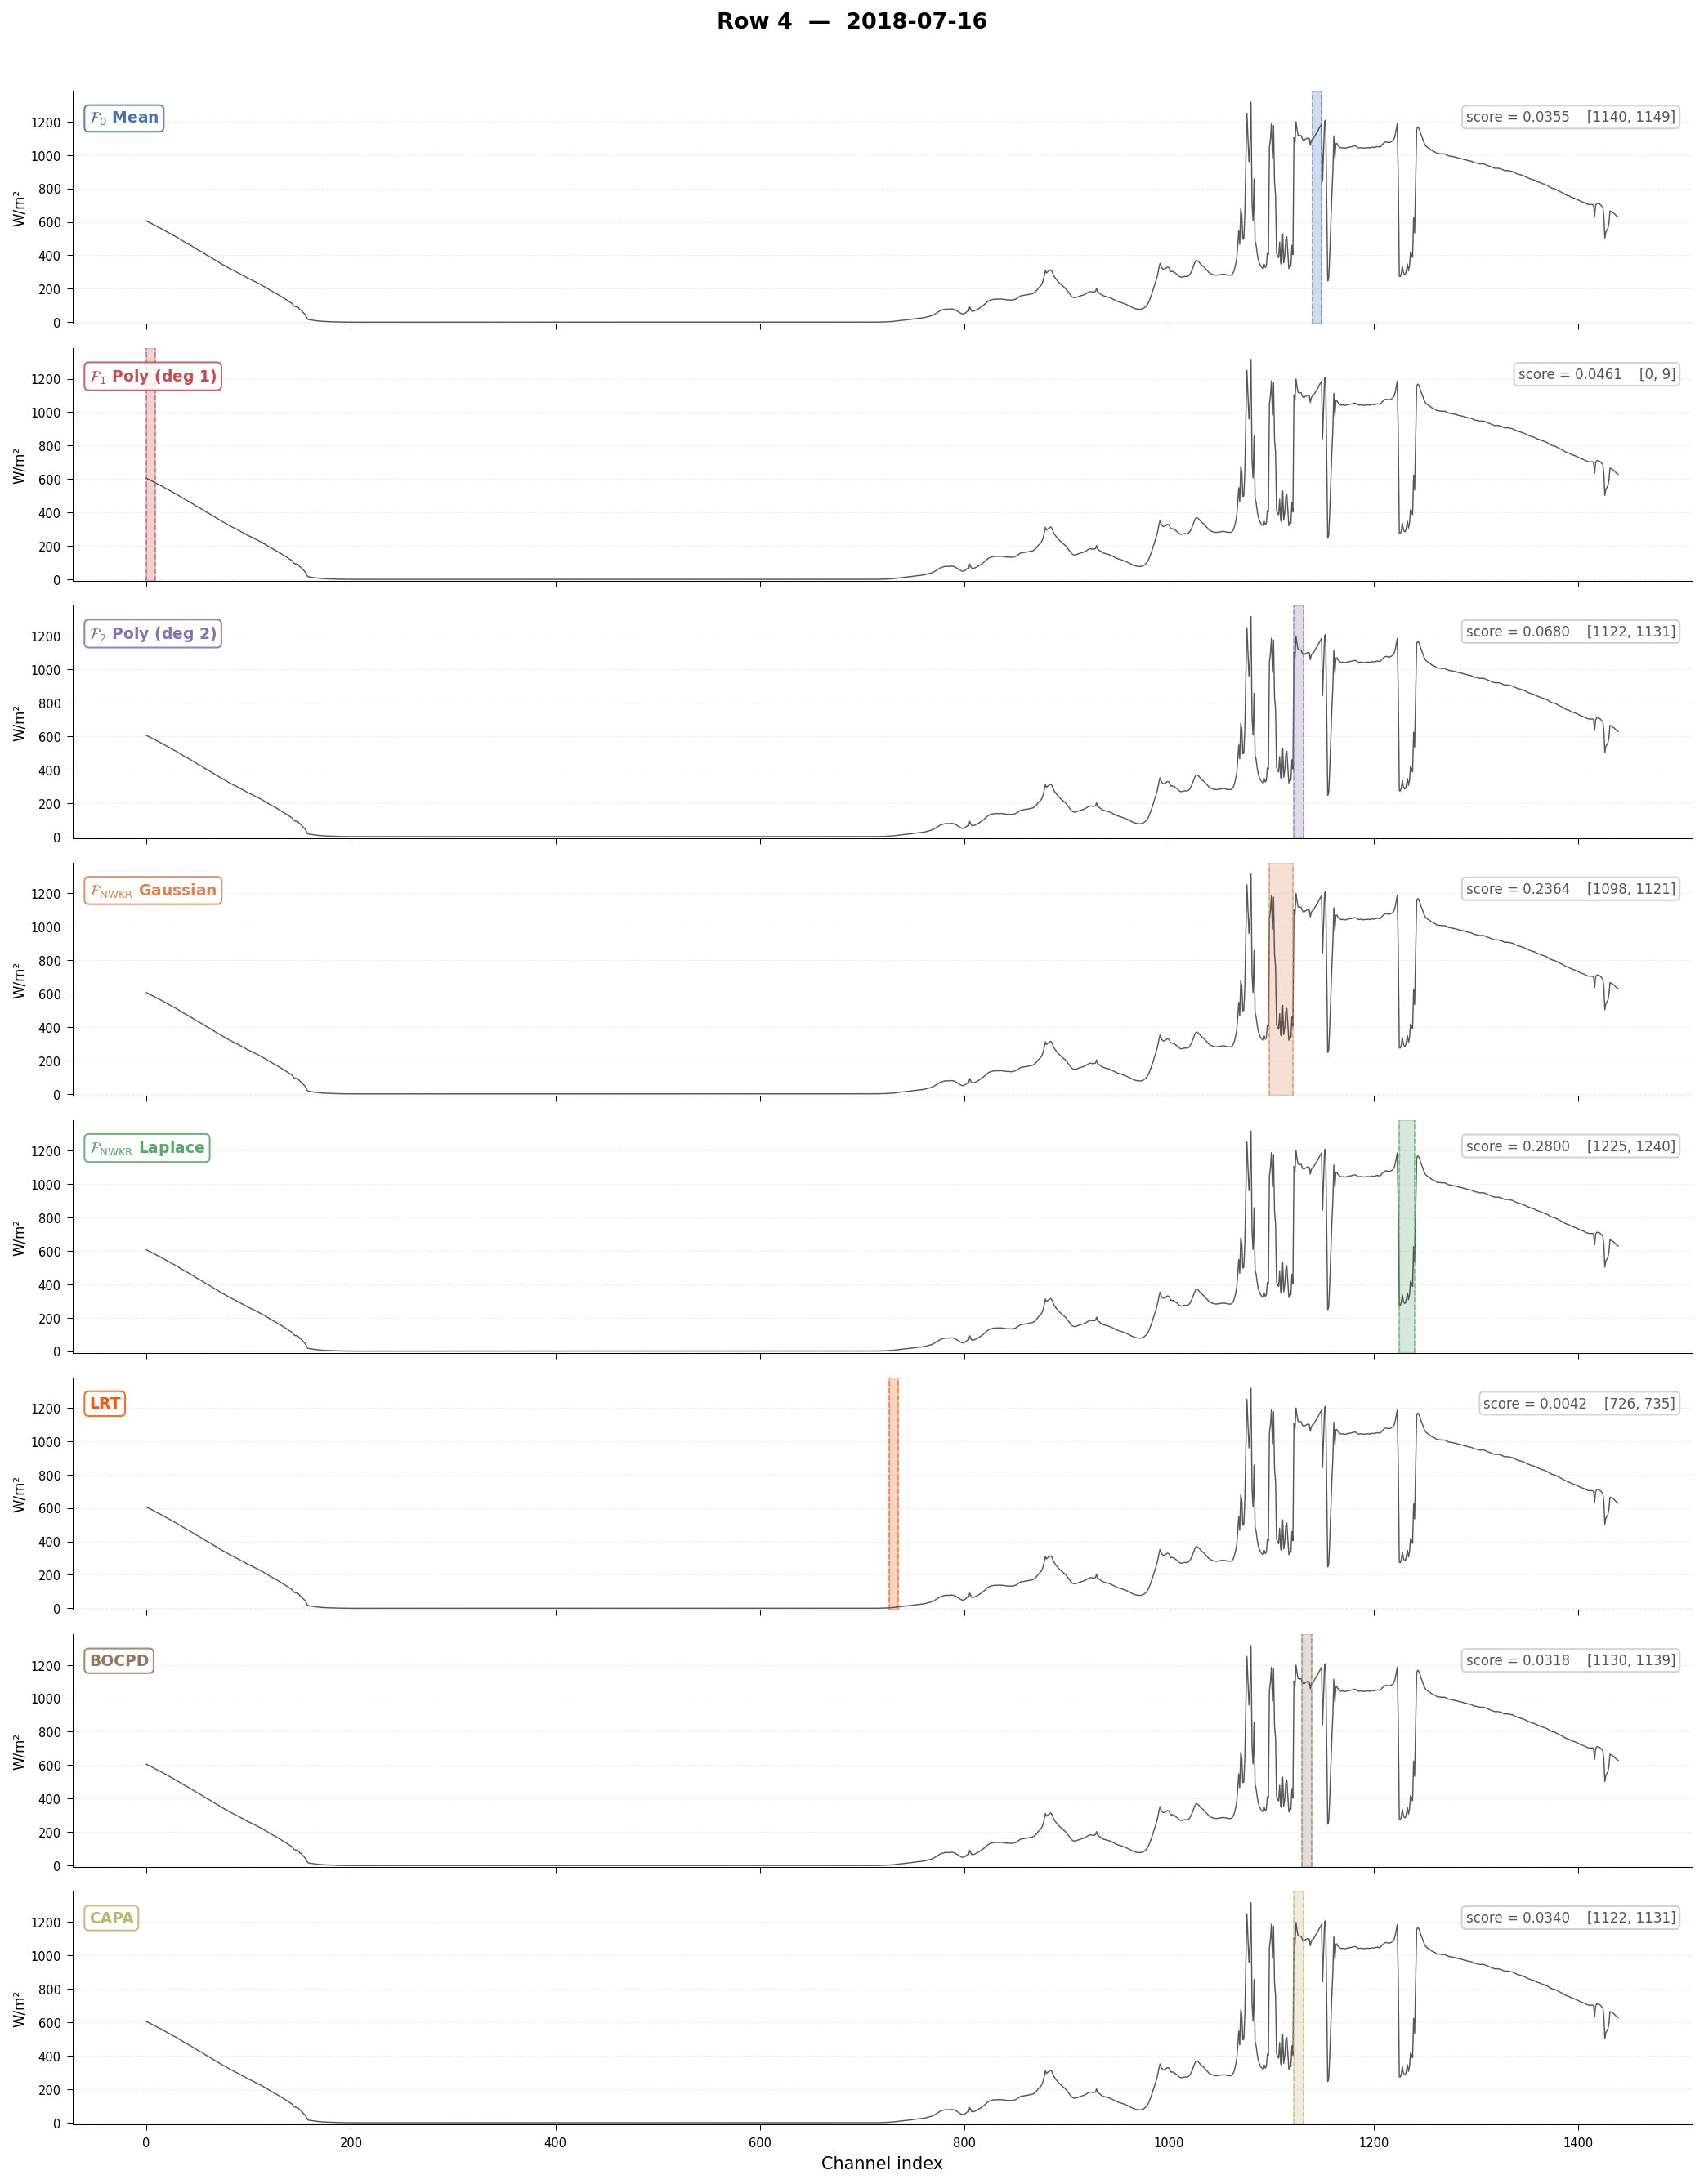

In [24]:
import matplotlib.pyplot as plt

METHOD_STYLE = {
    'mean':           {'label': '$\\mathcal{F}_0$ Mean',      'color': '#4C72B0'},
    'poly_deg1':      {'label': '$\\mathcal{F}_1$ Poly (deg 1)', 'color': '#C44E52'},
    'poly_deg2':      {'label': '$\\mathcal{F}_2$ Poly (deg 2)', 'color': '#8172B2'},
    'nwkr_gaussian':  {'label': '$\\mathcal{F}_{\\mathrm{NWKR}}$ Gaussian',              'color': '#DD8452'},
    'nwkr_laplace':   {'label': '$\\mathcal{F}_{\\mathrm{NWKR}}$ Laplace',               'color': '#55A868'},
    'lrt':            {'label': 'LRT',                         'color': '#FB5607'},
    'bocpd':          {'label': 'BOCPD',                       'color': '#937860'},
    'capa':           {'label': 'CAPA',                        'color': '#BCB570'},
}
 
for row_idx, group in results_df.groupby("row_idx"):
    orig = df_slices.iloc[row_idx]
    x = np.asarray(orig["solar"], dtype=np.float64)
    n = len(x)
    n_methods = len(group)
 
    fig, axes = plt.subplots(n_methods, 1, figsize=(14, 2.2 * n_methods),
                             sharex=True, dpi=150)
    if n_methods == 1:
        axes = [axes]
 
    fig.suptitle(f"Row {row_idx}  —  {orig['date']}", fontsize=13, fontweight='bold', y=1.01)
 
    for i, (_, res) in enumerate(group.iterrows()):
        ax = axes[i]
        method = res['method']
        style = METHOD_STYLE.get(method, {'label': method, 'color': '#4C72B0'})
 
        # Signal line
        ax.plot(x, lw=0.7, color='#3B3B3B', alpha=0.85, zorder=2)
 
        # Detected interval
        a, b = res["pred_a"], res["pred_b"]
        if 0 <= a < b < n:
            ax.axvspan(a, b, color=style['color'], alpha=0.25, zorder=1)
            # Mark boundaries with thin lines
            ax.axvline(a, color=style['color'], lw=0.8, alpha=0.6, linestyle='--', zorder=3)
            ax.axvline(b, color=style['color'], lw=0.8, alpha=0.6, linestyle='--', zorder=3)
 
        # Method label and score — top-left inside the axes
        ax.text(0.01, 0.92, f"{style['label']}",
                transform=ax.transAxes, fontsize=9, fontweight='bold',
                va='top', ha='left', color=style['color'],
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=style['color'], alpha=0.85))
 
        # Score and interval — top-right
        interval_str = f"[{a}, {b}]" if 0 <= a < b < n else "none"
        ax.text(0.99, 0.92, f"score = {res['score']:.4f}    {interval_str}",
                transform=ax.transAxes, fontsize=8,
                va='top', ha='right', color='#555555',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor='#CCCCCC', alpha=0.85))
 
        # Clean up
        ax.set_ylabel('W/m²', fontsize=8, labelpad=2)
        ax.set_ylim(bottom=-10)
        ax.spines[['top', 'right']].set_visible(False)
        ax.spines['left'].set_linewidth(0.5)
        ax.spines['bottom'].set_linewidth(0.5)
        ax.tick_params(axis='both', labelsize=7, width=0.5)
        ax.grid(axis='y', alpha=0.2, linestyle='--', linewidth=0.5)
 
    # X label only on the bottom
    axes[-1].set_xlabel('Channel index', fontsize=10)
 
    plt.tight_layout()
    plt.savefig(f"solar_row{row_idx}.png", dpi=200, bbox_inches="tight",
                facecolor='white', edgecolor='none')
    plt.show()
    plt.close(fig)